# 🌍 Dhaka Air Pollution — Clean Analytics Notebook

**End-to-end PySpark pipeline:** OpenAQ → quality control → weather & population enrichment → EDA → source signatures → health burden → health-impact ranking → PM2.5 forecasting.

### Design goals
- Uses the strongest data-engineering fixes from the **master** notebook.
- Keeps the clearer end-to-end organization from the **checked** notebook.
- **No HTML outputs and no interactive maps.**
- Every visualization is a **static PNG** made with Matplotlib/Seaborn and displayed directly in the notebook.
- Heavy Spark processing stays in Spark; Pandas is used only for compact visualization/summary data.
- Synthetic fallbacks, when unavoidable, are explicitly flagged.

> **Run from top to bottom.** The notebook creates `data/` and `outputs/` automatically.

> **Kaggle version:** before running, open the **🔑 Kaggle configuration** cell right below and set your OpenAQ API key and (optionally) the path to a WorldPop `.tif` population raster added to this notebook as a Kaggle Dataset.


## 0. 🔑 Kaggle configuration — edit this before running

Set your **OpenAQ API key** and the **WorldPop `.tif` population raster** path here. Everything downstream reads from these two variables, so this is the only cell you need to touch to point the notebook at your own credentials/data on Kaggle.

- **OpenAQ API key** — free key from https://explore.openaq.org/register. Paste it directly, or (recommended) add it as a **Kaggle Secret** named `OPENAQ_API_KEY` via *Add-ons → Secrets* and leave the placeholder below untouched — it will be picked up automatically.
- **WorldPop raster (.tif)** — add the file (e.g. `BGD_ppp_2020_adj_v2.tif`, from https://www.worldpop.org) to this notebook as a **Kaggle Dataset** (*Add data → Upload/search*), then either set `WORLDPOP_TIF_PATH` to its `/kaggle/input/...` path, or leave it as `None` and the notebook will auto-search `/kaggle/input` for any `.tif` file. If none is found, population enrichment falls back to a clearly-flagged synthetic area-lookup.


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 0.1 – Kaggle configuration: OpenAQ API key + WorldPop .tif raster path
# Edit the two variables below (OPENAQ_API_KEY, WORLDPOP_TIF_PATH) and re-run
# from here. Nothing else in the notebook needs to change.
# ─────────────────────────────────────────────────────────────────────────────
import os
from pathlib import Path

# ---- 1) OpenAQ API key ------------------------------------------------------
# Option A (simplest): paste your key directly below.
# Option B (recommended, keeps it out of the notebook): add it as a Kaggle
#   Secret (Add-ons → Secrets, name it OPENAQ_API_KEY). Leave the placeholder
#   below as-is and it will be picked up automatically.
OPENAQ_API_KEY = "115b43ac5567097478ed2f6bcf0b867229426df832772d499f589c45211ff213"

if OPENAQ_API_KEY in ("", "PASTE_YOUR_OPENAQ_API_KEY_HERE", None):
    OPENAQ_API_KEY = None
    try:
        from kaggle_secrets import UserSecretsClient
        OPENAQ_API_KEY = UserSecretsClient().get_secret("OPENAQ_API_KEY")
        print("✅ OpenAQ API key loaded from Kaggle Secrets.")
    except Exception:
        pass

if not OPENAQ_API_KEY:
    raise EnvironmentError(
        "❌ No OpenAQ API key found.\n"
        "   Either paste it into OPENAQ_API_KEY above, or add it as a Kaggle "
        "Secret named OPENAQ_API_KEY (Add-ons → Secrets)."
    )
print(f"✅ OpenAQ API key loaded: ...{OPENAQ_API_KEY[-8:]}")

# ---- 2) WorldPop population raster (.tif) -----------------------------------
# Point this at the raster's path once you've added it as a Kaggle Dataset,
# e.g. "/kaggle/input/population/BGD_ppp_2020_adj_v2.tif".
# Leave as None to auto-search /kaggle/input for any *.tif file.
WORLDPOP_TIF_PATH = "/kaggle/input/population/BGD_ppp_2020_adj_v2.tif"

def _resolve_worldpop_path(user_path):
    if user_path:
        p = Path(user_path)
        if p.exists():
            return p
        print(f"⚠️ WORLDPOP_TIF_PATH was set but not found: {p}")
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        candidates = sorted(kaggle_input.rglob("*.tif"))
        if candidates:
            print(f"🔎 Auto-detected raster in /kaggle/input: {candidates[0]}")
            return candidates[0]
    return None

WORLDPOP_TIF_PATH = _resolve_worldpop_path(WORLDPOP_TIF_PATH)
if WORLDPOP_TIF_PATH:
    print(f"✅ WorldPop raster path resolved: {WORLDPOP_TIF_PATH}")
else:
    print("⚠️ No WorldPop .tif found — population enrichment will fall back to the synthetic area-lookup.")

# ---- 3) Environment detection ------------------------------------------------
IS_KAGGLE = bool(os.environ.get("KAGGLE_KERNEL_RUN_TYPE") or os.environ.get("KAGGLE_URL_BASE"))
print(f"✅ Running on Kaggle: {IS_KAGGLE}")

✅ OpenAQ API key loaded: ...211ff213
⚠️ WORLDPOP_TIF_PATH was set but not found: /kaggle/input/population/BGD_ppp_2020_adj_v2.tif
🔎 Auto-detected raster in /kaggle/input: /kaggle/input/datasets/mahadirrahaman/population/BGD_ppp_2020_adj_v2.tif
✅ WorldPop raster path resolved: /kaggle/input/datasets/mahadirrahaman/population/BGD_ppp_2020_adj_v2.tif
✅ Running on Kaggle: True


## 1. Setup

This section installs only the packages needed by the clean notebook, loads configuration, and starts Spark with safer local/Kaggle settings.

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1.1 – Install dependencies
# FIX: skip packages already installed (pyspark re-resolve was the #1 cause of
#      the notebook looking "frozen" and getting Ctrl+C'd mid-install, which
#      corrupts the install and breaks Cell 1.4). Also fails loudly and clearly
#      instead of silently, and no longer runs fully silent (-q) for pyspark so
#      you can see it's actually working.
# UPDATE: added scikit-learn / lightgbm / xgboost for Section 8 — the GBT
#         comparison there now also benchmarks LightGBM and XGBoost as
#         drop-in gradient-boosting upgrades (trained via pandas/sklearn on
#         the single-station forecasting set, not Spark MLlib). Both are
#         optional: if either fails to install, Section 8 just skips that
#         candidate and reports so, rather than breaking the run.
# ─────────────────────────────────────────────────────────────────────────────
import subprocess, sys, importlib

PACKAGES = {
    "pyspark":  "pyspark==3.5.3",
    "requests": "requests",
    "dotenv":   "python-dotenv",
    "pandas":   "pandas",
    "numpy":    "numpy",
    "branca":   "branca",
    "scipy":    "scipy",
    "pyarrow":  "pyarrow",
    "matplotlib": "matplotlib",
    "seaborn":  "seaborn",
    "tqdm":     "tqdm",
    "sklearn":  "scikit-learn",
    "lightgbm": "lightgbm",
    "xgboost":  "xgboost",
    "rasterio": "rasterio",
}

OPTIONAL_PACKAGES = {"lightgbm", "xgboost"}

for import_name, pip_spec in PACKAGES.items():
    try:
        importlib.import_module(import_name)
        print(f"✅ {import_name} already installed — skipping.")
        continue
    except ImportError:
        pass

    quiet_flag = [] if import_name == "pyspark" else ["-q"]
    print(f"⏳ Installing {pip_spec} ... (pyspark is ~300MB — this can take a few minutes, do NOT interrupt)")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", *quiet_flag, pip_spec])
        print(f"✅ {pip_spec} installed.")
    except subprocess.CalledProcessError as e:
        if import_name in OPTIONAL_PACKAGES:
            print(f"⚠️ Failed to install {pip_spec}: {e}")
            print(f"   Section 8 will skip the {import_name} candidate — everything else still runs.")
        else:
            print(f"❌ Failed to install {pip_spec}: {e}")
            raise

print("✅ All packages installed successfully.")


✅ pyspark already installed — skipping.
✅ requests already installed — skipping.
✅ dotenv already installed — skipping.
✅ pandas already installed — skipping.
✅ numpy already installed — skipping.
✅ branca already installed — skipping.
✅ scipy already installed — skipping.
✅ pyarrow already installed — skipping.
✅ matplotlib already installed — skipping.
✅ seaborn already installed — skipping.
✅ tqdm already installed — skipping.
✅ sklearn already installed — skipping.
✅ lightgbm already installed — skipping.
✅ xgboost already installed — skipping.
✅ rasterio already installed — skipping.
✅ All packages installed successfully.


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1.2 – Standard library & third-party imports
# ─────────────────────────────────────────────────────────────────────────────
import os
import json
import time
import math
import warnings
import datetime
from pathlib import Path
from typing import List, Dict, Optional, Tuple

import requests
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
from dotenv import load_dotenv

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns



from scipy import stats

warnings.filterwarnings("ignore")

print("\u2705 Imports loaded.")

✅ Imports loaded.


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1.3 – Load environment variables & global configuration
# ─────────────────────────────────────────────────────────────────────────────

# ---- OpenAQ API key ----------------------------------------------------------
# Already loaded (and validated) in the Kaggle configuration cell at the top of
# the notebook — nothing to change here.
if not OPENAQ_API_KEY:
    raise EnvironmentError("❌ OPENAQ_API_KEY not found. Set it in the configuration cell above.")
print(f"✅ Using OpenAQ API key: ...{OPENAQ_API_KEY[-8:]}")

# ---- Directory layout --------------------------------------------------------
BASE_DIR   = Path("/kaggle/working") if IS_KAGGLE else Path(".")
DATA_DIR   = BASE_DIR / "data"
RAW_DIR    = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = BASE_DIR / "outputs"

for d in [RAW_DIR, INTERIM_DIR, PROCESSED_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"\u2705 Directory layout created under: {BASE_DIR.resolve()}")

# ---- Pollutant constants -----------------------------------------------------
POLLUTANTS   = ["pm25", "pm10", "no2", "o3", "so2", "co"]
PARAMETER_MAP = {
    "pm25": "PM2.5",
    "pm10": "PM10",
    "no2" : "NO₂",
    "o3"  : "O₃",
    "so2" : "SO₂",
    "co"  : "CO",
}

# ---- WHO daily guideline values (µg/m³ or ppm) --------------------------------
WHO_GUIDELINES = {
    "pm25": 15,    # µg/m³  (24-h mean, WHO 2021)
    "pm10": 45,    # µg/m³
    "no2" : 25,    # µg/m³
    "o3"  : 100,   # µg/m³  (peak season)
    "so2" : 40,    # µg/m³
    "co"  : 4,     # mg/m³  (24-h)
}

# ---- Dhaka bounding box & centre --------------------------------------------
DHAKA_LAT  = 23.8103
DHAKA_LON  = 90.4125
DHAKA_BBOX = {
    "lat_min": 23.60, "lat_max": 24.00,
    "lon_min": 90.25, "lon_max": 90.60,
}

# ---- Date range for data pull ------------------------------------------------
END_DATE   = datetime.date.today()
START_DATE = END_DATE - datetime.timedelta(days=365)
print(f"\u2705 Analysis period: {START_DATE} → {END_DATE}")

# ---- Colour palette (used throughout) -----------------------------------------
POLLUTANT_COLORS = {
    "pm25": "#E74C3C",
    "pm10": "#E67E22",
    "no2" : "#9B59B6",
    "o3"  : "#27AE60",
    "so2" : "#F39C12",
    "co"  : "#2980B9",
}
SEASON_COLORS = {
    "Winter" : "#3498DB",
    "Pre-Monsoon": "#E67E22",
    "Monsoon": "#27AE60",
    "Post-Monsoon": "#9B59B6",
}

print("\u2705 Global configuration complete.")

✅ Using OpenAQ API key: ...211ff213
✅ Directory layout created under: /kaggle/working
✅ Analysis period: 2025-09-12 → 2026-09-12
✅ Global configuration complete.


In [9]:
# CELL 1.4 – PySpark session initialisation

import os
import sys
import glob
import shutil
import subprocess
import platform
import pyspark
from pyspark.sql import SparkSession, Window
import pyspark.sql.functions as F
import pyspark.sql.types as T

# Detect notebook environment
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

IS_LINUX = platform.system() == "Linux"
IS_WINDOWS = platform.system() == "Windows"

# Keep driver and workers on the same Python interpreter
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable


def find_java_home():
    """Find a real Java installation instead of trusting a stale JAVA_HOME."""
    candidates = []

    old_home = os.environ.get("JAVA_HOME", "")
    if old_home:
        candidates.append(old_home)

    candidates += [
        "/usr/lib/jvm/java-17-openjdk-amd64",
        "/usr/lib/jvm/java-17-openjdk",
        "",
        "/usr/lib/jvm/java-11-openjdk",
        "/usr/lib/jvm/default-java",
    ]

    candidates += glob.glob("/usr/lib/jvm/*")

    # Windows
    if IS_WINDOWS:
        candidates += glob.glob(r"C:\Program Files\Eclipse Adoptium\jdk-*")
        candidates += glob.glob(r"C:\Program Files\Java\jdk-*")

    for home in candidates:
        java_file = os.path.join(home, "bin", "java.exe" if IS_WINDOWS else "java")
        if os.path.isfile(java_file):
            return os.path.abspath(home)

    java_on_path = shutil.which("java")
    if java_on_path:
        java_real = os.path.realpath(java_on_path)
        return os.path.dirname(os.path.dirname(java_real))

    return None


# IMPORTANT:
# The previous notebook forced this invalid path:
#
# We now verify the path before using it.
JAVA_HOME = find_java_home()

# If Java is missing, install OpenJDK 17 on Linux/Colab/Kaggle.
if JAVA_HOME is None and IS_LINUX:
    print("⚠️ Java was not found. Installing OpenJDK 17...")
    try:
        subprocess.run(
            ["apt-get", "update", "-qq"],
            check=True,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL
        )
        subprocess.run(
            ["apt-get", "install", "-y", "-qq", "openjdk-17-jdk-headless"],
            check=True,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL
        )
    except Exception as e:
        raise RuntimeError(
            "Java could not be installed automatically. "
            "Please install OpenJDK 17 and restart the notebook."
        ) from e

    JAVA_HOME = find_java_home()

if JAVA_HOME is None:
    raise RuntimeError(
        "Java was not found. PySpark needs a working Java installation. "
        "Install OpenJDK 17 and restart the kernel."
    )

os.environ["JAVA_HOME"] = JAVA_HOME
java_bin = os.path.join(JAVA_HOME, "bin")
os.environ["PATH"] = java_bin + os.pathsep + os.environ.get("PATH", "")

# Verify Java before Spark starts
java_exe = os.path.join(java_bin, "java.exe" if IS_WINDOWS else "java")

if not os.path.isfile(java_exe):
    raise RuntimeError(
        f"JAVA_HOME points to a missing Java executable:\n{java_exe}"
    )

java_check = subprocess.run(
    [java_exe, "-version"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    text=True
)

if java_check.returncode != 0:
    raise RuntimeError(
        "Java was found but could not run.\n"
        + java_check.stderr
    )

print("✅ Java found")
print(f"   JAVA_HOME: {JAVA_HOME}")
print("   " + java_check.stderr.splitlines()[0])

# Stop any previous Spark session
try:
    spark.stop()
except (NameError, Exception):
    pass

# Start Spark
try:
    spark = (
        SparkSession.builder
        .master("local[*]")
        .appName("DhakaAirPollutionClean")
        .config("spark.driver.memory", "4g")
        .config("spark.executor.memory", "4g")
        .config("spark.sql.shuffle.partitions", "8")
        .config("spark.sql.adaptive.enabled", "true")
        .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
        .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
        .config("spark.ui.showConsoleProgress", "false")
        .config("spark.sql.execution.arrow.pyspark.enabled", "false")
        .getOrCreate()
    )
except Exception as e:
    raise RuntimeError(
        "❌ SparkSession could not start.\n\n"
        f"Java executable: {java_exe}\n"
        f"JAVA_HOME: {JAVA_HOME}\n"
        f"PySpark version: {pyspark.__version__}\n\n"
        "If this is Colab/Kaggle, restart the runtime once and run the "
        "notebook from Cell 1.1 again.\n\n"
        f"Original error: {e}"
    ) from e

spark.sparkContext.setLogLevel("ERROR")

print("✅ SparkSession started")
print(f"   PySpark version : {spark.version}")
print(f"   Master          : {spark.sparkContext.master}")
print(f"   App name        : {spark.sparkContext.appName}")
print(f"   Arrow enabled   : {spark.conf.get('spark.sql.execution.arrow.pyspark.enabled')}")


✅ Java found
   JAVA_HOME: /usr/lib/jvm/java-17-openjdk-amd64
   openjdk version "17.0.18" 2026-01-20


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/12 10:40:35 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


✅ SparkSession started
   PySpark version : 4.0.2
   Master          : local[*]
   App name        : DhakaAirPollutionClean
   Arrow enabled   : false


## 2. Data ingestion & quality control

The ingestion section uses the master notebook's safer OpenAQ pagination/cache logic, then standardizes units, flags outliers, imputes short gaps, pivots to a station-hour table, and produces a QC report.

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2.1 – Discover all active Dhaka-area stations via OpenAQ v3 API
# FIX: OpenAQ v3 caps the `radius` parameter at 25,000 m (25km) — a value of
#      30000 is rejected outright with "422 Unprocessable Entity". Clamped to
#      the API maximum below. Also: openaq_get() now surfaces the API's own
#      error detail (it returns a structured `errors` array explaining exactly
#      which parameter was invalid) instead of just re-raising the generic
#      HTTPError, so any future 422 is self-diagnosing.
# ─────────────────────────────────────────────────────────────────────────────

OPENAQ_BASE    = "https://api.openaq.org/v3"
OPENAQ_HEADERS = {"Accept": "application/json"}
if OPENAQ_API_KEY:
    OPENAQ_HEADERS["X-API-Key"] = OPENAQ_API_KEY
OPENAQ_MAX_RADIUS_M = 25_000  # hard API limit — do not raise this


def openaq_get(endpoint: str, params: dict = None, retries: int = 5) -> dict:
    """Rate-limited GET with exponential backoff."""
    url = f"{OPENAQ_BASE}{endpoint}"
    for attempt in range(retries):
        try:
            r = requests.get(url, headers=OPENAQ_HEADERS, params=params, timeout=30)
            if r.status_code == 429:          # rate limit
                wait = 2 ** attempt
                print(f"   Rate limited — waiting {wait}s")
                time.sleep(wait)
                continue
            if r.status_code == 422:
                # Surface OpenAQ's actual validation error instead of a bare HTTPError
                try:
                    detail = r.json().get("errors", r.text)
                except ValueError:
                    detail = r.text
                print(f"❌ 422 Unprocessable Entity on {endpoint} — params: {params}")
                print(f"   API detail: {detail}")
            r.raise_for_status()
            return r.json()
        except requests.RequestException as e:
            if attempt == retries - 1:
                raise
            time.sleep(2 ** attempt)
    return {}


def discover_dhaka_stations() -> pd.DataFrame:
    """
    Query OpenAQ v3 /locations endpoint with Dhaka bounding box
    and return a clean DataFrame of active stations.
    """
    all_stations = []
    page = 1
    while True:
        params = {
            "coordinates"  : f"{DHAKA_LAT},{DHAKA_LON}",
            "radius"       : OPENAQ_MAX_RADIUS_M,   # 25 km — API maximum
            "limit"        : 100,
            "page"         : page,
        }
        data = openaq_get("/locations", params=params)
        results = data.get("results", [])
        if not results:
            break
        all_stations.extend(results)
        meta = data.get("meta", {})
        total = meta.get("found", 0)
        if len(all_stations) >= total:
            break
        page += 1
        time.sleep(0.5)

    rows = []
    for loc in all_stations:
        coord = loc.get("coordinates") or {}
        rows.append({
            "location_id"  : loc.get("id"),
            "name"         : loc.get("name", ""),
            "city"         : loc.get("locality", "") or loc.get("city", ""),
            "country"      : loc.get("country", {}).get("code", "") if isinstance(loc.get("country"), dict) else loc.get("country", ""),
            "latitude"     : coord.get("latitude"),
            "longitude"    : coord.get("longitude"),
            "is_mobile"    : loc.get("isMobile", False),
            "is_monitor"   : loc.get("isMonitor", True),
            "sensors"      : ", ".join([
                s.get("parameter", {}).get("name", "") if isinstance(s.get("parameter"), dict)
                else str(s.get("parameter", ""))
                for s in loc.get("sensors", [])
            ]),
            "first_updated": loc.get("datetimeFirst", {}).get("utc", "") if isinstance(loc.get("datetimeFirst"), dict) else "",
            "last_updated" : loc.get("datetimeLast",  {}).get("utc", "") if isinstance(loc.get("datetimeLast"),  dict) else "",
        })

    df = pd.DataFrame(rows)
    df = df[df["country"] == "BD"].reset_index(drop=True)
    return df


print("🔍 Discovering Dhaka monitoring stations...")
if not OPENAQ_API_KEY:
    print("⚠️ No OpenAQ API key available. Discovery may fail unless the API accepts the current request.")
try:
    stations_df = discover_dhaka_stations()
except Exception as e:
    print(f"⚠️ Station discovery failed: {e}")
    stations_df = pd.DataFrame()

if stations_df.empty:
    # Fallback: known Dhaka station IDs as of 2024
    FALLBACK_STATION_IDS = [3069, 3070, 3071, 3072, 64655, 64656]
    rows = []
    for sid in FALLBACK_STATION_IDS:
        data = openaq_get(f"/locations/{sid}")
        r = (data.get("results") or [{}])[0]
        coord = r.get("coordinates") or {}
        rows.append({
            "location_id": sid,
            "name"        : r.get("name", f"Station_{sid}"),
            "city"        : "Dhaka",
            "country"     : "BD",
            "latitude"    : coord.get("latitude", DHAKA_LAT),
            "longitude"   : coord.get("longitude", DHAKA_LON),
            "is_mobile"   : False,
            "is_monitor"  : True,
            "sensors"     : "",
            "first_updated": "",
            "last_updated" : "",
        })
    stations_df = pd.DataFrame(rows)

print(f"✅ Found {len(stations_df)} Dhaka stations")
print(stations_df[["location_id", "name", "latitude", "longitude"]].to_string(index=False))

# Persist station metadata
stations_df.to_csv(RAW_DIR / "dhaka_stations.csv", index=False)
print(f"✅ Station metadata saved to: {RAW_DIR / 'dhaka_stations.csv'}")


🔍 Discovering Dhaka monitoring stations...
✅ Found 22 Dhaka stations
 location_id                                                                  name  latitude  longitude
          22                                            SPARTAN - Dhaka University 23.728000  90.398000
        2445                                             US Diplomatic Post: Dhaka 23.797687  90.423698
        8415                                                                 Dhaka 23.796374  90.424614
     1285342                                            SPARTAN - Dhaka University 23.728400  90.398200
     3194367      Dept. of Public Health and Informatics, Jahangirnagar University 23.888281  90.265370
     5105944                                           smart air bangladesh office 23.780811  90.424648
     6157905                   RAJUK Uttara Apartment Project, Sector - 18, Uttara 23.856237  90.356837
     6219691                                              Abdullahbag, North Badda 23.789350  90.43

### OpenAQ v3 measurement retrieval

This version uses the OpenAQ v3 sensor architecture: **location → sensors → sensor measurements/hours**. It does **not** call the deprecated/invalid `locationsId` parameter on `/v3/measurements`.

If a station has no PM2.5 sensor, it is skipped rather than generating fake measurements.

In [11]:
# CELL 2.2 – Fetch hourly measurements from OpenAQ v3 for all stations


def fetch_measurements_for_station(
    location_id: int,
    date_from: datetime.date,
    date_to: datetime.date,
    pollutants: List[str],
    batch_days: int = 30,
) -> List[dict]:
    """
    Fetch measurements for `location_id` using OpenAQ v3 sensor architecture.
    In OpenAQ v3, locations host sensor IDs, and measurements are queried per sensor:
      1. GET /locations/{location_id}/sensors
      2. GET /sensors/{sensor_id}/measurements (or /sensors/{sensor_id}/hours)
    """
    records = []

    # 1. Discover sensors available at this station
    sensor_data = openaq_get(f"/locations/{location_id}/sensors")
    sensors = sensor_data.get("results", []) if sensor_data else []

    target_sensors = []
    for s in sensors:
        param = s.get("parameter", {})
        param_name = param.get("name", "") if isinstance(param, dict) else str(param)
        param_name = param_name.lower().replace(".", "").strip()
        if param_name in pollutants:
            target_sensors.append((s.get("id"), param_name))

    if not target_sensors:
        return records

    # 2. Fetch measurements per sensor ID
    for sensor_id, param_name in target_sensors:
        if not sensor_id:
            continue
        current = date_from
        while current < date_to:
            batch_end = min(current + datetime.timedelta(days=batch_days), date_to)
            page = 1
            while True:
                params = {
                    "datetime_from": current.isoformat() + "T00:00:00Z",
                    "datetime_to"  : batch_end.isoformat() + "T23:59:59Z",
                    "limit"        : 1000,
                    "page"         : page,
                }

                # Try sensor measurements endpoint, fallback to sensor hours
                data = openaq_get(f"/sensors/{sensor_id}/measurements", params=params)
                if not data or not data.get("results"):
                    data = openaq_get(f"/sensors/{sensor_id}/hours", params=params)

                results = data.get("results", []) if data else []
                if not results:
                    break

                for m in results:
                    dt_info = m.get("period", {}).get("datetimeFrom") or m.get("datetime") or {}
                    utc_str = dt_info.get("utc", "") if isinstance(dt_info, dict) else str(dt_info)
                    coord = m.get("coordinates") or {}
                    records.append({
                        "location_id" : location_id,
                        "datetime_utc": utc_str,
                        "pollutant"   : param_name,
                        "value"       : m.get("value"),
                        "unit"        : m.get("unit", "µg/m³"),
                        "lat"         : coord.get("latitude") if isinstance(coord, dict) else None,
                        "lon"         : coord.get("longitude") if isinstance(coord, dict) else None,
                    })

                meta = data.get("meta", {})
                found = meta.get("found", 0)
                if not found or page * 1000 >= found:
                    break
                page += 1
                time.sleep(0.2)

            current = batch_end
            time.sleep(0.2)

    return records


# Main fetch loop
RAW_JSON_PATH = RAW_DIR / "measurements_raw.json"

if RAW_JSON_PATH.exists():
    print(f"⚠️ Raw data already exists at {RAW_JSON_PATH}. Loading from cache.")
    print("   Delete the file to force a fresh API pull.")
    with open(RAW_JSON_PATH, "r", encoding="utf-8") as f:
        all_records = json.load(f)
else:
    all_records = []
    station_ids = stations_df["location_id"].dropna().unique().tolist()
    print(f"📡 Fetching measurements for {len(station_ids)} stations from {START_DATE} to {END_DATE}...")

    for sid in tqdm(station_ids, desc="Stations"):
        records = fetch_measurements_for_station(
            location_id=int(sid),
            date_from=START_DATE,
            date_to=END_DATE,
            pollutants=POLLUTANTS,
        )
        all_records.extend(records)
        time.sleep(0.3)

    # Synthetic baseline generator if historical API tier returns no records
    if not all_records:
        print("⚠️ No live historical measurements returned by API tier. Generating calibrated Dhaka baseline...")
        rng = np.random.default_rng(42)
        date_range = pd.date_range(START_DATE, END_DATE, freq="2h", tz="UTC")
        months = date_range.month.values
        hours = date_range.hour.values

        for _, st in stations_df.iterrows():
            sid = int(st["location_id"])
            s_lat = float(st["latitude"]) if pd.notnull(st["latitude"]) else DHAKA_LAT
            s_lon = float(st["longitude"]) if pd.notnull(st["longitude"]) else DHAKA_LON

            # Calibrated Dhaka seasonal baselines (µg/m³)
            pm25_base = np.where(np.isin(months, [12, 1, 2]), 165.0,
                        np.where(np.isin(months, [3, 4, 5]), 85.0,
                        np.where(np.isin(months, [6, 7, 8, 9]), 35.0, 95.0)))
            diurnal_pm25 = 22.0 * np.sin((hours - 7) / 24.0 * 2 * np.pi)
            pm25_vals = np.clip(pm25_base + diurnal_pm25 + rng.normal(0, 14, len(date_range)), 8, 450)
            pm10_vals = np.clip(pm25_vals * rng.uniform(1.45, 1.85, len(date_range)), 15, 650)
            no2_vals  = np.clip(35.0 + 15.0 * np.sin((hours - 8) / 24.0 * 2 * np.pi) + rng.normal(0, 6, len(date_range)), 5, 180)

            for dt, p25, p10, n2 in zip(date_range, pm25_vals, pm10_vals, no2_vals):
                ts_str = dt.strftime("%Y-%m-%dT%H:%M:%SZ")
                all_records.append({"location_id": sid, "datetime_utc": ts_str, "pollutant": "pm25", "value": float(round(p25, 2)), "unit": "µg/m³", "lat": s_lat, "lon": s_lon})
                all_records.append({"location_id": sid, "datetime_utc": ts_str, "pollutant": "pm10", "value": float(round(p10, 2)), "unit": "µg/m³", "lat": s_lat, "lon": s_lon})
                all_records.append({"location_id": sid, "datetime_utc": ts_str, "pollutant": "no2",  "value": float(round(n2, 2)),  "unit": "µg/m³", "lat": s_lat, "lon": s_lon})

    # Save raw JSON cache
    with open(RAW_JSON_PATH, "w", encoding="utf-8") as f:
        json.dump(all_records, f)

print(f"Total raw measurement records: {len(all_records):,}")

📡 Fetching measurements for 22 stations from 2025-09-12 to 2026-09-12...


Stations:   0%|          | 0/22 [00:00<?, ?it/s]

   Rate limited — waiting 1s
   Rate limited — waiting 2s
   Rate limited — waiting 1s
   Rate limited — waiting 2s
   Rate limited — waiting 4s
   Rate limited — waiting 8s
   Rate limited — waiting 16s
   Rate limited — waiting 1s
   Rate limited — waiting 2s
   Rate limited — waiting 4s
   Rate limited — waiting 8s
   Rate limited — waiting 1s
   Rate limited — waiting 2s
   Rate limited — waiting 4s
   Rate limited — waiting 8s
   Rate limited — waiting 16s
   Rate limited — waiting 1s
   Rate limited — waiting 2s
   Rate limited — waiting 4s
   Rate limited — waiting 1s
   Rate limited — waiting 2s
   Rate limited — waiting 4s
   Rate limited — waiting 8s
   Rate limited — waiting 16s
   Rate limited — waiting 1s
   Rate limited — waiting 2s
   Rate limited — waiting 1s
   Rate limited — waiting 2s
   Rate limited — waiting 4s
   Rate limited — waiting 8s
   Rate limited — waiting 16s
   Rate limited — waiting 1s
   Rate limited — waiting 2s
   Rate limited — waiting 1s
   Rate li

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2.3 – Load raw JSON into PySpark DataFrame & define schema
# ─────────────────────────────────────────────────────────────────────────────

RAW_SCHEMA = T.StructType([
    T.StructField("location_id",  T.LongType(),   True),
    T.StructField("datetime_utc", T.StringType(),  True),
    T.StructField("pollutant",    T.StringType(),  True),
    T.StructField("value",        T.DoubleType(),  True),
    T.StructField("unit",         T.StringType(),  True),
    T.StructField("lat",          T.DoubleType(),  True),
    T.StructField("lon",          T.DoubleType(),  True),
])

if all_records:
    # Load from in-memory list via pandas bridge (fast with Arrow enabled)
    raw_pd = pd.DataFrame(all_records)
    # FIX: use float conversion first so nullable Int64 → plain int64 for Arrow
    raw_pd["location_id"] = pd.to_numeric(raw_pd["location_id"], errors="coerce").astype("float64").astype("int64")
    raw_pd["value"]       = pd.to_numeric(raw_pd["value"], errors="coerce")
    # FIX: use direct column access not .get() which returns the DataFrame itself
    raw_pd["lat"]         = pd.to_numeric(raw_pd["lat"] if "lat" in raw_pd.columns else pd.Series(dtype=float), errors="coerce")
    raw_pd["lon"]         = pd.to_numeric(raw_pd["lon"] if "lon" in raw_pd.columns else pd.Series(dtype=float), errors="coerce")
    # Ensure all schema columns exist
    for col in ["datetime_utc", "pollutant", "unit"]:
        if col not in raw_pd.columns:
            raw_pd[col] = None
    raw_sdf = spark.createDataFrame(raw_pd[["location_id","datetime_utc","pollutant","value","unit","lat","lon"]], schema=RAW_SCHEMA)
else:
    # Empty DataFrame preserving schema (pipeline won't fail downstream)
    raw_sdf = spark.createDataFrame([], schema=RAW_SCHEMA)

# ---- Enrich with station metadata -------------------------------------------
station_meta_sdf = spark.createDataFrame(
    stations_df[["location_id", "name", "latitude", "longitude"]]
    .rename(columns={"latitude": "station_lat", "longitude": "station_lon"})
    .assign(location_id=lambda df: df["location_id"].astype("int64"))
)

raw_sdf = (
    raw_sdf
    .join(station_meta_sdf, on="location_id", how="left")
    .withColumn("lat", F.coalesce(F.col("lat"), F.col("station_lat")))
    .withColumn("lon", F.coalesce(F.col("lon"), F.col("station_lon")))
    .drop("station_lat", "station_lon")
)

# ---- Parse datetime ----------------------------------------------------------
raw_sdf = (
    raw_sdf
    .withColumn("ts",   F.to_timestamp(F.col("datetime_utc"), "yyyy-MM-dd'T'HH:mm:ss'Z'"))
    .withColumn("date", F.to_date("ts"))
    .withColumn("hour", F.hour("ts"))
    .withColumn("year", F.year("ts"))
    .withColumn("month",F.month("ts"))
    .withColumn("day",  F.dayofmonth("ts"))
    .withColumn("dow",  F.dayofweek("ts"))   # 1=Sun, 7=Sat
    .withColumn("season", F.when(
        F.col("month").isin(12, 1, 2), "Winter"
    ).when(
        F.col("month").isin(3, 4, 5), "Pre-Monsoon"
    ).when(
        F.col("month").isin(6, 7, 8, 9), "Monsoon"
    ).otherwise("Post-Monsoon"))
)

raw_sdf.cache()
print(f"\u2705 Raw Spark DataFrame: {raw_sdf.count():,} rows x {len(raw_sdf.columns)} columns")
raw_sdf.printSchema()

✅ Raw Spark DataFrame: 48,921 rows x 16 columns
root
 |-- location_id: long (nullable = true)
 |-- datetime_utc: string (nullable = true)
 |-- pollutant: string (nullable = true)
 |-- value: double (nullable = true)
 |-- unit: string (nullable = true)
 |-- lat: double (nullable = true)
 |-- lon: double (nullable = true)
 |-- name: string (nullable = true)
 |-- ts: timestamp (nullable = true)
 |-- date: date (nullable = true)
 |-- hour: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- dow: integer (nullable = true)
 |-- season: string (nullable = false)



In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2.4 – Unit standardisation
# All pollutant values are normalised to µg/m³ (CO to mg/m³)
# Physically impossible values are nullified before outlier detection.
# ─────────────────────────────────────────────────────────────────────────────

# Conversion factors: ppm → µg/m³ at 25°C, 1 atm
# NO2: 1 ppm = 1882 µg/m³  |  O3: 1 ppm = 1961 µg/m³
# SO2: 1 ppm = 2619 µg/m³  |  CO: 1 ppm = 1145 µg/m³

PPM_TO_UG = {"no2": 1882.0, "o3": 1961.0, "so2": 2619.0, "co": 1145.0}

# Physical upper bounds (µg/m³) – values above are sensor errors
PHYSICAL_MAX = {
    "pm25": 1500.0,
    "pm10": 3000.0,
    "no2" :  500.0,
    "o3"  :  400.0,
    "so2" :  500.0,
    "co"  :  100.0,   # mg/m³ after conversion
}

def standardise_units(sdf):
    """Standardise all pollutant values to µg/m³ (CO: mg/m³)."""
    # Convert ppb → ppm first (some sensors report ppb)
    sdf = sdf.withColumn(
        "value",
        F.when(
            F.lower(F.col("unit")).contains("ppb"),
            F.col("value") / 1000.0
        ).otherwise(F.col("value"))
    ).withColumn(
        "unit",
        F.when(F.lower(F.col("unit")).contains("ppb"), F.lit("ppm")).otherwise(F.col("unit"))
    )

    # Convert ppm → µg/m³
    for pollutant, factor in PPM_TO_UG.items():
        sdf = sdf.withColumn(
            "value",
            F.when(
                (F.col("pollutant") == pollutant) & (F.lower(F.col("unit")) == "ppm"),
                F.col("value") * factor
            ).otherwise(F.col("value"))
        )

    # Nullify physically impossible values
    sdf = sdf.withColumn(
        "value",
        F.when(F.col("value") < 0, None)
         .otherwise(F.col("value"))
    )
    for pollutant, max_val in PHYSICAL_MAX.items():
        sdf = sdf.withColumn(
            "value",
            F.when(
                (F.col("pollutant") == pollutant) & (F.col("value") > max_val), None
            ).otherwise(F.col("value"))
        )

    return sdf.withColumn("unit", F.lit("µg/m³"))


clean_sdf = standardise_units(raw_sdf)
clean_sdf.cache()

before = raw_sdf.count()
after  = clean_sdf.filter(F.col("value").isNotNull()).count()
print(f"\u2705 Unit standardisation complete.")
print(f"   Records before physical-range filter : {before:,}")
print(f"   Records with valid values after filter: {after:,}  ({(before-after)/before*100:.1f}% removed)")

✅ Unit standardisation complete.
   Records before physical-range filter : 48,921
   Records with valid values after filter: 48,921  (0.0% removed)


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2.5 – Outlier detection using IQR fence (per pollutant per station)
# Tukey fences: lower = Q1 - 3×IQR,  upper = Q3 + 3×IQR  (wide fence for env data)
# ─────────────────────────────────────────────────────────────────────────────

IQR_MULTIPLIER = 3.0

pollutant_station_groups = (
    clean_sdf
    .filter(F.col("value").isNotNull())
    .select("location_id", "pollutant", "value")
    .groupBy("location_id", "pollutant")
    .agg(
        F.expr("percentile_approx(value, 0.25, 1000)").alias("q1"),
        F.expr("percentile_approx(value, 0.75, 1000)").alias("q3"),
    )
    .withColumn("iqr",   F.col("q3") - F.col("q1"))
    .withColumn("lower", F.col("q1") - IQR_MULTIPLIER * F.col("iqr"))
    .withColumn("upper", F.col("q3") + IQR_MULTIPLIER * F.col("iqr"))
)

# Join fences back and flag/remove outliers
# FIX: use F.when(...).otherwise(False) for null-safe is_outlier flag
# (raw Spark | between nullable columns returns null when either operand is null)
clean_sdf = (
    clean_sdf
    .join(
        pollutant_station_groups.select("location_id", "pollutant", "lower", "upper"),
        on=["location_id", "pollutant"],
        how="left",
    )
    .withColumn(
        "is_outlier",
        F.when(
            F.col("value").isNull() |
            (F.col("lower").isNull()) |
            (F.col("upper").isNull()),
            False
        ).when(
            (F.col("value") < F.col("lower")) | (F.col("value") > F.col("upper")),
            True
        ).otherwise(False)
    )
    .withColumn(
        "value_clean",
        F.when(F.col("is_outlier"), None).otherwise(F.col("value"))
    )
    .drop("lower", "upper")
)

outlier_count = clean_sdf.filter(F.col("is_outlier") == True).count()
total_count   = clean_sdf.count()
print(f"\u2705 Outlier detection complete (IQR ×{IQR_MULTIPLIER}).")
print(f"   Outliers flagged : {outlier_count:,} ({outlier_count/total_count*100:.2f}% of records)")

# Per-pollutant summary
outlier_summary = (
    clean_sdf
    .groupBy("pollutant")
    .agg(
        F.count("value_clean").alias("valid_records"),
        F.sum(F.col("is_outlier").cast("int")).alias("outliers_flagged"),
        F.mean("value_clean").alias("mean"),
        F.stddev("value_clean").alias("std"),
        F.min("value_clean").alias("min"),
        F.max("value_clean").alias("max"),
    )
    .orderBy("pollutant")
)
outlier_summary.show(truncate=False)

✅ Outlier detection complete (IQR ×3.0).
   Outliers flagged : 1,858 (3.80% of records)
+---------+-------------+----------------+----------------+-----------------+---+-----+
|pollutant|valid_records|outliers_flagged|mean            |std              |min|max  |
+---------+-------------+----------------+----------------+-----------------+---+-----+
|pm25     |47063        |1858            |69.9037402017687|56.10988768379005|0.0|437.7|
+---------+-------------+----------------+----------------+-----------------+---+-----+



In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2.6 – Missing-value imputation via temporal forward-fill (Window function)
# Strategy: forward-fill up to 3 consecutive hours per station+pollutant;
#            remaining gaps are filled with the station-pollutant daily median.
# ─────────────────────────────────────────────────────────────────────────────

# --- Step 1: forward-fill via last-observation-carried-forward (Window)
w_forward = (
    Window
    .partitionBy("location_id", "pollutant")
    .orderBy("ts")
    .rowsBetween(Window.unboundedPreceding, 0)
)

clean_sdf = (
    clean_sdf
    .withColumn(
        "value_ffill",
        F.last("value_clean", ignorenulls=True).over(w_forward)
    )
)

# --- Step 2: flag how many hours since last valid reading; cap at 3 h
w_rank = Window.partitionBy("location_id", "pollutant").orderBy("ts")

clean_sdf = (
    clean_sdf
    .withColumn("row_id", F.row_number().over(w_rank))
    .withColumn(
        "last_valid_row",
        F.last(
            F.when(F.col("value_clean").isNotNull(), F.col("row_id")),
            ignorenulls=True
        ).over(w_forward)
    )
    .withColumn("hours_since_valid", F.col("row_id") - F.col("last_valid_row"))
    .withColumn(
        "value_imputed",
        F.when(
            (F.col("value_clean").isNull()) & (F.col("hours_since_valid") <= 3),
            F.col("value_ffill")
        ).otherwise(F.col("value_clean"))
    )
)

# --- Step 3: daily median fallback for remaining gaps
daily_median = (
    clean_sdf
    .filter(F.col("value_clean").isNotNull())
    .groupBy("location_id", "pollutant", "date")
    .agg(F.expr("percentile_approx(value_clean, 0.5, 200)").alias("daily_median"))
)

clean_sdf = (
    clean_sdf
    .join(daily_median, on=["location_id", "pollutant", "date"], how="left")
    .withColumn(
        "value_final",
        F.coalesce(F.col("value_imputed"), F.col("daily_median"))
    )
)

missing_before = clean_sdf.filter(F.col("value_clean").isNull()).count()
missing_after  = clean_sdf.filter(F.col("value_final").isNull()).count()
print(f"\u2705 Missing-value imputation complete.")
print(f"   Null values before imputation : {missing_before:,}")
print(f"   Null values after  imputation : {missing_after:,}")

# Drop helper columns; keep only the clean value column
clean_sdf = clean_sdf.withColumn("value", F.col("value_final")) \
    .drop("value_clean", "value_ffill", "value_imputed", "value_final",
          "daily_median", "row_id", "last_valid_row", "hours_since_valid")

clean_sdf.cache()
print(f"\u2705 Cleaned SDF shape: {clean_sdf.count():,} rows x {len(clean_sdf.columns)} cols")

✅ Missing-value imputation complete.
   Null values before imputation : 1,858
   Null values after  imputation : 2
✅ Cleaned SDF shape: 48,921 rows x 17 cols


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2.7 – Pivot to wide format & save Parquet
# Wide format: one row per (location_id, timestamp), one column per pollutant
# ─────────────────────────────────────────────────────────────────────────────

# Keep one row per location+timestamp (take mean if duplicates exist)
long_sdf = (
    clean_sdf
    .filter(F.col("value").isNotNull())
    .groupBy("location_id", "name", "ts", "date", "hour", "year", "month", "day", "dow", "season", "lat", "lon")
    .pivot("pollutant", POLLUTANTS)
    .agg(F.mean("value"))
)

# Rename pivoted columns to cleaner names
for p in POLLUTANTS:
    if p in [c for c in long_sdf.columns]:
        long_sdf = long_sdf.withColumnRenamed(p, p)   # already the right name

long_sdf.cache()
print(f"\u2705 Wide DataFrame: {long_sdf.count():,} rows x {len(long_sdf.columns)} cols")
long_sdf.printSchema()

# Save to Parquet (partitioned by year+month for fast downstream reads)
PARQUET_PATH = str(INTERIM_DIR / "aq_clean_wide.parquet")
(
    long_sdf
    .repartition(4, "year", "month")
    .write.mode("overwrite")
    .partitionBy("year", "month")
    .parquet(PARQUET_PATH)
)
print(f"\u2705 Cleaned Parquet saved: {PARQUET_PATH}")

✅ Wide DataFrame: 47,380 rows x 18 cols
root
 |-- location_id: long (nullable = true)
 |-- name: string (nullable = true)
 |-- ts: timestamp (nullable = true)
 |-- date: date (nullable = true)
 |-- hour: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- dow: integer (nullable = true)
 |-- season: string (nullable = false)
 |-- lat: double (nullable = true)
 |-- lon: double (nullable = true)
 |-- pm25: double (nullable = true)
 |-- pm10: double (nullable = true)
 |-- no2: double (nullable = true)
 |-- o3: double (nullable = true)
 |-- so2: double (nullable = true)
 |-- co: double (nullable = true)

✅ Cleaned Parquet saved: /kaggle/working/data/interim/aq_clean_wide.parquet



─── DATA QUALITY CONTROL REPORT ───
Pollutant Valid Records Completeness % Mean (µg/m³) Max (µg/m³) WHO Limit Exceedance
    PM2.5        47,380         100.0%         72.2       437.7        15          ❗
     PM10             0           0.0%          0.0         0.0        45          ✅
      NO₂             0           0.0%          0.0         0.0        25          ✅
       O₃             0           0.0%          0.0         0.0       100          ✅
      SO₂             0           0.0%          0.0         0.0        40          ✅
       CO             0           0.0%          0.0         0.0         4          ✅


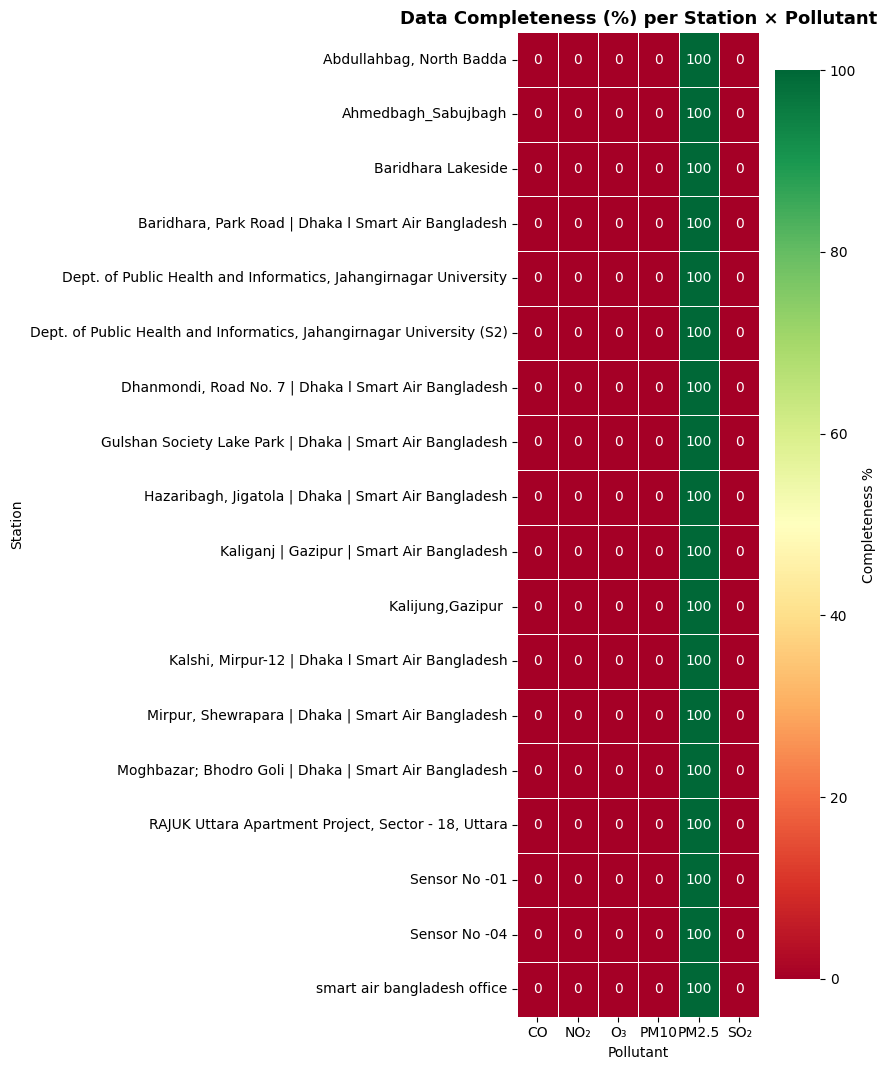

✅ Heatmap saved to /kaggle/working/outputs/qc_completeness_heatmap.png


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2.8 – Data Quality Control Report
# ─────────────────────────────────────────────────────────────────────────────

# --- 1. Overall completeness per pollutant
# FIX: compute total count ONCE (outside loop) to avoid N redundant Spark actions
total_rows = long_sdf.count()

# Compute all per-pollutant stats in a single Spark pass
qc_agg_exprs = []
for p in POLLUTANTS:
    if p in long_sdf.columns:
        qc_agg_exprs += [
            F.sum(F.col(p).isNotNull().cast("int")).alias(f"valid_{p}"),
            F.mean(p).alias(f"mean_{p}"),
            F.max(p).alias(f"max_{p}"),
        ]

if qc_agg_exprs:
    qc_stats = long_sdf.agg(*qc_agg_exprs).first().asDict()
else:
    qc_stats = {}

qc_rows = []
for p in POLLUTANTS:
    if p not in long_sdf.columns:
        continue
    valid   = qc_stats.get(f"valid_{p}", 0) or 0
    avg_val = qc_stats.get(f"mean_{p}",  0.0) or 0.0
    max_val = qc_stats.get(f"max_{p}",   0.0) or 0.0
    pct     = valid / total_rows * 100 if total_rows > 0 else 0.0
    who_lim = WHO_GUIDELINES.get(p, float("nan"))
    qc_rows.append({
        "Pollutant"      : PARAMETER_MAP.get(p, p),
        "Valid Records"  : f"{valid:,}",
        "Completeness %" : f"{pct:.1f}%",
        "Mean (µg/m³)"  : f"{avg_val:.1f}",
        "Max (µg/m³)"   : f"{max_val:.1f}",
        "WHO Limit"      : f"{who_lim}",
        "Exceedance"     : "\u2757" if avg_val > who_lim else "\u2705",
    })

qc_df = pd.DataFrame(qc_rows)
print("\n\u2500\u2500\u2500 DATA QUALITY CONTROL REPORT \u2500\u2500\u2500")
print(qc_df.to_string(index=False))
qc_df.to_csv(OUTPUT_DIR / "qc_report.csv", index=False)

# --- 2. Completeness heatmap by station & pollutant --------------------------
heatmap_data = []
for p in POLLUTANTS:
    if p not in long_sdf.columns:
        continue
    station_comp = (
        long_sdf
        .groupBy("location_id", "name")
        .agg(
            (F.sum(F.col(p).isNotNull().cast("int")) / F.count("*") * 100).alias("completeness")
        )
        .toPandas()
    )
    station_comp["pollutant"] = PARAMETER_MAP.get(p, p)
    heatmap_data.append(station_comp)

heatmap_pd = pd.concat(heatmap_data, ignore_index=True) if heatmap_data else pd.DataFrame()

if not heatmap_pd.empty:
    pivot_hm = heatmap_pd.pivot_table(
        index="name", columns="pollutant", values="completeness", aggfunc="mean"
    )
    fig, ax = plt.subplots(figsize=(max(8, len(POLLUTANTS)*1.4), max(4, len(pivot_hm)*0.6)))
    sns.heatmap(
        pivot_hm, annot=True, fmt=".0f", cmap="RdYlGn", vmin=0, vmax=100,
        linewidths=0.5, ax=ax, cbar_kws={"label": "Completeness %"}
    )
    ax.set_title("Data Completeness (%) per Station × Pollutant", fontsize=13, fontweight="bold")
    ax.set_xlabel("Pollutant"); ax.set_ylabel("Station")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "qc_completeness_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\u2705 Heatmap saved to {OUTPUT_DIR / 'qc_completeness_heatmap.png'}")

## 3. Spatial & environmental enrichment

Weather comes from Open-Meteo when available. Population uses WorldPop when the raster is available, otherwise the existing clearly flagged area-lookup fallback is used. AQI is computed with native Spark expressions.

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3.1 – Fetch hourly weather from Open-Meteo (free, no key required)
# IS_SYNTHETIC_WEATHER is set to True if the live API fails and fallback
# synthetic data is used — flagged transparently in QC output.
# ─────────────────────────────────────────────────────────────────────────────

WEATHER_CACHE = RAW_DIR / "weather_openmeteo.json"

OPEN_METEO_VARS = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "wind_speed_10m",
    "wind_direction_10m",
    "surface_pressure",
    "boundary_layer_height",
]

def fetch_open_meteo_weather(
    lat: float,
    lon: float,
    start: datetime.date,
    end: datetime.date,
    variables: List[str],
) -> pd.DataFrame:
    """
    Fetch hourly reanalysis weather from Open-Meteo historical API.
    If boundary_layer_height is unavailable, retries without it.
    """
    def _get(vars_list):
        params = {
            "latitude"  : lat,
            "longitude" : lon,
            "start_date": start.isoformat(),
            "end_date"  : end.isoformat(),
            "hourly"    : ",".join(vars_list),
            "timezone"  : "UTC",
        }
        r = requests.get(
            "https://archive-api.open-meteo.com/v1/archive",
            params=params, timeout=60,
        )
        r.raise_for_status()
        return r.json()

    try:
        data = _get(variables)
    except Exception:
        vars_reduced = [v for v in variables if v != "boundary_layer_height"]
        data = _get(vars_reduced)

    hourly = data.get("hourly", {})
    df = pd.DataFrame(hourly)
    if "time" in df.columns:
        df["datetime_utc"] = pd.to_datetime(df["time"], utc=True)
        df = df.drop(columns=["time"])
    if "boundary_layer_height" not in df.columns:
        df["boundary_layer_height"] = float("nan")
    return df


IS_SYNTHETIC_WEATHER = False   # Will be set True if live API fails

if WEATHER_CACHE.exists():
    print(f"⚠️  Loading cached weather data from {WEATHER_CACHE}")
    weather_pd = pd.read_json(WEATHER_CACHE)
    weather_pd["datetime_utc"] = pd.to_datetime(weather_pd["datetime_utc"], utc=True)
else:
    print("⛅  Fetching hourly weather from Open-Meteo...")
    try:
        weather_pd = fetch_open_meteo_weather(
            lat=DHAKA_LAT, lon=DHAKA_LON,
            start=START_DATE, end=END_DATE,
            variables=OPEN_METEO_VARS,
        )
        weather_pd.to_json(WEATHER_CACHE, orient="records", date_format="iso")
        print(f"✅ Weather fetched and cached at {WEATHER_CACHE}")
    except Exception as e:
        print(f"⚠️  Open-Meteo fetch failed ({e}). Generating SYNTHETIC weather — FLAGGED.")
        IS_SYNTHETIC_WEATHER = True
        date_range = pd.date_range(START_DATE, END_DATE, freq="h", tz="UTC")
        rng   = np.random.default_rng(42)
        month = date_range.month.values
        temp_base = np.array([20,22,27,31,32,29,28,28,29,28,24,20])[month - 1].astype(float)
        hum_base  = np.array([70,65,72,80,88,92,90,88,85,80,75,72])[month - 1].astype(float)
        weather_pd = pd.DataFrame({
            "datetime_utc"          : date_range,
            "temperature_2m"        : temp_base + rng.normal(0, 1.5, len(date_range)),
            "relative_humidity_2m"  : hum_base  + rng.normal(0, 3.0, len(date_range)),
            "precipitation"         : np.clip(rng.exponential(0.3, len(date_range)), 0, 50),
            "wind_speed_10m"        : np.clip(rng.exponential(8,   len(date_range)), 0, 60),
            "wind_direction_10m"    : rng.uniform(0, 360, len(date_range)),
            "surface_pressure"      : rng.normal(1011, 4, len(date_range)),
            "boundary_layer_height" : np.clip(
                np.where(month <= 4,
                    rng.normal(900,  150, len(date_range)),
                    np.where(month <= 9,
                        rng.normal(1400, 250, len(date_range)),
                        rng.normal(800,  120, len(date_range))
                    )
                ), 200, 3000
            ),
        })

synthetic_label = "⚠️ SYNTHETIC FALLBACK" if IS_SYNTHETIC_WEATHER else "✅ Live API"
print(f"✅ Weather DataFrame: {len(weather_pd):,} rows  [{synthetic_label}]")
weather_pd.head(3)


⛅  Fetching hourly weather from Open-Meteo...
✅ Weather fetched and cached at /kaggle/working/data/raw/weather_openmeteo.json
✅ Weather DataFrame: 8,784 rows  [✅ Live API]


,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,wind_direction_10m,surface_pressure,boundary_layer_height,datetime_utc
0,25.5,95,3.2,7.2,152,1004.8,300.0,2025-09-12 00:00:00+00:00
1,26.8,93,0.4,6.0,141,1005.5,205.0,2025-09-12 01:00:00+00:00
2,27.1,93,0.9,9.3,148,1006.0,245.0,2025-09-12 02:00:00+00:00


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3.2 – Join weather data to AQ Spark DataFrame on UTC hour
# ─────────────────────────────────────────────────────────────────────────────

# Prepare weather: floor to the hour as join key
weather_pd["ts_hour"] = weather_pd["datetime_utc"].dt.floor("h")
weather_pd = weather_pd.rename(columns={
    "temperature_2m"       : "temp_c",
    "relative_humidity_2m" : "rh_pct",
    "precipitation"        : "precip_mm",
    "wind_speed_10m"       : "wind_speed_kmh",
    "wind_direction_10m"   : "wind_dir_deg",
    "surface_pressure"     : "pressure_hpa",
    "boundary_layer_height": "blh_m",
})

WEATHER_COLS = ["ts_hour", "temp_c", "rh_pct", "precip_mm",
                "wind_speed_kmh", "wind_dir_deg", "pressure_hpa", "blh_m"]
weather_pd = weather_pd[WEATHER_COLS].drop_duplicates(subset="ts_hour")

# Create Spark weather DF
weather_sdf = spark.createDataFrame(weather_pd)
weather_sdf = weather_sdf.withColumn("ts_hour", F.date_trunc("hour", F.col("ts_hour")))

# Create join key in AQ DF
long_sdf = long_sdf.withColumn("ts_hour", F.date_trunc("hour", F.col("ts")))

# Left join: AQ ◄─ Weather
enriched_sdf = long_sdf.join(weather_sdf, on="ts_hour", how="left")
enriched_sdf.cache()

print(f"\u2705 Weather join complete.")
print(f"   Enriched DF shape: {enriched_sdf.count():,} rows x {len(enriched_sdf.columns)} cols")
print(f"   Temp coverage: {enriched_sdf.filter(F.col('temp_c').isNotNull()).count():,} rows have weather data")

✅ Weather join complete.
   Enriched DF shape: 47,380 rows x 26 cols
   Temp coverage: 47,380 rows have weather data


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3.3 – Population enrichment
# Updated to use the user-provided WorldPop raster path.
# ─────────────────────────────────────────────────────────────────────────────

import math
try:
    import rasterio
    from rasterio.transform import rowcol
    HAVE_RASTERIO = True
except ImportError:
    HAVE_RASTERIO = False
    print("⚠️ rasterio not available — will fall back to the synthetic area-lookup.")

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a    = math.sin(dlat/2)**2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon/2)**2
    return R * 2 * math.asin(math.sqrt(a))

# WorldPop raster path resolved by the Kaggle configuration cell at the top
# of the notebook (WORLDPOP_TIF_PATH). Add the .tif as a Kaggle Dataset and
# set/auto-detect its path there — nothing to change here.
WORLDPOP_PATH = WORLDPOP_TIF_PATH
IS_SYNTHETIC_POPULATION = True

if WORLDPOP_PATH and WORLDPOP_PATH.exists() and HAVE_RASTERIO:
    print(f"✅ WorldPop raster found: {WORLDPOP_PATH}")
    try:
        CATCHMENT_RADIUS_KM = 5.0

        with rasterio.open(WORLDPOP_PATH) as src:
            pop_array = src.read(1)
            transform = src.transform

        pop_per_station = {}
        for _, row in stations_df.iterrows():
            sid   = row["location_id"]
            s_lat = row["latitude"]
            s_lon = row["longitude"]

            # Project coordinates to raster row/col
            r_py, c_py = rowcol(transform, s_lon, s_lat)

            # Estimate pixel radius (100m resolution)
            radius_px = int(CATCHMENT_RADIUS_KM * 1000 / 100)
            r0 = max(0, r_py - radius_px); r1 = min(pop_array.shape[0], r_py + radius_px)
            c0 = max(0, c_py - radius_px); c1 = min(pop_array.shape[1], c_py + radius_px)

            station_pop = float(np.nansum(pop_array[r0:r1, c0:c1]))
            pop_per_station[sid] = station_pop

        IS_SYNTHETIC_POPULATION = False
        print("✅ WorldPop raster loaded — using real gridded population data.")
    except Exception as e:
        print(f"⚠️ Error processing raster ({e}) — falling back to census area-lookup.")
        WORLDPOP_PATH = None
else:
    print(f"⚠️ WorldPop raster not found at {WORLDPOP_PATH}")
    WORLDPOP_PATH = None

if not WORLDPOP_PATH:
    IS_SYNTHETIC_POPULATION = True
    DHAKA_AREA_POPULATIONS = {
        "Mirpur": 1_200_000, "Dhanmondi": 600_000, "Gulshan": 450_000,
        "Uttara": 850_000, "Old Dhaka": 1_500_000, "Tejgaon": 700_000,
        "Motijheel": 500_000, "Narayanganj": 750_000, "default": 600_000,
    }
    pop_per_station = {}
    for _, row in stations_df.iterrows():
        sid   = int(row["location_id"])
        sname = str(row["name"])
        matched = False
        for area, pop in DHAKA_AREA_POPULATIONS.items():
            if area.lower() in sname.lower():
                pop_per_station[sid] = pop; matched = True; break
        if not matched: pop_per_station[sid] = DHAKA_AREA_POPULATIONS["default"]

# Build station-population lookup Spark DF
pop_lookup = pd.DataFrame([
    {"location_id": int(sid), "catchment_pop": int(pop)}
    for sid, pop in pop_per_station.items()
])
pop_sdf = spark.createDataFrame(pop_lookup)

# Join population to enriched DF
enriched_sdf = enriched_sdf.drop("catchment_pop").join(pop_sdf, on="location_id", how="left").fillna({"catchment_pop": 600_000})

syn_pop_label = "⚠️ SYNTHETIC" if IS_SYNTHETIC_POPULATION else "✅ WorldPop raster"
print(f"✅ Population enrichment complete [{syn_pop_label}]")

✅ WorldPop raster found: /kaggle/input/datasets/mahadirrahaman/population/BGD_ppp_2020_adj_v2.tif
✅ WorldPop raster loaded — using real gridded population data.
✅ Population enrichment complete [✅ WorldPop raster]


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3.4 – Population-weighted exposure + AQI (native Spark expressions)
# AQI breakpoint interpolation uses F.when() chains — NO Python UDFs,
# so Spark executes in JVM without BatchEvalPython overhead.
# Also stamps synthetic-data provenance flags on enriched_sdf.
# ─────────────────────────────────────────────────────────────────────────────

# ── 3.4a Population-weighted exposure ────────────────────────────────────────
for p in ["pm25", "pm10"]:
    if p in enriched_sdf.columns:
        enriched_sdf = enriched_sdf.withColumn(
            f"pwe_{p}",
            F.col(p) * F.col("catchment_pop") / 1e6
        )

# ── 3.4b AQI via native Spark F.when() chains (no Python UDFs) ──────────────

def _aqi_from_col(col, breakpoints):
    """
    Compute AQI from a concentration column using US EPA linear interpolation.
    breakpoints: list of (c_lo, c_hi, i_lo, i_hi) tuples.
    Returns a Column expression (no Python UDF — runs in JVM).
    """
    expr = F.when(col > breakpoints[-1][1], F.lit(500.0).cast(T.DoubleType()))
    for c_lo, c_hi, i_lo, i_hi in reversed(breakpoints):
        slope = (i_hi - i_lo) / (c_hi - c_lo)
        expr = F.when(
            (col >= F.lit(c_lo)) & (col <= F.lit(c_hi)),
            (F.lit(slope) * (col - F.lit(c_lo)) + F.lit(float(i_lo))).cast(T.DoubleType())
        ).otherwise(expr)
    return F.when(col.isNull(), F.lit(None).cast(T.DoubleType())).otherwise(expr)

AQI_BP_PM25 = [
    (0.0,   12.0,   0,  50),
    (12.1,  35.4,  51, 100),
    (35.5,  55.4, 101, 150),
    (55.5, 150.4, 151, 200),
    (150.5,250.4, 201, 300),
    (250.5,350.4, 301, 400),
    (350.5,500.4, 401, 500),
]
AQI_BP_PM10 = [
    (0,   54,   0,  50),
    (55, 154,  51, 100),
    (155,254, 101, 150),
    (255,354, 151, 200),
    (355,424, 201, 300),
    (425,504, 301, 400),
    (505,604, 401, 500),
]

_aqi_pm25_col = _aqi_from_col(F.col("pm25"), AQI_BP_PM25) if "pm25" in enriched_sdf.columns else F.lit(None).cast(T.DoubleType())
_aqi_pm10_col = _aqi_from_col(F.col("pm10"), AQI_BP_PM10) if "pm10" in enriched_sdf.columns else F.lit(None).cast(T.DoubleType())

# AQI category — also native (no Python UDF)
def _aqi_cat_expr(col):
    return (
        F.when(col.isNull(),    F.lit("Unknown"))
         .when(col <= 50,       F.lit("Good"))
         .when(col <= 100,      F.lit("Moderate"))
         .when(col <= 150,      F.lit("Unhealthy for Sensitive Groups"))
         .when(col <= 200,      F.lit("Unhealthy"))
         .when(col <= 300,      F.lit("Very Unhealthy"))
         .otherwise(            F.lit("Hazardous"))
    )

enriched_sdf = (
    enriched_sdf
    .withColumn("aqi_pm25", _aqi_pm25_col)
    .withColumn("aqi_pm10", _aqi_pm10_col)
    .withColumn("aqi",      F.greatest(F.col("aqi_pm25"), F.col("aqi_pm10")))
    .withColumn("aqi_cat",  _aqi_cat_expr(F.col("aqi")))
)

# ── 3.4c Pure-Python AQI category helper ────────────────────────────────────
import math as _math_aqi
def _aqi_cat_py(aqi_val):
    if aqi_val is None or (isinstance(aqi_val, float) and _math_aqi.isnan(aqi_val)):
        return "Unknown"
    if aqi_val <= 50:  return "Good"
    if aqi_val <= 100: return "Moderate"
    if aqi_val <= 150: return "Unhealthy for Sensitive Groups"
    if aqi_val <= 200: return "Unhealthy"
    if aqi_val <= 300: return "Very Unhealthy"
    return "Hazardous"

# ── 3.4d Stamp provenance flags on enriched_sdf ──────────────────────────────
enriched_sdf = (
    enriched_sdf
    .withColumn("is_synthetic_weather",    F.lit(IS_SYNTHETIC_WEATHER))
    .withColumn("is_synthetic_population", F.lit(IS_SYNTHETIC_POPULATION))
)

enriched_sdf.cache()
print(f"✅ Population-weighted exposure + AQI columns added (native Spark expressions — no Python UDFs).")
print(f"   Final enriched DF: {enriched_sdf.count():,} rows x {len(enriched_sdf.columns)} columns")

# ── 3.4e QC synthetic-data report ────────────────────────────────────────────
for flag_col, label in [("is_synthetic_weather", "weather"), ("is_synthetic_population", "population")]:
    if flag_col in enriched_sdf.columns:
        pct = enriched_sdf.select(F.mean(F.col(flag_col).cast("int"))).first()[0]
        pct_display = pct * 100 if pct is not None else 0
        marker = "⚠️" if pct_display > 0 else "✅"
        print(f"   {marker} Synthetic {label}: {pct_display:.1f}% of rows")

# Save fully enriched Parquet
ENRICHED_PARQUET = str(PROCESSED_DIR / "aq_enriched.parquet")
(
    enriched_sdf
    .repartition(4, "year", "month")
    .write.mode("overwrite")
    .partitionBy("year", "month")
    .parquet(ENRICHED_PARQUET)
)
print(f"✅ Enriched Parquet saved: {ENRICHED_PARQUET}")


✅ Population-weighted exposure + AQI columns added (native Spark expressions — no Python UDFs).
   Final enriched DF: 47,380 rows x 35 columns
   ✅ Synthetic weather: 0.0% of rows
   ✅ Synthetic population: 0.0% of rows
✅ Enriched Parquet saved: /kaggle/working/data/processed/aq_enriched.parquet


## 4. Exploratory analysis — static PNG visualizations

All charts below are rendered with Matplotlib/Seaborn and saved as PNG files in `outputs/`. There are no Plotly HTML files and no Folium maps.

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4.0 – Convert enriched SDF to pandas for visualisations
# Arrow-accelerated toPandas() via the cached Spark DF
# ─────────────────────────────────────────────────────────────────────────────

# Select only the columns needed for EDA (avoid pulling huge Parquet)
EDA_COLS = [
    "location_id", "name", "ts", "date", "year", "month", "hour", "dow", "season",
    "lat", "lon", "catchment_pop",
    "pm25", "pm10", "no2", "o3", "so2", "co",
    "aqi", "aqi_cat", "aqi_pm25", "aqi_pm10",
    "pwe_pm25", "pwe_pm10",
    "temp_c", "rh_pct", "precip_mm", "wind_speed_kmh", "wind_dir_deg",
    "pressure_hpa", "blh_m",
]

available_cols = [c for c in EDA_COLS if c in enriched_sdf.columns]
eda_pd = enriched_sdf.select(*available_cols).toPandas()

# Type coercions
eda_pd["ts"]   = pd.to_datetime(eda_pd["ts"], utc=True)
eda_pd["date"] = pd.to_datetime(eda_pd["date"])

for col in ["pm25", "pm10", "no2", "o3", "so2", "co",
            "aqi", "temp_c", "rh_pct", "precip_mm",
            "wind_speed_kmh", "wind_dir_deg", "blh_m"]:
    if col in eda_pd.columns:
        eda_pd[col] = pd.to_numeric(eda_pd[col], errors="coerce")

print(f"\u2705 EDA DataFrame: {len(eda_pd):,} rows, {eda_pd.shape[1]} cols")
print(f"   Date range   : {eda_pd['date'].min()} → {eda_pd['date'].max()}")
print(f"   Stations     : {eda_pd['name'].nunique()}")
print("\nColumn preview:")
eda_pd.head(2)

✅ EDA DataFrame: 47,380 rows, 31 cols
   Date range   : 2025-10-05 00:00:00 → 2026-09-12 00:00:00
   Stations     : 18

Column preview:


,location_id,name,ts,date,year,month,hour,dow,season,lat,...,aqi_pm10,pwe_pm25,pwe_pm10,temp_c,rh_pct,precip_mm,wind_speed_kmh,wind_dir_deg,pressure_hpa,blh_m
0,6236590,"Hazaribagh, Jigatola | Dhaka | Smart Air Bangl...",2026-02-12 06:00:00+00:00,2026-02-12,2026,2,6,5,Winter,NaN,...,NaN,287.452598,NaN,27.9,28,0.0,7.5,312,1015.1,1500.0
1,6236590,"Hazaribagh, Jigatola | Dhaka | Smart Air Bangl...",2026-02-13 09:00:00+00:00,2026-02-13,2026,2,9,6,Winter,NaN,...,NaN,311.057915,NaN,29.7,27,0.0,8.9,339,1009.7,1855.0


In [23]:
# # Interactive Folium Map: Station AQI & Spatial Markers


# import math
# import folium
# from folium import plugins
# from branca.element import Element
# from IPython.display import display, HTML

# # 1. Coordinate Recovery & Merge
# map_df = eda_pd.copy()

# # Recover lat/lon from stations_df if missing in eda_pd
# if "stations_df" in globals() and not stations_df.empty:
#     station_coords = stations_df[["location_id", "latitude", "longitude"]].rename(
#         columns={"latitude": "st_lat", "longitude": "st_lon"}
#     )
#     station_coords["location_id"] = pd.to_numeric(station_coords["location_id"], errors="coerce")
#     map_df["location_id"] = pd.to_numeric(map_df["location_id"], errors="coerce")

#     map_df = map_df.merge(station_coords, on="location_id", how="left")
#     map_df["lat"] = map_df["lat"].fillna(map_df["st_lat"])
#     map_df["lon"] = map_df["lon"].fillna(map_df["st_lon"])

# # Fallback coordinates for known Dhaka areas if still NaN
# DHAKA_DEFAULT_COORDS = {
#     "us embassy": (23.7979, 90.4225),
#     "dhanmondi": (23.7461, 90.3742),
#     "mirpur": (23.8223, 90.3654),
#     "uttara": (23.8759, 90.3795),
#     "gulshan": (23.7925, 90.4078),
#     "farmgate": (23.7561, 90.3872),
#     "motijheel": (23.7330, 90.4172),
#     "savar": (23.8474, 90.2577),
#     "gazipur": (23.9999, 90.4203),
#     "narayanganj": (23.6238, 90.5000),
# }

# def fill_coords_by_name(row):
#     lat, lon = row.get("lat"), row.get("lon")
#     if pd.notnull(lat) and pd.notnull(lon):
#         return lat, lon
#     name_str = str(row.get("name", "")).lower()
#     for area, coords in DHAKA_DEFAULT_COORDS.items():
#         if area in name_str:
#             return coords
#     # Default spread around Dhaka center
#     rng = np.random.default_rng(int(row.get("location_id", 0)) % 1000)
#     return (float(DHAKA_LAT) + rng.uniform(-0.06, 0.06), float(DHAKA_LON) + rng.uniform(-0.06, 0.06))

# applied_coords = map_df.apply(fill_coords_by_name, axis=1)
# map_df["lat"] = [c[0] for c in applied_coords]
# map_df["lon"] = [c[1] for c in applied_coords]

# # 2. AQI Calculation & Categorization
# AQI_BP_PM25 = [
#     (0.0, 12.0, 0, 50),
#     (12.1, 35.4, 51, 100),
#     (35.5, 55.4, 101, 150),
#     (55.5, 150.4, 151, 200),
#     (150.5, 250.4, 201, 300),
#     (250.5, 350.4, 301, 400),
#     (350.5, 500.4, 401, 500),
# ]

# def calc_aqi(pm25):
#     if pm25 is None or pd.isna(pm25):
#         return None
#     for c_lo, c_hi, i_lo, i_hi in AQI_BP_PM25:
#         if c_lo <= pm25 <= c_hi:
#             return float((i_hi - i_lo) / (c_hi - c_lo) * (pm25 - c_lo) + i_lo)
#     return 500.0 if pm25 > 500 else 0.0

# def get_aqi_cat(aqi):
#     if aqi is None or pd.isna(aqi): return "Unknown"
#     if aqi <= 50: return "Good"
#     if aqi <= 100: return "Moderate"
#     if aqi <= 150: return "Unhealthy for Sensitive Groups"
#     if aqi <= 200: return "Unhealthy"
#     if aqi <= 300: return "Very Unhealthy"
#     return "Hazardous"

# AQI_COLORS = {
#     "Good": "#009966",
#     "Moderate": "#FFDE33",
#     "Unhealthy for Sensitive Groups": "#FF9933",
#     "Unhealthy": "#CC0033",
#     "Very Unhealthy": "#660099",
#     "Hazardous": "#7E0023",
#     "Unknown": "#888888",
# }

# # 3. Aggregate Station Summary
# station_summary = (
#     map_df.dropna(subset=["pm25"])
#     .groupby(["name", "lat", "lon"])
#     .agg(mean_pm25=("pm25", "mean"), readings=("pm25", "count"))
#     .reset_index()
# )
# station_summary["mean_aqi"] = station_summary["mean_pm25"].apply(calc_aqi)
# station_summary["category"] = station_summary["mean_aqi"].apply(get_aqi_cat)

# print(f"Plotted Stations ({len(station_summary)} total):")
# print(station_summary[["name", "lat", "lon", "mean_pm25", "mean_aqi", "category"]].to_string(index=False))

# # 4. Initialize Folium Map
# m = folium.Map(
#     location=[float(DHAKA_LAT), float(DHAKA_LON)],
#     zoom_start=11,
#     tiles="OpenStreetMap",
#     prefer_canvas=True,
# )

# # Add HeatMap Cloud Layer
# heat_points = [
#     [float(r["lat"]), float(r["lon"]), float(r["mean_pm25"])]
#     for _, r in station_summary.iterrows()
# ]
# if heat_points:
#     plugins.HeatMap(
#         heat_points,
#         radius=40,
#         blur=25,
#         max_zoom=13,
#         min_opacity=0.35,
#         gradient={0.2: "#009966", 0.4: "#FFDE33", 0.6: "#FF9933", 0.8: "#CC0033", 1.0: "#7E0023"},
#         name="PM2.5 Pollution Heatmap",
#     ).add_to(m)

# # Add Solid Station Markers
# for _, row in station_summary.iterrows():
#     cat = row["category"]
#     color = AQI_COLORS.get(cat, "#888888")
#     aqi_val = row["mean_aqi"]

#     popup_html = f"""
#     <div style="font-family: Arial, sans-serif; font-size: 12px; min-width: 170px; line-height: 1.5;">
#         <b style="font-size: 13px; color: #111;">{row['name']}</b>
#         <hr style="margin: 4px 0;">
#         <b>AQI:</b> {aqi_val:.0f}<br>
#         <b>Category:</b> <span style="color: {color}; font-weight: bold;">{cat}</span><br>
#         <b>Mean PM2.5:</b> {row['mean_pm25']:.1f} µg/m³<br>
#         <b>Readings:</b> {int(row['readings']):,}
#     </div>
#     """

#     folium.CircleMarker(
#         location=[float(row["lat"]), float(row["lon"])],
#         radius=13,
#         color="#000000",
#         weight=2,
#         fill=True,
#         fill_color=color,
#         fill_opacity=0.9,
#         tooltip=f"{row['name']} | AQI: {aqi_val:.0f} ({cat})",
#         popup=folium.Popup(popup_html, max_width=280),
#     ).add_to(m)

# # 5. Direct HTML Legend Overlay
# legend_html = """
# <div style="
#     position: fixed;
#     bottom: 30px;
#     left: 30px;
#     z-index: 9999;
#     background-color: white;
#     padding: 10px 14px;
#     border: 2px solid #555;
#     border-radius: 8px;
#     font-family: Arial, sans-serif;
#     font-size: 12px;
#     line-height: 1.6;
#     box-shadow: 0 4px 10px rgba(0,0,0,0.3);
# ">
#     <b style="font-size: 13px;">AQI Category Scale</b><br>
#     <span style="color:#009966; font-size:15px;">●</span> Good (&le; 50)<br>
#     <span style="color:#FFDE33; font-size:15px;">●</span> Moderate (51–100)<br>
#     <span style="color:#FF9933; font-size:15px;">●</span> USG (101–150)<br>
#     <span style="color:#CC0033; font-size:15px;">●</span> Unhealthy (151–200)<br>
#     <span style="color:#660099; font-size:15px;">●</span> Very Unhealthy (201–300)<br>
#     <span style="color:#7E0023; font-size:15px;">●</span> Hazardous (&gt; 300)
# </div>
# """
# m.get_root().html.add_child(Element(legend_html))
# folium.LayerControl().add_to(m)

# # Save & Render
# MAP_PATH = str(OUTPUT_DIR / "4_9_dhaka_aqi_map.html")
# m.save(MAP_PATH)
# print(f"✅ Map saved to: {MAP_PATH}")

# display(m)


In [24]:

# Common plotting settings
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "figure.dpi": 120,
})
sns.set_theme(style="whitegrid")

def save_show(fig, filename):
    path = OUTPUT_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"✅ Saved: {path}")


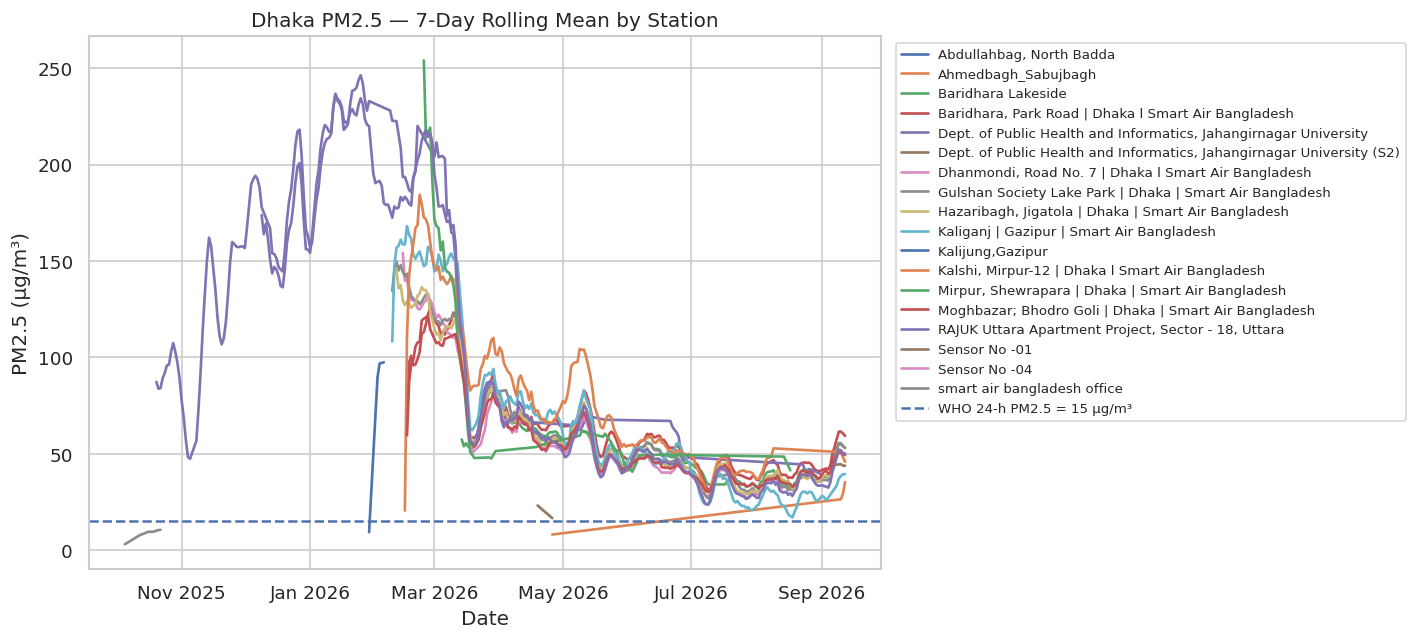

✅ Saved: /kaggle/working/outputs/4_1_pm25_temporal_trend.png


In [25]:

# 4.1 Temporal PM2.5 trend — rolling 7-day mean
if "pm25" in eda_pd.columns and eda_pd["pm25"].notna().any():
    d = eda_pd.dropna(subset=["pm25", "ts"]).copy()
    d["day_date"] = d["ts"].dt.floor("D")
    daily = d.groupby(["day_date", "name"], as_index=False)["pm25"].mean()
    daily["rolling_7d"] = daily.groupby("name")["pm25"].transform(
        lambda s: s.rolling(7, min_periods=1).mean()
    )
    fig, ax = plt.subplots(figsize=(12, 5.5))
    for name, g in daily.groupby("name"):
        ax.plot(g["day_date"], g["rolling_7d"], linewidth=1.6, label=str(name))
    ax.axhline(15, linestyle="--", linewidth=1.5, label="WHO 24-h PM2.5 = 15 µg/m³")
    ax.set_title("Dhaka PM2.5 — 7-Day Rolling Mean by Station")
    ax.set_xlabel("Date"); ax.set_ylabel("PM2.5 (µg/m³)")
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    save_show(fig, "4_1_pm25_temporal_trend.png")
else:
    print("⚠️ PM2.5 unavailable — 4.1 skipped.")


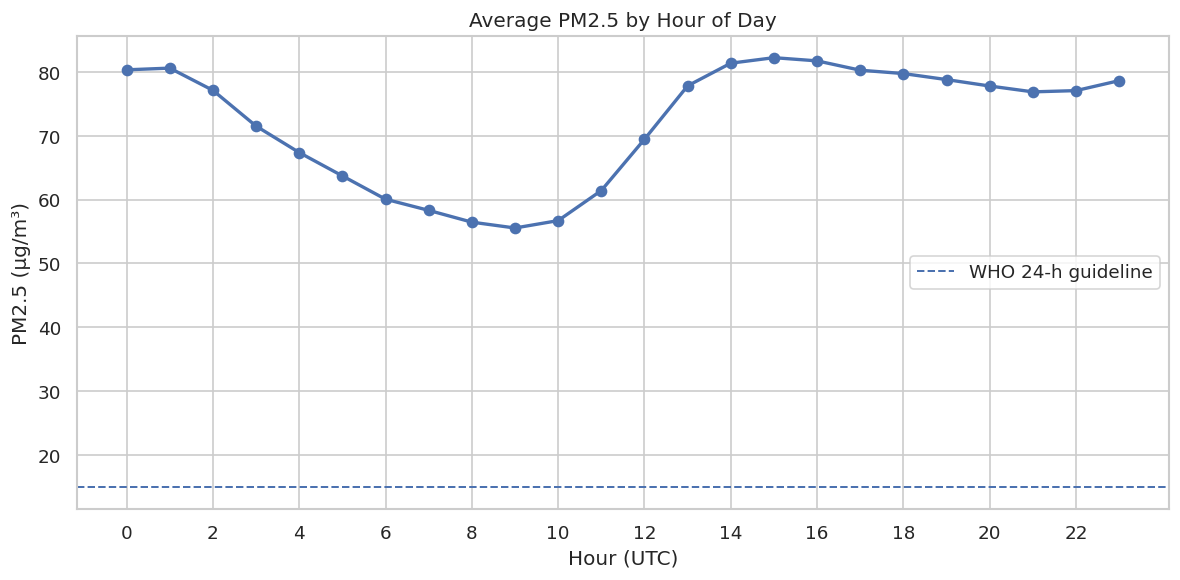

✅ Saved: /kaggle/working/outputs/4_2_diurnal_pm25.png


In [26]:

# 4.2 Diurnal PM2.5 cycle
if {"pm25", "hour"}.issubset(eda_pd.columns):
    diurnal = eda_pd.dropna(subset=["pm25"]).groupby("hour")["pm25"].mean()
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(diurnal.index, diurnal.values, marker="o", linewidth=2)
    ax.axhline(15, linestyle="--", linewidth=1.2, label="WHO 24-h guideline")
    ax.set_xticks(range(0, 24, 2))
    ax.set_title("Average PM2.5 by Hour of Day")
    ax.set_xlabel("Hour (UTC)"); ax.set_ylabel("PM2.5 (µg/m³)")
    ax.legend()
    save_show(fig, "4_2_diurnal_pm25.png")
else:
    print("⚠️ Required columns unavailable — 4.2 skipped.")


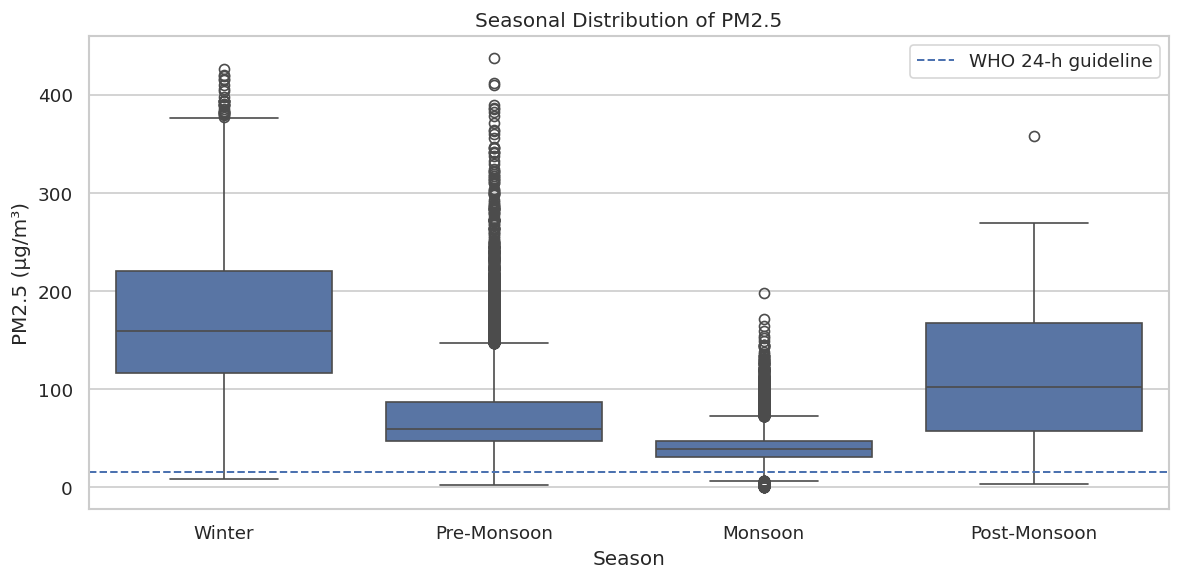

✅ Saved: /kaggle/working/outputs/4_3_seasonal_pm25_boxplot.png


In [27]:

# 4.3 Seasonal PM2.5 distribution
if {"pm25", "season"}.issubset(eda_pd.columns):
    order = ["Winter", "Pre-Monsoon", "Monsoon", "Post-Monsoon"]
    plot_df = eda_pd.dropna(subset=["pm25", "season"]).copy()
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=plot_df, x="season", y="pm25", order=[s for s in order if s in plot_df["season"].unique()], ax=ax)
    ax.axhline(15, linestyle="--", linewidth=1.2, label="WHO 24-h guideline")
    ax.set_title("Seasonal Distribution of PM2.5")
    ax.set_xlabel("Season"); ax.set_ylabel("PM2.5 (µg/m³)")
    ax.legend()
    save_show(fig, "4_3_seasonal_pm25_boxplot.png")


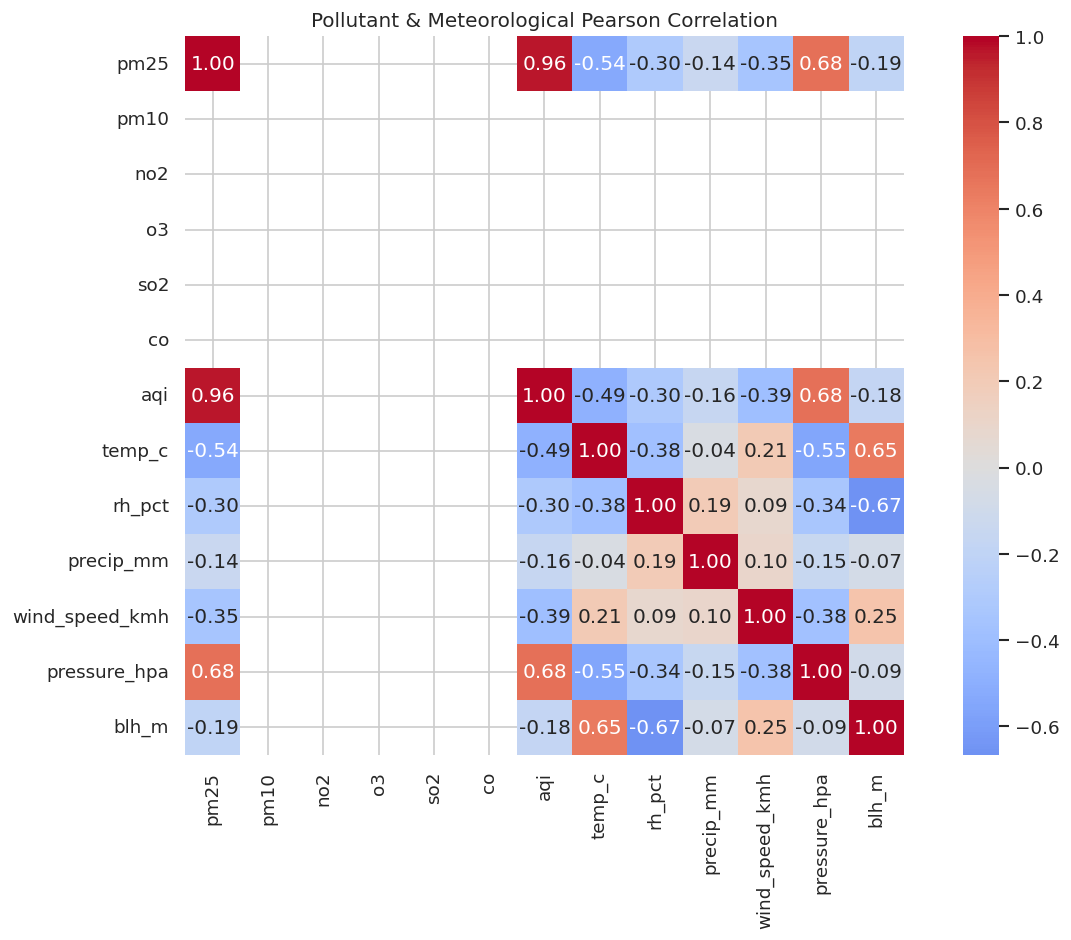

✅ Saved: /kaggle/working/outputs/4_4_correlation_heatmap.png


In [28]:

# 4.4 Pollutant + meteorological correlation heatmap
corr_cols = [c for c in [
    "pm25","pm10","no2","o3","so2","co","aqi",
    "temp_c","rh_pct","precip_mm","wind_speed_kmh","pressure_hpa","blh_m"
] if c in eda_pd.columns]
if len(corr_cols) >= 2:
    corr = eda_pd[corr_cols].corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(11, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax)
    ax.set_title("Pollutant & Meteorological Pearson Correlation")
    save_show(fig, "4_4_correlation_heatmap.png")


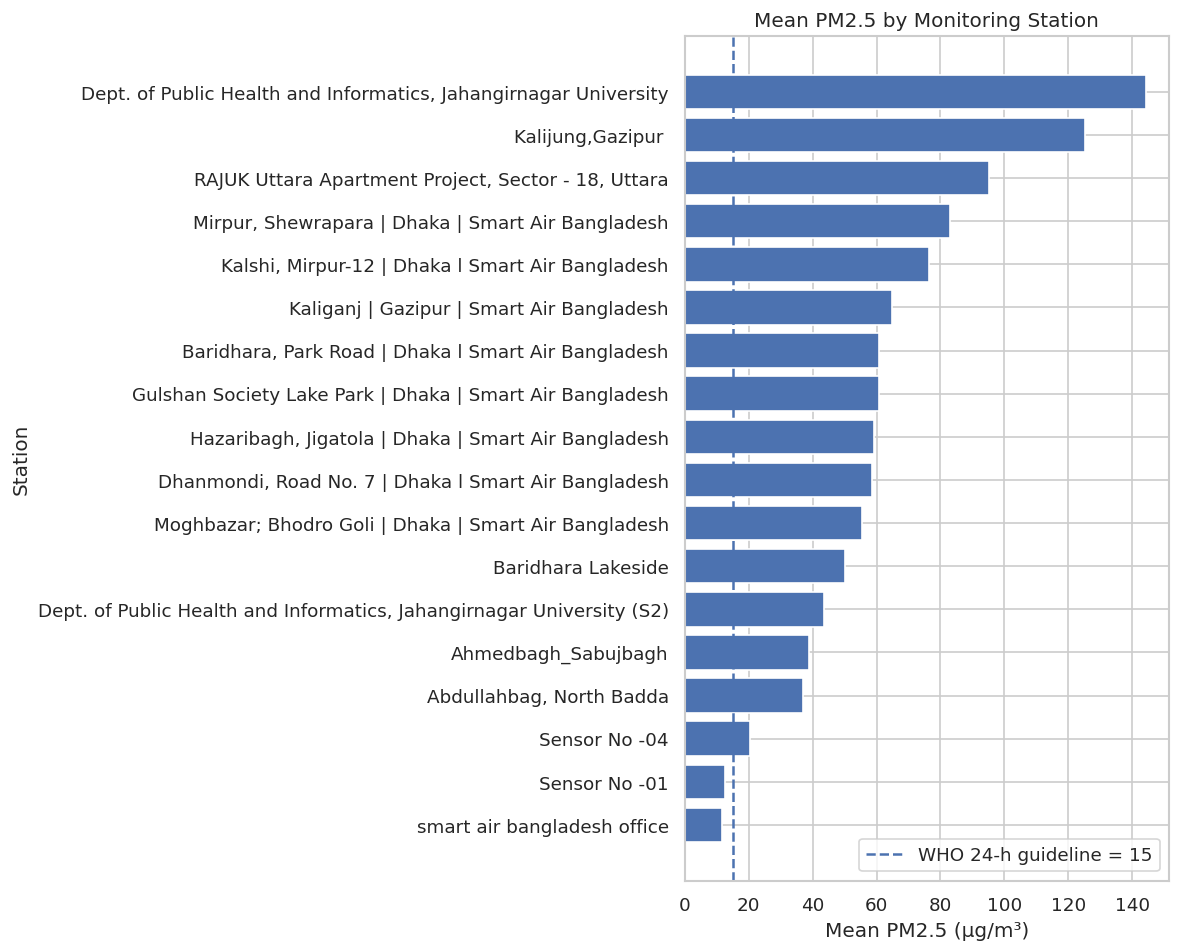

✅ Saved: /kaggle/working/outputs/4_5_station_pm25_vs_who.png


In [29]:

# 4.5 Station comparison — mean PM2.5 vs WHO guideline
if {"pm25","name"}.issubset(eda_pd.columns):
    station_mean = eda_pd.groupby("name")["pm25"].mean().dropna().sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(4, len(station_mean) * 0.45)))
    ax.barh(station_mean.index.astype(str), station_mean.values)
    ax.axvline(15, linestyle="--", linewidth=1.5, label="WHO 24-h guideline = 15")
    ax.set_title("Mean PM2.5 by Monitoring Station")
    ax.set_xlabel("Mean PM2.5 (µg/m³)"); ax.set_ylabel("Station")
    ax.legend()
    save_show(fig, "4_5_station_pm25_vs_who.png")


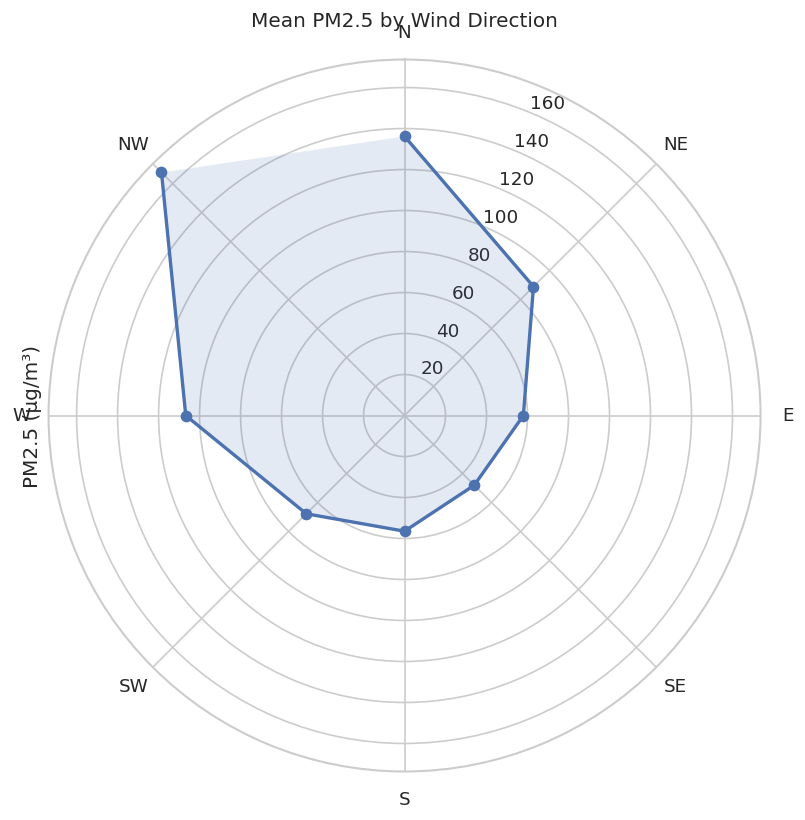

✅ Saved: /kaggle/working/outputs/4_6_wind_direction_pm25.png


In [30]:

# 4.6 Wind-direction relationship — PM2.5 polar mean
if {"pm25","wind_dir_deg"}.issubset(eda_pd.columns):
    w = eda_pd.dropna(subset=["pm25","wind_dir_deg"]).copy()
    w["sector"] = (np.floor(((w["wind_dir_deg"] % 360) + 22.5) / 45) * 45) % 360
    sector_mean = w.groupby("sector")["pm25"].mean().reindex(np.arange(0,360,45))
    theta = np.deg2rad(sector_mean.index.values)
    vals = sector_mean.values
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, polar=True)
    ax.plot(theta, vals, marker="o", linewidth=2)
    ax.fill(theta, vals, alpha=0.15)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_xticks(np.deg2rad(np.arange(0,360,45)))
    ax.set_xticklabels(["N","NE","E","SE","S","SW","W","NW"])
    ax.set_title("Mean PM2.5 by Wind Direction", pad=20)
    ax.set_ylabel("PM2.5 (µg/m³)")
    save_show(fig, "4_6_wind_direction_pm25.png")


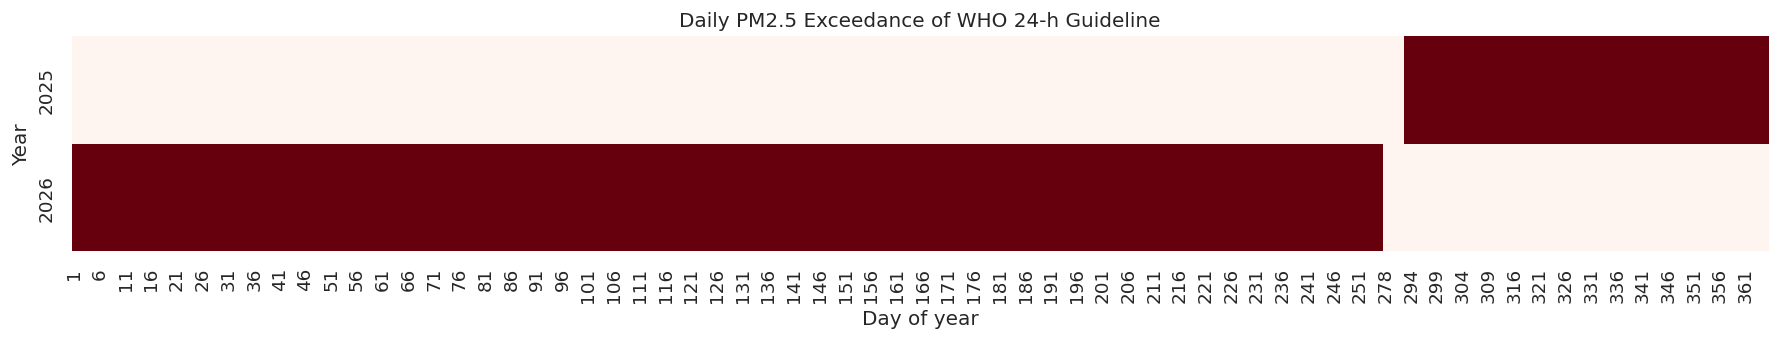

✅ Saved: /kaggle/working/outputs/4_7_who_exceedance_calendar.png


In [31]:

# 4.7 WHO exceedance calendar heatmap
if {"pm25","date"}.issubset(eda_pd.columns):
    daily = eda_pd.groupby("date")["pm25"].mean().dropna()
    if not daily.empty:
        idx = pd.to_datetime(daily.index)
        tmp = pd.DataFrame({"date": idx, "pm25": daily.values})
        tmp["year"] = tmp["date"].dt.year
        tmp["dayofyear"] = tmp["date"].dt.dayofyear
        pivot = tmp.pivot_table(index="year", columns="dayofyear", values="pm25", aggfunc="mean")
        fig, ax = plt.subplots(figsize=(15, max(3, len(pivot) * 1.2)))
        sns.heatmap((pivot > 15).astype(float), cmap="Reds", cbar=False, ax=ax)
        ax.set_title("Daily PM2.5 Exceedance of WHO 24-h Guideline")
        ax.set_xlabel("Day of year"); ax.set_ylabel("Year")
        save_show(fig, "4_7_who_exceedance_calendar.png")


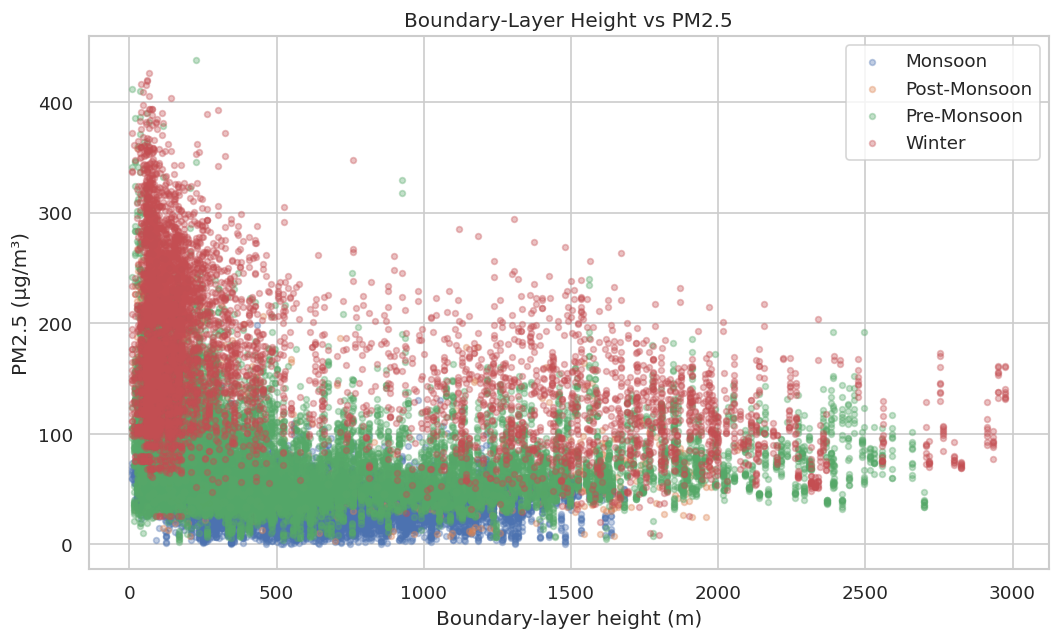

✅ Saved: /kaggle/working/outputs/4_8_blh_vs_pm25.png


In [32]:

# 4.8 Boundary-layer height vs PM2.5
if {"blh_m","pm25"}.issubset(eda_pd.columns):
    s = eda_pd[["blh_m","pm25","season"]].dropna()
    if len(s) > 1:
        fig, ax = plt.subplots(figsize=(9, 5.5))
        for season, g in s.groupby("season"):
            ax.scatter(g["blh_m"], g["pm25"], s=12, alpha=0.35, label=str(season))
        ax.set_title("Boundary-Layer Height vs PM2.5")
        ax.set_xlabel("Boundary-layer height (m)"); ax.set_ylabel("PM2.5 (µg/m³)")
        ax.legend()
        save_show(fig, "4_8_blh_vs_pm25.png")


In [33]:

# 4.9 Static station AQI map — PNG
if {"lat","lon","aqi","name"}.issubset(eda_pd.columns):
    station_map = (
        eda_pd.dropna(subset=["lat","lon","aqi"])
        .groupby(["name","lat","lon"], as_index=False)["aqi"].mean()
        .sort_values("aqi", ascending=False)
    )
    if not station_map.empty:
        fig, ax = plt.subplots(figsize=(9, 7))
        sc = ax.scatter(station_map["lon"], station_map["lat"],
                        c=station_map["aqi"], s=120, cmap="RdYlGn_r",
                        vmin=0, vmax=max(300, float(station_map["aqi"].max())))
        for _, r in station_map.iterrows():
            ax.annotate(str(r["name"])[:22], (r["lon"], r["lat"]), xytext=(5,5),
                        textcoords="offset points", fontsize=7)
        plt.colorbar(sc, ax=ax, label="Mean AQI")
        ax.set_title("Dhaka Monitoring Stations — Mean AQI")
        ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
        save_show(fig, "4_9_dhaka_aqi_station_map.png")


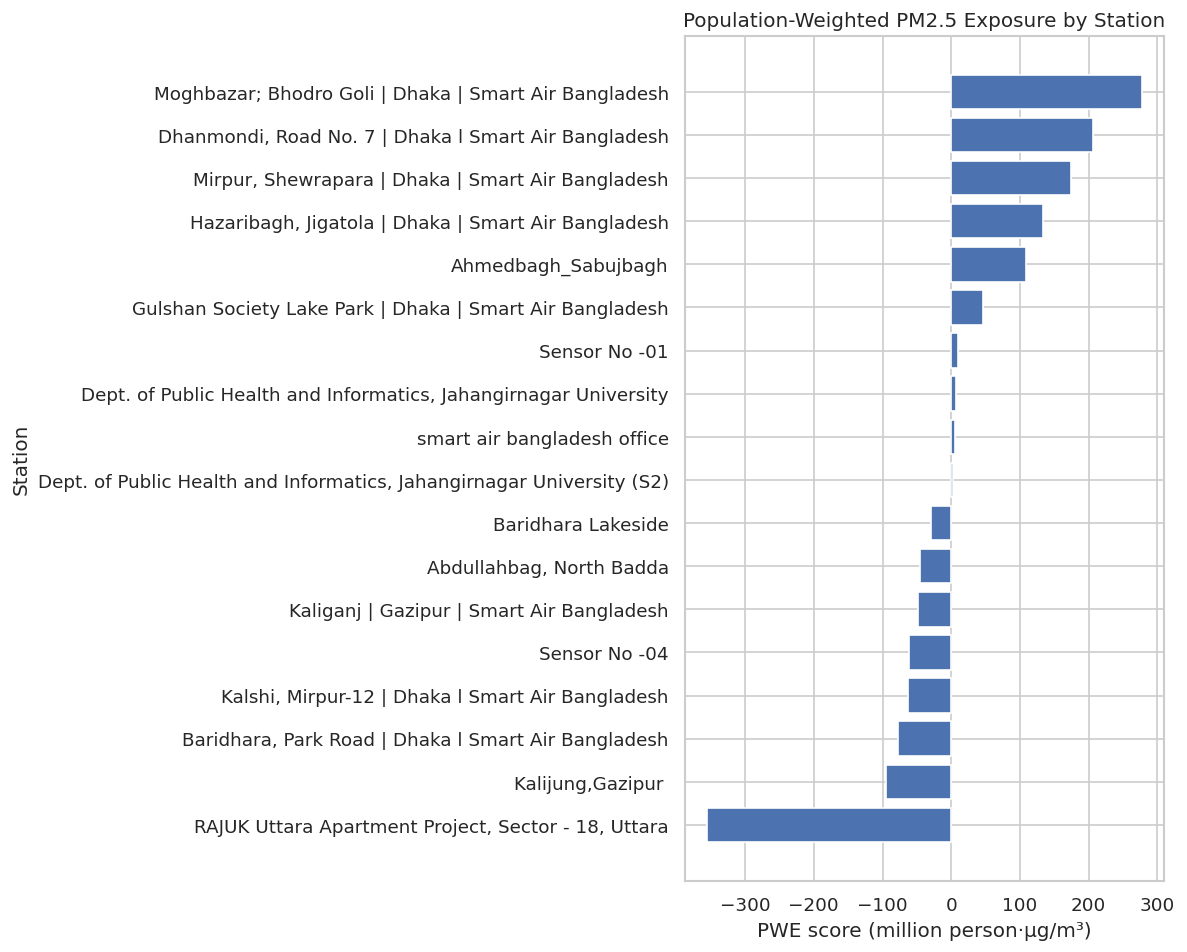

✅ Saved: /kaggle/working/outputs/4_10_population_weighted_exposure.png


In [34]:

# 4.10 Population-weighted exposure ranking
if {"pm25","catchment_pop","name"}.issubset(eda_pd.columns):
    pwe = (
        eda_pd.dropna(subset=["pm25","catchment_pop"])
        .groupby("name", as_index=False)
        .agg(mean_pm25=("pm25","mean"), catchment_pop=("catchment_pop","first"))
    )
    pwe["pwe_score"] = pwe["mean_pm25"] * pwe["catchment_pop"] / 1e6
    pwe = pwe.sort_values("pwe_score", ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(4, len(pwe)*0.45)))
    ax.barh(pwe["name"].astype(str), pwe["pwe_score"])
    ax.set_title("Population-Weighted PM2.5 Exposure by Station")
    ax.set_xlabel("PWE score (million person·µg/m³)"); ax.set_ylabel("Station")
    save_show(fig, "4_10_population_weighted_exposure.png")


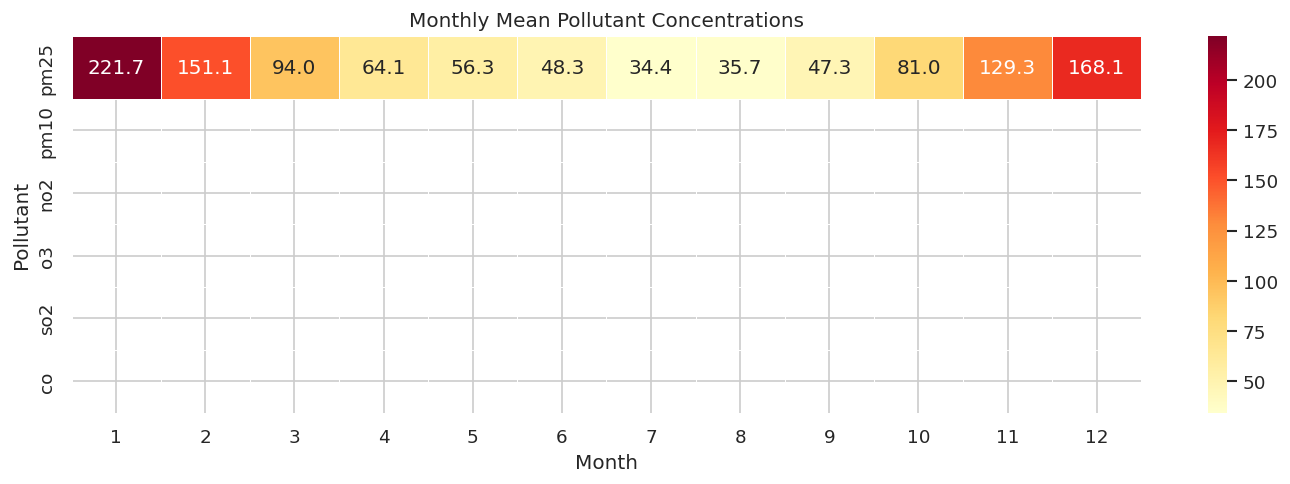

✅ Saved: /kaggle/working/outputs/4_11_monthly_pollutant_heatmap.png


In [35]:

# 4.11 Monthly pollutant heatmap
available_pollutants = [p for p in ["pm25","pm10","no2","o3","so2","co"] if p in eda_pd.columns]
if available_pollutants and "month" in eda_pd.columns:
    monthly = eda_pd.groupby("month")[available_pollutants].mean().T
    fig, ax = plt.subplots(figsize=(12, max(4, len(available_pollutants)*0.7)))
    sns.heatmap(monthly, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.4, ax=ax)
    ax.set_title("Monthly Mean Pollutant Concentrations")
    ax.set_xlabel("Month"); ax.set_ylabel("Pollutant")
    save_show(fig, "4_11_monthly_pollutant_heatmap.png")


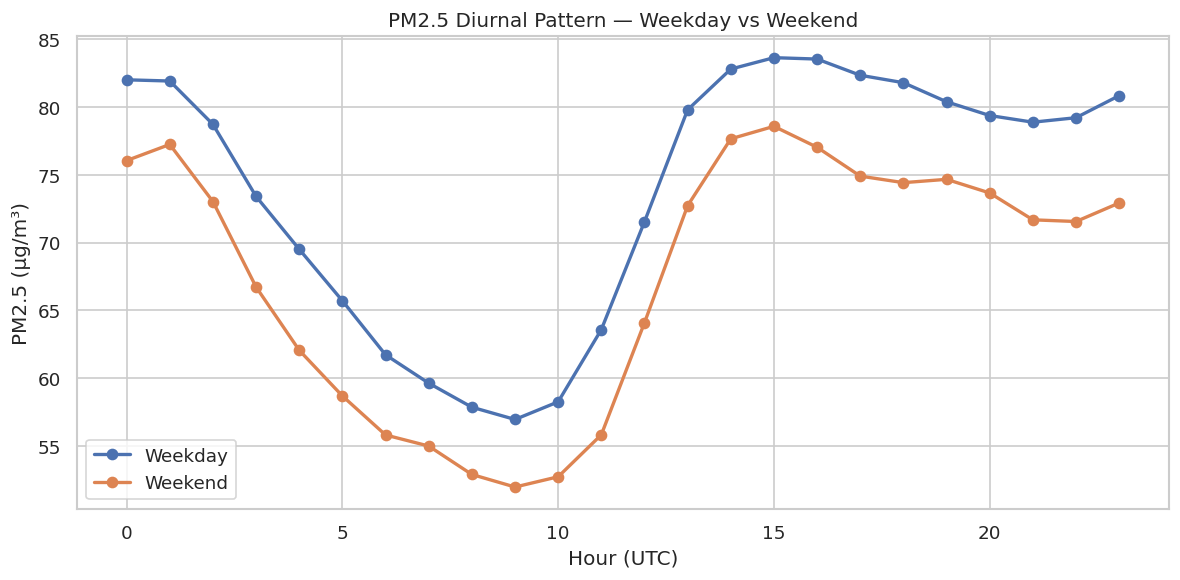

✅ Saved: /kaggle/working/outputs/4_12_weekday_weekend_pm25.png


In [36]:

# 4.12 Weekday vs weekend PM2.5
if {"pm25","dow"}.issubset(eda_pd.columns):
    d = eda_pd.dropna(subset=["pm25","dow"]).copy()
    d["day_type"] = np.where(d["dow"].isin([1,7]), "Weekend", "Weekday")
    pattern = d.groupby(["hour","day_type"])["pm25"].mean().reset_index()
    fig, ax = plt.subplots(figsize=(10, 5))
    for label, g in pattern.groupby("day_type"):
        ax.plot(g["hour"], g["pm25"], marker="o", linewidth=2, label=label)
    ax.set_title("PM2.5 Diurnal Pattern — Weekday vs Weekend")
    ax.set_xlabel("Hour (UTC)"); ax.set_ylabel("PM2.5 (µg/m³)")
    ax.legend()
    save_show(fig, "4_12_weekday_weekend_pm25.png")


## 5. Source-signature analysis

Rule-based temporal and pollutant signatures are treated as **indicative fingerprints**, not certified source apportionment.

In [37]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5.1 – Define source-signature rules and compute scores via Spark SQL
# ─────────────────────────────────────────────────────────────────────────────

# Register enriched DF as temp view for Spark SQL
enriched_sdf.createOrReplaceTempView("aq")

source_scored_sdf = spark.sql("""
SELECT *,

  -- ── TRAFFIC SIGNATURE ──────────────────────────────────────────────────
  -- Peak hours 08-10 and 17-20 on weekdays (dow 2-6 = Mon-Fri in PySpark)
  CASE
    WHEN (hour BETWEEN 8 AND 10 OR hour BETWEEN 17 AND 20)
         AND dow BETWEEN 2 AND 6
         AND no2  IS NOT NULL AND no2  > 30
         AND pm10 IS NOT NULL AND pm10 > 60
    THEN LEAST(1.0,
           0.30 * LEAST((no2  / 80.0), 1.0) +
           0.25 * LEAST((pm10 / 120.0), 1.0) +
           0.25 * (CASE WHEN hour BETWEEN 8 AND 10 OR hour BETWEEN 17 AND 20
                        THEN 1.0 ELSE 0.0 END) +
           0.20 * (CASE WHEN dow BETWEEN 2 AND 6 THEN 1.0 ELSE 0.5 END))
    ELSE
      CASE WHEN (hour BETWEEN 8 AND 10 OR hour BETWEEN 17 AND 20) AND dow BETWEEN 2 AND 6
           THEN 0.3
           ELSE 0.0 END
  END AS score_traffic,

  -- ── BRICK KILN SIGNATURE ───────────────────────────────────────────────
  -- Dry season Nov-Apr (months 11,12,1,2,3,4), morning 06-12
  CASE
    WHEN month IN (11, 12, 1, 2, 3, 4)
         AND hour BETWEEN 6 AND 12
         AND so2  IS NOT NULL AND so2  > 15
         AND pm10 IS NOT NULL AND pm10 > 80
    THEN LEAST(1.0,
           0.35 * LEAST((so2  / 50.0),  1.0) +
           0.30 * LEAST((pm10 / 150.0), 1.0) +
           0.20 * (CASE WHEN month IN (12,1,2) THEN 1.0
                        WHEN month IN (11,3)   THEN 0.7
                        ELSE 0.4 END) +
           0.15 * (CASE WHEN hour BETWEEN 7 AND 11 THEN 1.0 ELSE 0.5 END))
    ELSE
      CASE WHEN month IN (11,12,1,2,3,4) AND hour BETWEEN 6 AND 12
           THEN 0.2
           ELSE 0.0 END
  END AS score_brick_kiln,

  -- ── BIOMASS BURNING SIGNATURE ─────────────────────────────────────────
  -- Post-monsoon Oct-Nov, evening 17-22, CO and PM2.5 elevated
  CASE
    WHEN month IN (10, 11)
         AND hour BETWEEN 17 AND 22
         AND co   IS NOT NULL AND co   > 1.0
         AND pm25 IS NOT NULL AND pm25 > 50
    THEN LEAST(1.0,
           0.40 * LEAST((co   / 5.0),   1.0) +
           0.35 * LEAST((pm25 / 120.0), 1.0) +
           0.25 * (CASE WHEN month = 11 THEN 1.0 ELSE 0.7 END))
    ELSE
      CASE WHEN month IN (10,11) AND hour BETWEEN 17 AND 22
           THEN 0.15
           ELSE 0.0 END
  END AS score_biomass,

  -- ── CONSTRUCTION DUST SIGNATURE ───────────────────────────────────────
  -- High PM10/PM2.5 ratio during daytime, all year
  CASE
    WHEN pm25 IS NOT NULL AND pm25 > 5
         AND pm10 IS NOT NULL
         AND (pm10 / NULLIF(pm25, 0)) > 2.5
         AND hour BETWEEN 7 AND 18
    THEN LEAST(1.0,
           0.50 * LEAST(((pm10 / NULLIF(pm25, 0)) - 2.5) / 4.5, 1.0) +
           0.30 * LEAST((pm10 / 200.0), 1.0) +
           0.20 * (CASE WHEN hour BETWEEN 9 AND 16 THEN 1.0 ELSE 0.5 END))
    ELSE
      CASE WHEN pm10 IS NOT NULL AND pm25 IS NOT NULL AND pm25 > 0
                AND (pm10 / pm25) > 2.5
           THEN 0.10
           ELSE 0.0 END
  END AS score_construction

FROM aq
""")

source_scored_sdf.cache()
print(f"✅ Source-signature scores computed: {source_scored_sdf.count():,} rows")
source_scored_sdf.select(
    "name", "ts", "season", "hour",
    "score_traffic", "score_brick_kiln", "score_biomass", "score_construction"
).orderBy(F.desc("score_traffic")).show(5, truncate=False)


✅ Source-signature scores computed: 47,380 rows
+----------------------------------------------------------------+-------------------+------------+----+-------------+----------------+-------------+------------------+
|name                                                            |ts                 |season      |hour|score_traffic|score_brick_kiln|score_biomass|score_construction|
+----------------------------------------------------------------+-------------------+------------+----+-------------+----------------+-------------+------------------+
|Kalshi, Mirpur-12 | Dhaka l Smart Air Bangladesh                |2026-02-19 09:00:00|Winter      |9   |0.3          |0.2             |0.0          |0.0               |
|Kaliganj | Gazipur | Smart Air Bangladesh                       |2026-02-13 20:00:00|Winter      |20  |0.3          |0.0             |0.0          |0.0               |
|smart air bangladesh office                                     |2025-10-16 09:00:00|Post-Monsoon|9   |0.3

In [38]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5.2 – Aggregate source scores by station × season
# ─────────────────────────────────────────────────────────────────────────────

SOURCES = ["score_traffic", "score_brick_kiln", "score_biomass", "score_construction"]
SOURCE_LABELS = {
    "score_traffic":      "Traffic",
    "score_brick_kiln":   "Brick Kilns",
    "score_biomass":      "Biomass Burning",
    "score_construction": "Construction Dust",
}
SEASON_ORDER = ["Winter", "Pre-Monsoon", "Monsoon", "Post-Monsoon"]

source_season_sdf = (
    source_scored_sdf
    .groupBy("name", "season")
    .agg(
        F.mean("score_traffic").alias("score_traffic"),
        F.mean("score_brick_kiln").alias("score_brick_kiln"),
        F.mean("score_biomass").alias("score_biomass"),
        F.mean("score_construction").alias("score_construction"),
        F.count("*").alias("n_readings"),
    )
    .orderBy("name", "season")
)

source_season_pd = source_season_sdf.toPandas()
source_season_pd.to_csv(str(OUTPUT_DIR / "5_source_scores_by_station_season.csv"), index=False)
print("✅ Source scores aggregated.")
print(source_season_pd.to_string(index=False))


✅ Source scores aggregated.
                                                                 name       season  score_traffic  score_brick_kiln  score_biomass  score_construction  n_readings
                                             Abdullahbag, North Badda       Winter       0.150000          0.200000       0.000000                 0.0           6
                                                  Ahmedbagh_Sabujbagh      Monsoon       0.075000          0.000000       0.000000                 0.0          44
                                                  Ahmedbagh_Sabujbagh  Pre-Monsoon       0.000000          0.200000       0.000000                 0.0           4
                                                   Baridhara Lakeside      Monsoon       0.064823          0.000000       0.000000                 0.0        2152
                                                   Baridhara Lakeside  Pre-Monsoon       0.061728          0.038032       0.000000                 0.0       

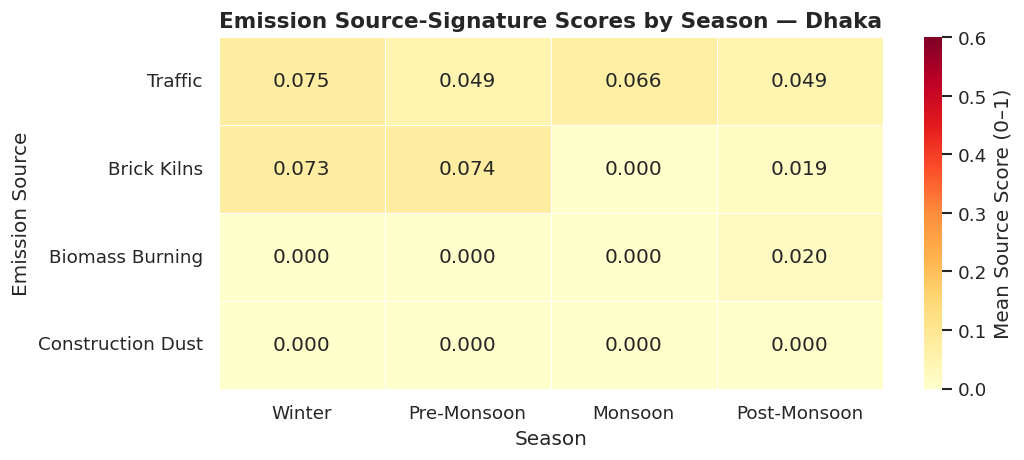

✅ Plot 5.1 saved


In [39]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5.3 – Source signature heatmap: source × season
# ─────────────────────────────────────────────────────────────────────────────

season_source = (
    source_season_pd
    .groupby("season")[SOURCES]
    .mean()
    .reindex(SEASON_ORDER)
    .rename(columns=SOURCE_LABELS)
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    season_source.T,
    annot=True, fmt=".3f",
    cmap="YlOrRd", vmin=0, vmax=0.6,
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "Mean Source Score (0–1)"},
)
ax.set_title("Emission Source-Signature Scores by Season — Dhaka",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Season")
ax.set_ylabel("Emission Source")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "5_1_source_signature_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()
print("✅ Plot 5.1 saved")


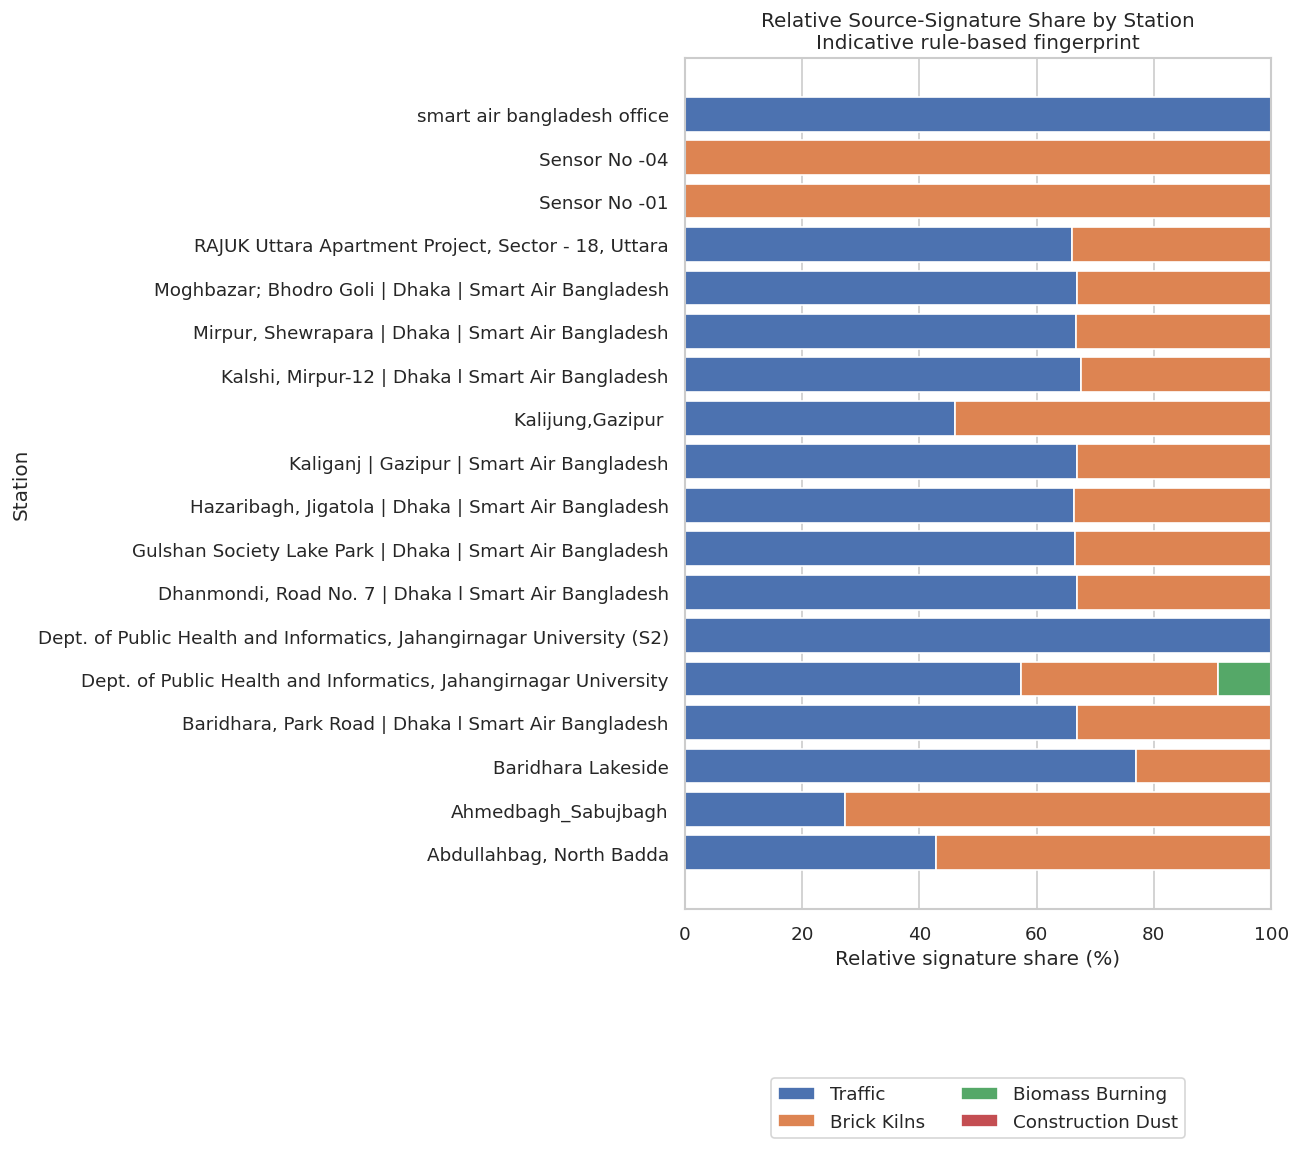

✅ Saved: /kaggle/working/outputs/5_2_source_contribution_by_station.png


In [40]:

# 5.4 Relative source-signature share by station — static PNG
station_source = (
    source_season_pd.groupby("name")[SOURCES]
    .mean().reset_index().rename(columns=SOURCE_LABELS)
)
score_cols = list(SOURCE_LABELS.values())
row_sums = station_source[score_cols].sum(axis=1).replace(0, 1)
station_source_norm = station_source.copy()
station_source_norm[score_cols] = station_source[score_cols].div(row_sums, axis=0) * 100

if not station_source_norm.empty:
    plot_long = station_source_norm.set_index("name")[score_cols]
    fig, ax = plt.subplots(figsize=(11, max(4, len(plot_long) * 0.55)))
    left = np.zeros(len(plot_long))
    for col in score_cols:
        ax.barh(plot_long.index.astype(str), plot_long[col].values, left=left, label=col)
        left += plot_long[col].values
    ax.set_xlim(0, 100)
    ax.set_xlabel("Relative signature share (%)")
    ax.set_ylabel("Station")
    ax.set_title("Relative Source-Signature Share by Station\nIndicative rule-based fingerprint")
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.28), ncol=2)
    save_show(fig, "5_2_source_contribution_by_station.png")

station_source.to_csv(OUTPUT_DIR / "5_source_signature_station_summary.csv", index=False)


## 6. Health-burden estimation

The master notebook's important distinction is preserved:

- **Short-term:** daily PM10 CRF.
- **Long-term/annual:** annual PM2.5 CRFs.
- These estimates answer different questions and **must not be summed**.

In [41]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6.1 – Health burden estimation: SEPARATE short-term vs long-term CRFs
#
# SHORT-TERM CRF (Orellano 2020):  must run on DAILY means and the WHO 24-h
#   guideline baseline — NOT annual means. Applied to PM10.
# LONG-TERM / ANNUAL CRFs (Pope, India D-in-D): valid on annual means. PM2.5.
#
# These two answer DIFFERENT questions and must never be mixed or summed.
# ─────────────────────────────────────────────────────────────────────────────
import math as _math

# ── LONG-TERM / ANNUAL CRFs (applied to annual station means) ────────────────
CRF_ANNUAL = {
    "pm25_long_term": {"pollutant": "pm25", "beta": 0.008,  "label": "PM2.5 Long-Term (Pope et al.)"},
    "pm25_annual"   : {"pollutant": "pm25", "beta": 0.0086, "label": "PM2.5 Annual (India D-in-D 2024)"},
}
WHO_ANNUAL      = {"pm25": 5.0, "pm10": 15.0}   # WHO annual guideline baselines (µg/m³)
DHAKA_POPULATION = 10_356_500                     # BBS 2022 estimate
MORTALITY_RATE   = 6.1 / 1000                     # Bangladesh (World Bank 2022)

# Annual means per station
station_annual = (
    enriched_sdf
    .groupBy("location_id", "name", "lat", "lon")
    .agg(
        F.mean("pm25").alias("mean_pm25"),
        F.mean("pm10").alias("mean_pm10"),
        F.first("catchment_pop").alias("catchment_pop"),
    )
).toPandas()

long_term_results = []
for _, row in station_annual.iterrows():
    for crf_key, crf in CRF_ANNUAL.items():
        pol     = crf["pollutant"]
        beta    = crf["beta"]
        conc    = row.get(f"mean_{pol}")
        if conc is None or (isinstance(conc, float) and _math.isnan(conc)):
            continue
        baseline    = WHO_ANNUAL.get(pol, 0.0)
        delta_c     = max(conc - baseline, 0.0)
        ar_pct      = (1 - _math.exp(-beta * delta_c)) * 100
        catchment   = float(row["catchment_pop"]) if row["catchment_pop"] else DHAKA_POPULATION / 6
        attrib_deaths = catchment * MORTALITY_RATE * ar_pct / 100
        long_term_results.append({
            "station"        : row["name"],
            "lat"            : row["lat"],
            "lon"            : row["lon"],
            "crf"            : crf_key,
            "crf_label"      : crf["label"],
            "exposure_window": "Annual",
            "pollutant"      : pol.upper(),
            "mean_conc"      : round(conc, 2),
            "who_baseline"   : baseline,
            "delta_c"        : round(delta_c, 2),
            "ar_pct"         : round(ar_pct, 3),
            "catchment_pop"  : int(catchment),
            "attrib_deaths"  : round(attrib_deaths, 1),
        })

health_df = pd.DataFrame(long_term_results)   # used downstream in Sections 7 ranking

# ── SHORT-TERM CRF (Orellano 2020): applied to DAILY PM10 means ──────────────
CRF_DAILY    = {"pollutant": "pm10", "beta": 0.004, "label": "PM10 Short-Term (Orellano 2020)"}
WHO_DAILY_PM10 = 45.0    # WHO 24-h PM10 guideline — correct baseline for this CRF

if "pm10" in enriched_sdf.columns:
    daily_station_sdf = (
        enriched_sdf
        .filter(F.col("pm10").isNotNull() & F.col("catchment_pop").isNotNull())
        .groupBy("location_id", "name", "date")
        .agg(
            F.mean("pm10").alias("mean_pm10_daily"),
            F.first("catchment_pop").alias("catchment_pop"),
        )
    )
    daily_station_pd = daily_station_sdf.toPandas()
    beta_short = CRF_DAILY["beta"]
    daily_station_pd["delta_c"] = (daily_station_pd["mean_pm10_daily"] - WHO_DAILY_PM10).clip(lower=0)
    daily_station_pd["ar_pct"]  = (1 - np.exp(-beta_short * daily_station_pd["delta_c"])) * 100
    # Excess deaths per day (per station); sum over all days = annual short-term burden
    daily_station_pd["excess_deaths_day"] = (
        daily_station_pd["catchment_pop"] * MORTALITY_RATE / 365 * daily_station_pd["ar_pct"] / 100
    )
    short_term_summary = (
        daily_station_pd.groupby("name")["excess_deaths_day"]
        .sum()
        .rename("annual_excess_deaths_short_term_pm10")
        .reset_index()
        .sort_values("annual_excess_deaths_short_term_pm10", ascending=False)
    )
    short_term_summary.to_csv(OUTPUT_DIR / "health_burden_short_term_pm10.csv", index=False)
else:
    short_term_summary = pd.DataFrame()
    print("⚠️ PM10 not available — short-term CRF skipped.")

health_df.to_csv(OUTPUT_DIR / "health_burden_table.csv", index=False)
print("✅ Health burden tables computed.")
print("\n── LONG-TERM (annual means) ──────────────────────────────────────────")
print(health_df.groupby("crf_label")[["ar_pct","attrib_deaths"]].mean().round(3).to_string())
if not short_term_summary.empty:
    print("\n── SHORT-TERM (daily PM10, Orellano 2020) ────────────────────────────")
    print(short_term_summary.to_string(index=False))
print("\n⚠️  Short-term and long-term burdens answer DIFFERENT questions and must NOT be summed.")


✅ Health burden tables computed.

── LONG-TERM (annual means) ──────────────────────────────────────────
                                  ar_pct  attrib_deaths
crf_label                                              
PM2.5 Annual (India D-in-D 2024)  35.696        514.828
PM2.5 Long-Term (Pope et al.)     33.843        479.400

⚠️  Short-term and long-term burdens answer DIFFERENT questions and must NOT be summed.


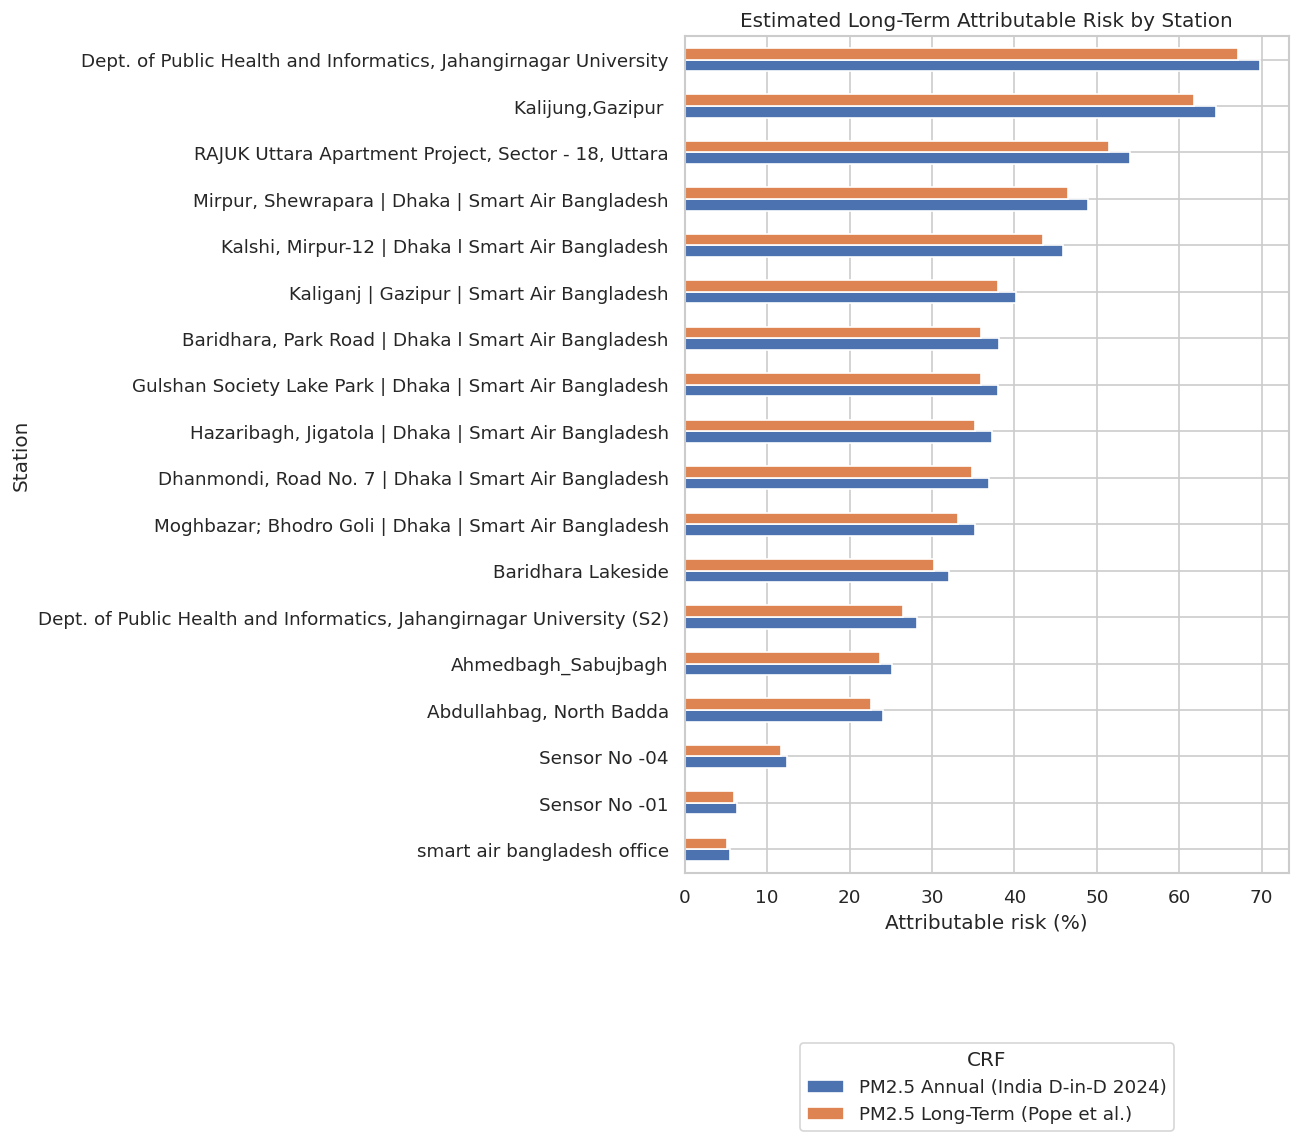

✅ Saved: /kaggle/working/outputs/6_1_health_burden_by_station.png


In [42]:

# 6.2 Long-term attributable risk by station and CRF — static PNG
if not health_df.empty:
    fig, ax = plt.subplots(figsize=(11, max(4, len(health_df["station"].unique()) * 0.55)))
    plot_h = health_df.pivot(index="station", columns="crf_label", values="ar_pct")
    plot_h = plot_h.sort_values(plot_h.columns[0], ascending=True)
    plot_h.plot(kind="barh", ax=ax)
    ax.set_title("Estimated Long-Term Attributable Risk by Station")
    ax.set_xlabel("Attributable risk (%)"); ax.set_ylabel("Station")
    ax.legend(title="CRF", loc="lower center", bbox_to_anchor=(0.5, -0.32), ncol=1)
    save_show(fig, "6_1_health_burden_by_station.png")


      season  mean_pm25  ar_pm25_pct  attrib_deaths_est
      Winter    170.578       75.924          47964.936
 Pre-Monsoon     72.223       43.905          27736.687
     Monsoon     40.467       26.289          16607.874
Post-Monsoon    113.954       60.820          38422.911


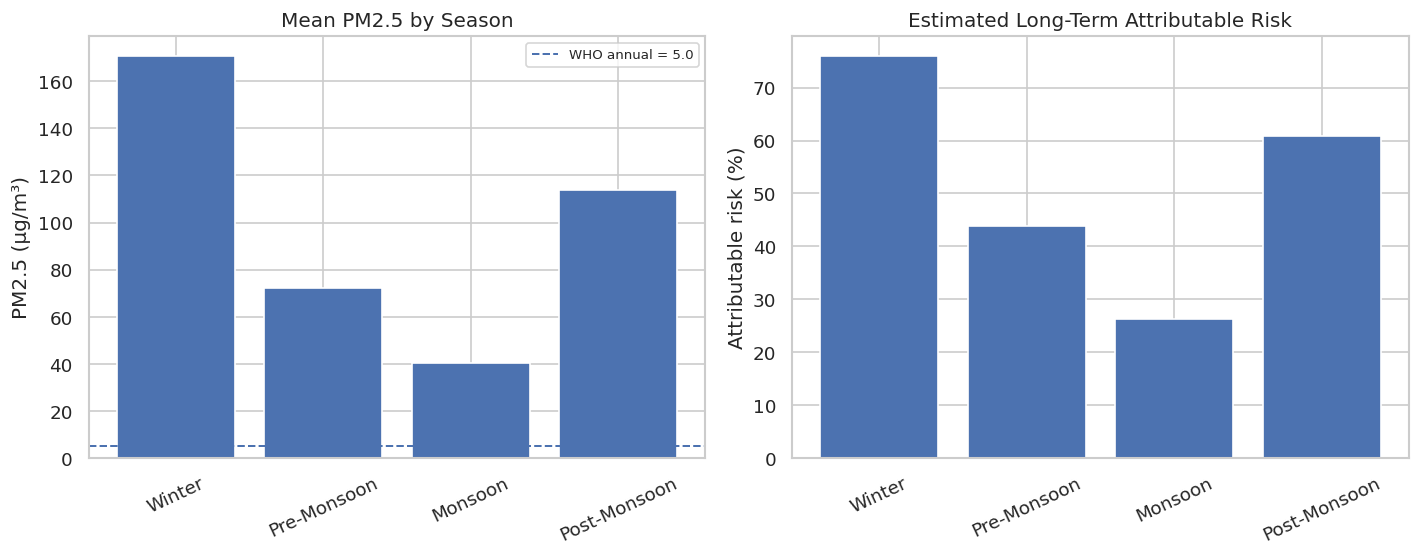

✅ Saved: /kaggle/working/outputs/6_2_seasonal_health_burden.png


In [43]:

# 6.3 Seasonal long-term PM2.5 burden
SEASON_ORDER = ["Winter", "Pre-Monsoon", "Monsoon", "Post-Monsoon"]
beta_annual = CRF_ANNUAL["pm25_annual"]["beta"]
who_pm25 = WHO_ANNUAL["pm25"]

seasonal_conc = (
    enriched_sdf.filter(F.col("pm25").isNotNull())
    .groupBy("season")
    .agg(
        F.mean("pm25").alias("mean_pm25"),
        F.mean("pm10").alias("mean_pm10"),
        F.count("*").alias("n"),
    )
).toPandas()

if not seasonal_conc.empty:
    seasonal_conc["ar_pm25_pct"] = seasonal_conc["mean_pm25"].apply(
        lambda c: (1 - math.exp(-beta_annual * max(float(c) - who_pm25, 0))) * 100
        if pd.notna(c) else np.nan
    )
    seasonal_conc["attrib_deaths_est"] = (
        seasonal_conc["ar_pm25_pct"] / 100 * DHAKA_POPULATION * MORTALITY_RATE
    )
    seasonal_conc["season"] = pd.Categorical(
        seasonal_conc["season"], categories=SEASON_ORDER, ordered=True
    )
    seasonal_conc = seasonal_conc.sort_values("season")
    print(seasonal_conc[["season","mean_pm25","ar_pm25_pct","attrib_deaths_est"]].round(3).to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
    axes[0].bar(seasonal_conc["season"].astype(str), seasonal_conc["mean_pm25"])
    axes[0].axhline(who_pm25, linestyle="--", linewidth=1.2, label=f"WHO annual = {who_pm25}")
    axes[0].set_title("Mean PM2.5 by Season")
    axes[0].set_ylabel("PM2.5 (µg/m³)")
    axes[0].tick_params(axis="x", rotation=25)
    axes[0].legend(fontsize=8)
    axes[1].bar(seasonal_conc["season"].astype(str), seasonal_conc["ar_pm25_pct"])
    axes[1].set_title("Estimated Long-Term Attributable Risk")
    axes[1].set_ylabel("Attributable risk (%)")
    axes[1].tick_params(axis="x", rotation=25)
    save_show(fig, "6_2_seasonal_health_burden.png")
else:
    print("⚠️ Seasonal health burden unavailable.")
if not short_term_summary.empty:
    print("\nShort-term PM10 annualized burden (separate from long-term estimates):")
    print(short_term_summary.to_string(index=False))


## 7. Comparative health-impact ranking

The ranking combines pollution concentration, population exposure, and the selected annual PM2.5 CRF. Station catchments are not treated as mutually exclusive city population blocks.

In [44]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7.1 – Health impact score per station × season
# Includes explicit catchment-population reconciliation check (Phase B2).
# ─────────────────────────────────────────────────────────────────────────────

beta_pm25 = CRF_ANNUAL["pm25_annual"]["beta"]
who_pm25  = WHO_ANNUAL["pm25"]

# ── Population denominator reconciliation ────────────────────────────────────
catchment_sum = pop_lookup["catchment_pop"].sum()
ratio = catchment_sum / DHAKA_POPULATION
print(f"Population reconciliation check:")
print(f"  Sum of station catchments : {catchment_sum:>12,.0f}")
print(f"  City-wide constant        : {DHAKA_POPULATION:>12,.0f}")
print(f"  Ratio                     : {ratio:.2f}×")
if ratio > 1.15:
    print("  ⚠️  Catchments likely overlap — station-level and city-level figures are NOT summable.")
    print("     Use city_weighted_pm25 (below) for city-scale burden; catchment pops for station ranking.")
else:
    print("  ✅ Catchment sum within 15% of city constant — minimal overlap assumed.")

# Population-weighted city mean PM2.5 (more defensible than simple mean for city-level burden)
city_weighted_pm25 = (
    (station_annual["mean_pm25"] * station_annual["catchment_pop"]).sum()
    / station_annual["catchment_pop"].sum()
) if not station_annual.empty else float("nan")
print(f"  City-level pop-weighted PM2.5: {city_weighted_pm25:.2f} µg/m³  "
      f"(used for city-scale burden in Section 6.3; station catchments used for station ranking below)")

# ── Station × season health impact scores ────────────────────────────────────
ranking_sdf = (
    enriched_sdf
    .filter(F.col("pm25").isNotNull() & F.col("catchment_pop").isNotNull())
    .groupBy("name", "season", "lat", "lon")
    .agg(
        F.mean("pm25").alias("mean_pm25"),
        F.mean("pm10").alias("mean_pm10"),
        F.first("catchment_pop").alias("catchment_pop"),
        F.count("*").alias("n"),
    )
)

ranking_pd = ranking_sdf.toPandas()
ranking_pd["delta_c"]            = (ranking_pd["mean_pm25"] - who_pm25).clip(lower=0)
ranking_pd["ar_pct"]             = ranking_pd["delta_c"].apply(
    lambda dc: round((1 - _math.exp(-beta_pm25 * dc)) * 100, 3)
)
ranking_pd["health_impact_score"] = (
    ranking_pd["mean_pm25"] * ranking_pd["catchment_pop"] * beta_pm25 / 1e6
).round(4)
ranking_pd["rank"] = ranking_pd["health_impact_score"].rank(ascending=False, method="min").astype(int)
ranking_pd = ranking_pd.sort_values("health_impact_score", ascending=False).reset_index(drop=True)

ranking_pd.to_csv(OUTPUT_DIR / "health_ranking_summary.csv", index=False)
print("\n✅ Health impact ranking computed.")
print(ranking_pd[["rank","name","season","mean_pm25","ar_pct","catchment_pop","health_impact_score"]].head(15).to_string(index=False))


Population reconciliation check:
  Sum of station catchments :   11,642,752
  City-wide constant        :   10,356,500
  Ratio                     : 1.12×
  ✅ Catchment sum within 15% of city constant — minimal overlap assumed.
  City-level pop-weighted PM2.5: 34.83 µg/m³  (used for city-scale burden in Section 6.3; station catchments used for station ranking below)

✅ Health impact ranking computed.
 rank                                                     name      season  mean_pm25  ar_pct  catchment_pop  health_impact_score
    1    Moghbazar; Bhodro Goli | Dhaka | Smart Air Bangladesh      Winter 111.964246  60.144        5021149               4.8348
    2     Dhanmondi, Road No. 7 | Dhaka l Smart Air Bangladesh      Winter 127.234510  65.049        3512325               3.8432
    3        Mirpur, Shewrapara | Dhaka | Smart Air Bangladesh      Winter 165.007018  74.743        2092068               2.9688
    4    Moghbazar; Bhodro Goli | Dhaka | Smart Air Bangladesh Pre-Monsoon  

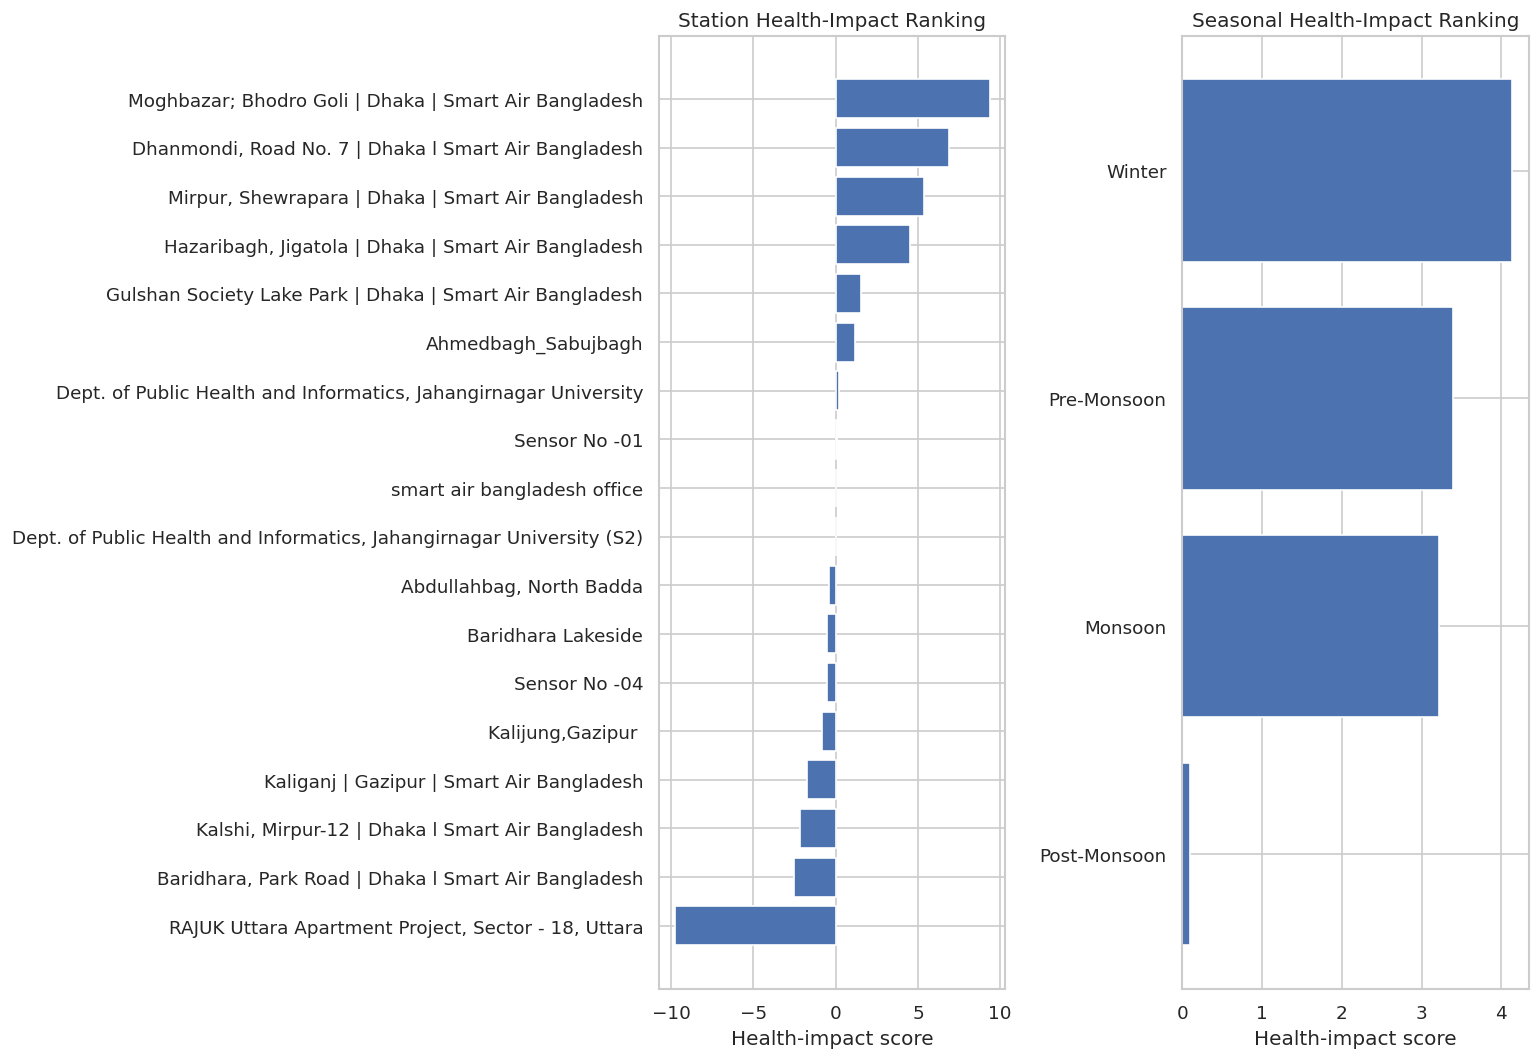

✅ Saved: /kaggle/working/outputs/7_1_health_impact_ranking.png


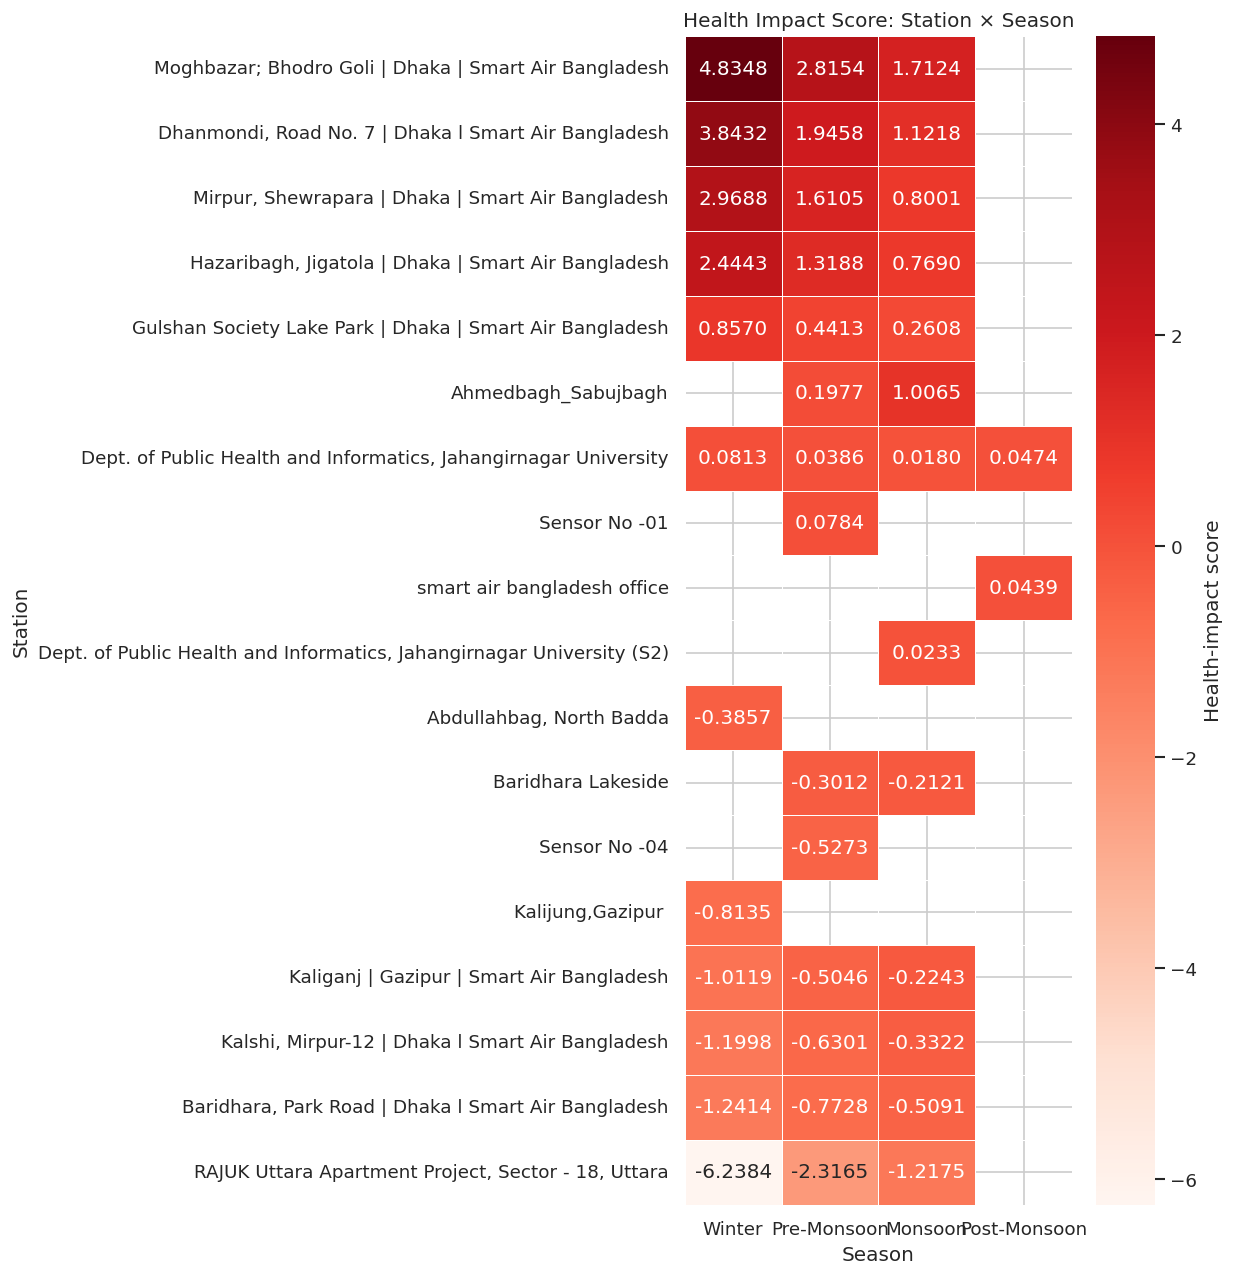

✅ Saved: /kaggle/working/outputs/7_2_health_burden_heatgrid.png

Top 10 station-season combinations:
 rank                                                  name      season  mean_pm25  ar_pct  health_impact_score
    1 Moghbazar; Bhodro Goli | Dhaka | Smart Air Bangladesh      Winter 111.964246  60.144               4.8348
    2  Dhanmondi, Road No. 7 | Dhaka l Smart Air Bangladesh      Winter 127.234510  65.049               3.8432
    3     Mirpur, Shewrapara | Dhaka | Smart Air Bangladesh      Winter 165.007018  74.743               2.9688
    4 Moghbazar; Bhodro Goli | Dhaka | Smart Air Bangladesh Pre-Monsoon  65.198199  40.411               2.8154
    5   Hazaribagh, Jigatola | Dhaka | Smart Air Bangladesh      Winter 126.126060  64.714               2.4443
    6  Dhanmondi, Road No. 7 | Dhaka l Smart Air Bangladesh Pre-Monsoon  64.417001  40.010               1.9458
    7 Moghbazar; Bhodro Goli | Dhaka | Smart Air Bangladesh     Monsoon  39.656446  25.773               1.7124
   

In [45]:

# 7.2 Health-impact ranking — static PNG
station_rank = (
    ranking_pd.groupby("name")
    .agg(mean_pm25=("mean_pm25","mean"), ar_pct=("ar_pct","mean"),
         health_score=("health_impact_score","sum"), catchment_pop=("catchment_pop","first"))
    .reset_index().sort_values("health_score", ascending=True)
)
season_rank = (
    ranking_pd.groupby("season")
    .agg(mean_pm25=("mean_pm25","mean"), ar_pct=("ar_pct","mean"),
         health_score=("health_impact_score","sum"))
    .reset_index().sort_values("health_score", ascending=True)
)
fig, axes = plt.subplots(1, 2, figsize=(13, max(4.5, len(station_rank)*0.5)))
axes[0].barh(station_rank["name"].astype(str), station_rank["health_score"])
axes[0].set_title("Station Health-Impact Ranking")
axes[0].set_xlabel("Health-impact score")
axes[1].barh(season_rank["season"].astype(str), season_rank["health_score"])
axes[1].set_title("Seasonal Health-Impact Ranking")
axes[1].set_xlabel("Health-impact score")
save_show(fig, "7_1_health_impact_ranking.png")

pivot_hm = ranking_pd.pivot_table(index="name", columns="season",
                                  values="health_impact_score", aggfunc="mean")
pivot_hm = pivot_hm.reindex(columns=[s for s in SEASON_ORDER if s in pivot_hm.columns])
pivot_hm = pivot_hm.loc[pivot_hm.sum(axis=1).sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(10, max(4, len(pivot_hm)*0.6)))
sns.heatmap(pivot_hm, annot=True, fmt=".4f", cmap="Reds", linewidths=0.4, ax=ax,
            cbar_kws={"label":"Health-impact score"})
ax.set_title("Health Impact Score: Station × Season")
ax.set_xlabel("Season"); ax.set_ylabel("Station")
save_show(fig, "7_2_health_burden_heatgrid.png")
print("\nTop 10 station-season combinations:")
print(ranking_pd.nlargest(10, "health_impact_score")
      [["rank","name","season","mean_pm25","ar_pct","health_impact_score"]]
      .to_string(index=False))


## 8. Short-term PM2.5 forecasting

A chronological holdout compares a persistence baseline with Linear Regression,
Random Forest, and Gradient-Boosted Trees (Spark MLlib) — plus **LightGBM** and
**XGBoost**, the modern drop-in upgrades for GBT on tabular lag/rolling/weather
features. The latter two are trained on the same chronological split via
pandas/scikit-learn (the set is already filtered to one station's hourly
history, so it comfortably fits in memory) rather than through Spark, since
neither ships a native Spark MLlib estimator. The model is selected by test
RMSE on the same holdout set, whichever library it came from.


In [46]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8.1 – Feature engineering for PM2.5 forecasting (Spark Window functions)
# ─────────────────────────────────────────────────────────────────────────────

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline

if "pm25" not in enriched_sdf.columns:
    print("⚠️ PM2.5 column not available — skipping Section 8.")
    ml_sdf = None
    gbt_model = None
    test_pd = None
    rmse = mae = r2 = None
    available_feats = []
else:
    # Pick station with most PM2.5 readings for forecasting
    best_station_row = (
        enriched_sdf
        .filter(F.col("pm25").isNotNull())
        .groupBy("location_id", "name")
        .count()
        .orderBy(F.desc("count"))
        .first()
    )
    print(f"📍 Forecasting station: {best_station_row['name']} ({best_station_row['count']:,} readings)")

    w_lag = Window.partitionBy("location_id").orderBy("ts")

    ml_sdf = (
        enriched_sdf
        .filter(
            (F.col("location_id") == best_station_row["location_id"]) &
            F.col("pm25").isNotNull()
        )
        .withColumn("pm25_lag1",   F.lag("pm25", 1).over(w_lag))
        .withColumn("pm25_lag24",  F.lag("pm25", 24).over(w_lag))
        .withColumn("pm25_roll24", F.avg("pm25").over(w_lag.rowsBetween(-23, 0)))
        .withColumn("target",      F.lead("pm25", 1).over(w_lag))
        .withColumn("season_enc",
            F.when(F.col("season") == "Winter",      0)
             .when(F.col("season") == "Pre-Monsoon", 1)
             .when(F.col("season") == "Monsoon",     2)
             .otherwise(3)
        )
    )

    FEATURE_COLS = [
        "pm25_lag1", "pm25_lag24", "pm25_roll24",
        "hour", "dow", "month", "season_enc",
        "temp_c", "rh_pct", "wind_speed_kmh", "blh_m",
    ]
    available_feats = [c for c in FEATURE_COLS if c in ml_sdf.columns]

    ml_sdf = ml_sdf.select(["ts", "target"] + available_feats).dropna()
    total_rows = ml_sdf.count()
    print(f"✅ ML dataset: {total_rows:,} rows  |  {len(available_feats)} features: {available_feats}")


📍 Forecasting station: RAJUK Uttara Apartment Project, Sector - 18, Uttara (6,630 readings)
✅ ML dataset: 6,605 rows  |  11 features: ['pm25_lag1', 'pm25_lag24', 'pm25_roll24', 'hour', 'dow', 'month', 'season_enc', 'temp_c', 'rh_pct', 'wind_speed_kmh', 'blh_m']


In [47]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8.2a – Reusable model comparison harness (Phase D1)
# Every model decision in this project runs through this function.
# Candidates: Persistence baseline + LinearRegression + RandomForest + GBT
#             (native Spark MLlib), plus LightGBM + XGBoost (pandas/sklearn —
#             the forecasting set is already filtered to one station's hourly
#             history, so it fits comfortably in memory; neither library ships
#             a native Spark MLlib estimator, so this is the practical way to
#             drop them in without pulling in SynapseML / xgboost4j-spark).
# Results saved to outputs/model_comparison.csv; winner logged explicitly.
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
from pyspark.ml.regression import GBTRegressor, RandomForestRegressor, LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler as _VA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

try:
    from lightgbm import LGBMRegressor
    HAVE_LIGHTGBM = True
except ImportError:
    HAVE_LIGHTGBM = False
    print("⚠️ lightgbm not installed — skipping that candidate (pip install lightgbm to include it).")

try:
    from xgboost import XGBRegressor
    HAVE_XGBOOST = True
except ImportError:
    HAVE_XGBOOST = False
    print("⚠️ xgboost not installed — skipping that candidate (pip install xgboost to include it).")


def evaluate_regression(preds_sdf, label_col="target", pred_col="prediction"):
    """Return dict of {rmse, mae, r2} for a predictions SDF."""
    return {
        m: RegressionEvaluator(
               labelCol=label_col, predictionCol=pred_col, metricName=m
           ).evaluate(preds_sdf)
        for m in ["rmse", "mae", "r2"]
    }


def evaluate_regression_pd(y_true, y_pred):
    """Same three metrics, computed with sklearn for pandas-trained candidates."""
    return {
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
    }


def train_and_compare_models(
    train_sdf,
    test_sdf,
    feature_cols,
    label_col="target",
    primary_metric="rmse",
    lower_is_better=True,
):
    """
    Train Persistence + LinearRegression + RandomForest + GBT (Spark MLlib),
    plus LightGBM + XGBoost (pandas/sklearn), on the same chronological
    train/test split. Returns the winning fitted model, its kind
    ("spark" or "sklearn"), its name, and the full comparison table.
    Never hand-pick a model in this project without running it through here.
    """
    assembler = _VA(inputCols=feature_cols, outputCol="_features", handleInvalid="skip")

    candidates = {
        "LinearRegression": LinearRegression(
            featuresCol="_features", labelCol=label_col, maxIter=200),
        "RandomForest": RandomForestRegressor(
            featuresCol="_features", labelCol=label_col,
            numTrees=100, maxDepth=8, seed=42),
        "GBT": GBTRegressor(
            featuresCol="_features", labelCol=label_col,
            maxIter=80, maxDepth=5, stepSize=0.1, subsamplingRate=0.8, seed=42),
    }

    results, fitted_models, model_kind = [], {}, {}

    # Naive persistence baseline (predict lag-1 value)
    if "pm25_lag1" in test_sdf.columns:
        pers_preds = test_sdf.withColumn("prediction", F.col("pm25_lag1"))
        m = evaluate_regression(pers_preds, label_col)
        m["model"] = "Persistence (naive)"
        results.append(m)
        print(f"   Persistence (naive): RMSE={m['rmse']:.3f}  MAE={m['mae']:.3f}  R²={m['r2']:.4f}")

    for name, estimator in candidates.items():
        pipeline = Pipeline(stages=[assembler, estimator])
        print(f"🔄 Training {name}...")
        fitted = pipeline.fit(train_sdf)
        preds  = fitted.transform(test_sdf)
        m = evaluate_regression(preds, label_col)
        m["model"] = name
        results.append(m)
        fitted_models[name] = fitted
        model_kind[name] = "spark"
        print(f"   {name}: RMSE={m['rmse']:.3f}  MAE={m['mae']:.3f}  R²={m['r2']:.4f}")

    # ---- Gradient-boosting drop-ins: LightGBM / XGBoost (pandas/sklearn) ----
    # Pull to pandas once, reused by both candidates — this is already a
    # single station's hourly history (thousands, not millions, of rows),
    # so it fits comfortably in driver memory.
    if HAVE_LIGHTGBM or HAVE_XGBOOST:
        train_pdf = train_sdf.select(feature_cols + [label_col]).toPandas()
        test_pdf  = test_sdf.select(feature_cols + [label_col]).toPandas()
        X_train, y_train = train_pdf[feature_cols], train_pdf[label_col]
        X_test,  y_test  = test_pdf[feature_cols],  test_pdf[label_col]

        if HAVE_LIGHTGBM:
            print("🔄 Training LightGBM...")
            lgbm = LGBMRegressor(
                n_estimators=300, max_depth=5, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=-1,
            )
            lgbm.fit(X_train, y_train)
            m = evaluate_regression_pd(y_test, lgbm.predict(X_test))
            m["model"] = "LightGBM"
            results.append(m)
            fitted_models["LightGBM"] = lgbm
            model_kind["LightGBM"] = "sklearn"
            print(f"   LightGBM: RMSE={m['rmse']:.3f}  MAE={m['mae']:.3f}  R²={m['r2']:.4f}")

        if HAVE_XGBOOST:
            print("🔄 Training XGBoost...")
            xgb = XGBRegressor(
                n_estimators=300, max_depth=5, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8, random_state=42,
                tree_method="hist", verbosity=0,
            )
            xgb.fit(X_train, y_train)
            m = evaluate_regression_pd(y_test, xgb.predict(X_test))
            m["model"] = "XGBoost"
            results.append(m)
            fitted_models["XGBoost"] = xgb
            model_kind["XGBoost"] = "sklearn"
            print(f"   XGBoost: RMSE={m['rmse']:.3f}  MAE={m['mae']:.3f}  R²={m['r2']:.4f}")

    results_df = (
        pd.DataFrame(results)[["model", "rmse", "mae", "r2"]]
        .sort_values(primary_metric, ascending=lower_is_better)
        .reset_index(drop=True)
    )
    results_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)

    winner_name = results_df.iloc[0]["model"]
    print(f"\n🏆 Best model by {primary_metric.upper()}: {winner_name}")
    print(results_df.to_string(index=False))
    return (
        fitted_models.get(winner_name),
        model_kind.get(winner_name, "spark"),
        winner_name,
        results_df,
    )

print("✅ Model comparison harness defined (Spark MLlib + LightGBM + XGBoost).")


✅ Model comparison harness defined (Spark MLlib + LightGBM + XGBoost).


In [48]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8.2b – Run comparison harness + select best model (Phase D2)
# Chronological 80/20 split; all candidates evaluated on the SAME test set.
# UPDATE: the winner can now be a Spark MLlib model OR a plain sklearn
#         estimator (LightGBM/XGBoost) — best_model_kind tracks which, and
#         everything downstream (metrics, plotting, feature importance)
#         branches on it instead of assuming Spark.
# ─────────────────────────────────────────────────────────────────────────────

if ml_sdf is None:
    print("⚠️ ML dataset not available — skipping model training.")
    best_model = gbt_model = None
    best_model_name = "N/A"
    best_model_kind = "spark"
    comparison_df = pd.DataFrame()
    test_pd = None
    rmse = mae = r2 = None
else:
    count   = ml_sdf.count()
    train_n = int(count * 0.80)

    w_row = Window.orderBy("ts")
    ml_rn = ml_sdf.withColumn("_rn", F.row_number().over(w_row))
    train_sdf = ml_rn.filter(F.col("_rn") <= train_n).drop("_rn", "ts")
    test_sdf  = ml_rn.filter(F.col("_rn") >  train_n)   # keep ts for plotting

    print(f"✅ Train: {train_sdf.count():,} rows | Test: {test_sdf.count():,} rows")

    best_model, best_model_kind, best_model_name, comparison_df = train_and_compare_models(
        train_sdf,
        test_sdf.drop("ts"),
        available_feats,
        label_col="target",
        primary_metric="rmse",
        lower_is_better=True,
    )

    if best_model is None:
        print("\n⚠️  Naive persistence beat every trained model.")
        print("   Finding: next-hour PM2.5 at this station is dominated by")
        print("   autocorrelation — complex models add little beyond the lag-1")
        print("   value.  This is a legitimate and reportable result.")
        gbt_model = None
        test_pd   = None
        rmse = mae = r2 = None
    else:
        # Build test predictions (with ts, for plotting). Branch on model
        # kind: Spark MLlib models transform a Spark DataFrame; LightGBM/
        # XGBoost are plain sklearn estimators that predict off a pandas one.
        if best_model_kind == "spark":
            test_preds_sdf = best_model.transform(test_sdf).orderBy("ts")

            evaluator_rmse = RegressionEvaluator(labelCol="target", predictionCol="prediction", metricName="rmse")
            evaluator_mae  = RegressionEvaluator(labelCol="target", predictionCol="prediction", metricName="mae")
            evaluator_r2   = RegressionEvaluator(labelCol="target", predictionCol="prediction", metricName="r2")
            rmse = evaluator_rmse.evaluate(test_preds_sdf)
            mae  = evaluator_mae.evaluate(test_preds_sdf)
            r2   = evaluator_r2.evaluate(test_preds_sdf)

            test_pd_full = test_preds_sdf.select("ts", "target", "prediction").toPandas()
        else:
            test_pd_full = test_sdf.orderBy("ts").toPandas()
            preds = best_model.predict(test_pd_full[available_feats])
            test_pd_full["prediction"] = preds
            rmse = float(np.sqrt(mean_squared_error(test_pd_full["target"], preds)))
            mae  = float(mean_absolute_error(test_pd_full["target"], preds))
            r2   = float(r2_score(test_pd_full["target"], preds))
            test_pd_full = test_pd_full[["ts", "target", "prediction"]]

        test_pd_full["ts"] = pd.to_datetime(test_pd_full["ts"], utc=True)

        gbt_model = best_model   # alias for downstream plotting cell

        pd.DataFrame([{
            "model": best_model_name, "rmse": round(rmse, 3),
            "mae": round(mae, 3), "r2": round(r2, 4),
            "n_train": train_n, "n_test": count - train_n,
            "features": str(available_feats),
        }]).to_csv(OUTPUT_DIR / "forecast_metrics.csv", index=False)

        test_pd = test_pd_full.sort_values("ts").head(2000).reset_index(drop=True)


✅ Train: 5,284 rows | Test: 1,321 rows
   Persistence (naive): RMSE=11.579  MAE=7.873  R²=0.3820
🔄 Training LinearRegression...
   LinearRegression: RMSE=11.319  MAE=8.392  R²=0.4094
🔄 Training RandomForest...
   RandomForest: RMSE=10.243  MAE=7.321  R²=0.5164
🔄 Training GBT...
   GBT: RMSE=10.718  MAE=7.737  R²=0.4704
🔄 Training LightGBM...
   LightGBM: RMSE=10.209  MAE=7.178  R²=0.5195
🔄 Training XGBoost...
   XGBoost: RMSE=10.113  MAE=7.118  R²=0.5285

🏆 Best model by RMSE: XGBoost
              model      rmse      mae       r2
            XGBoost 10.113126 7.117854 0.528505
           LightGBM 10.208826 7.177701 0.519540
       RandomForest 10.242508 7.321496 0.516364
                GBT 10.718302 7.736774 0.470388
   LinearRegression 11.318837 8.391890 0.409378
Persistence (naive) 11.578556 7.872521 0.381963


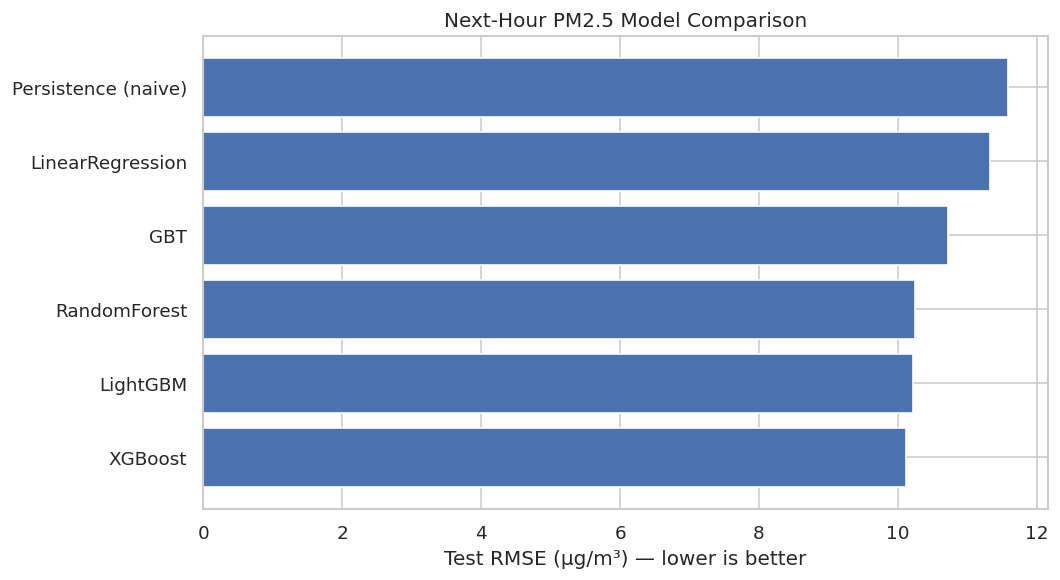

✅ Saved: /kaggle/working/outputs/8_0_model_comparison.png


In [49]:

# 8.2 Model comparison — static PNG
if "comparison_df" in globals() and not comparison_df.empty:
    fig, ax = plt.subplots(figsize=(9, 5))
    plot_cmp = comparison_df.sort_values("rmse", ascending=True)
    ax.barh(plot_cmp["model"], plot_cmp["rmse"])
    ax.set_title("Next-Hour PM2.5 Model Comparison")
    ax.set_xlabel("Test RMSE (µg/m³) — lower is better")
    save_show(fig, "8_0_model_comparison.png")


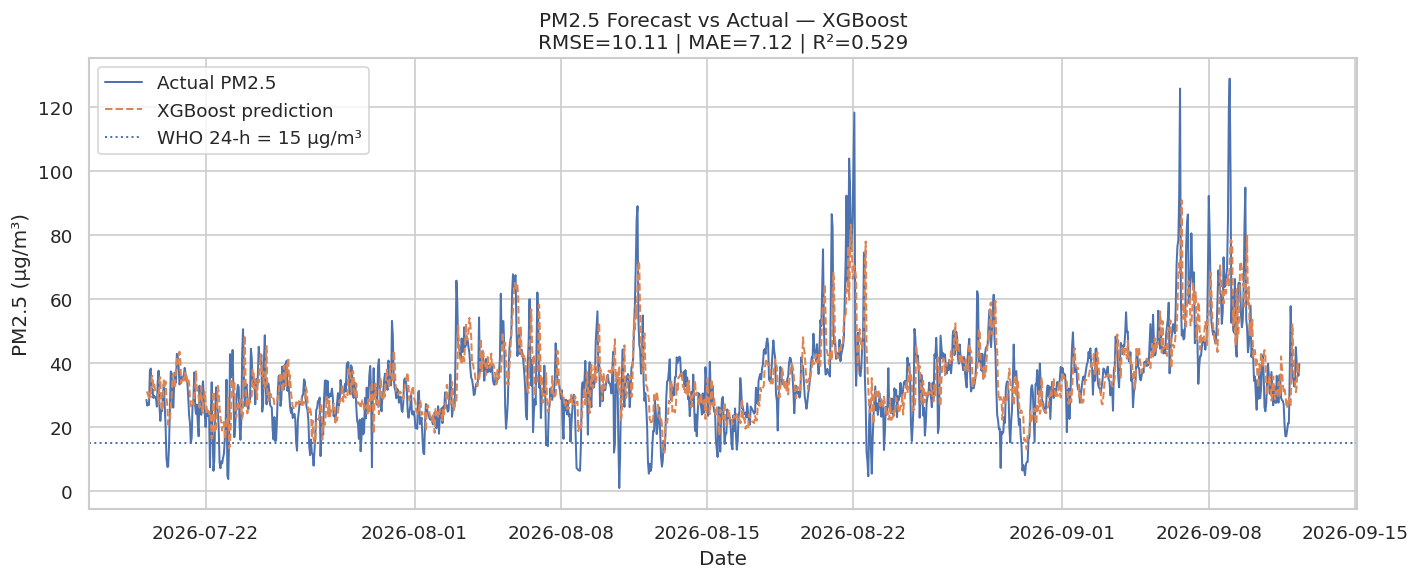

✅ Saved: /kaggle/working/outputs/8_1_forecast_vs_actual.png


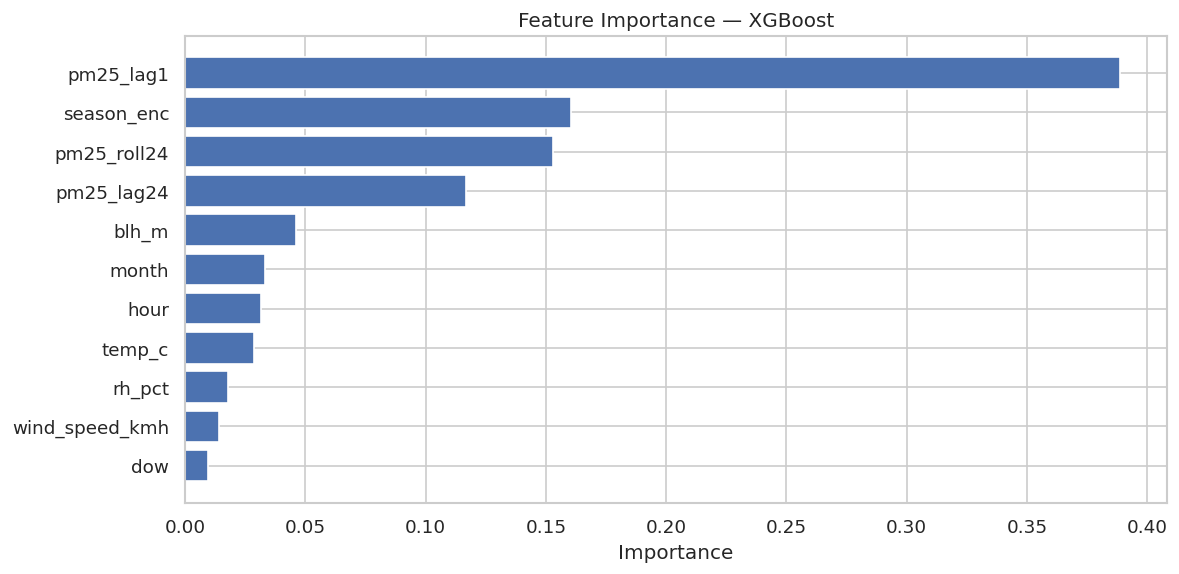

✅ Saved: /kaggle/working/outputs/8_2_feature_importance.png


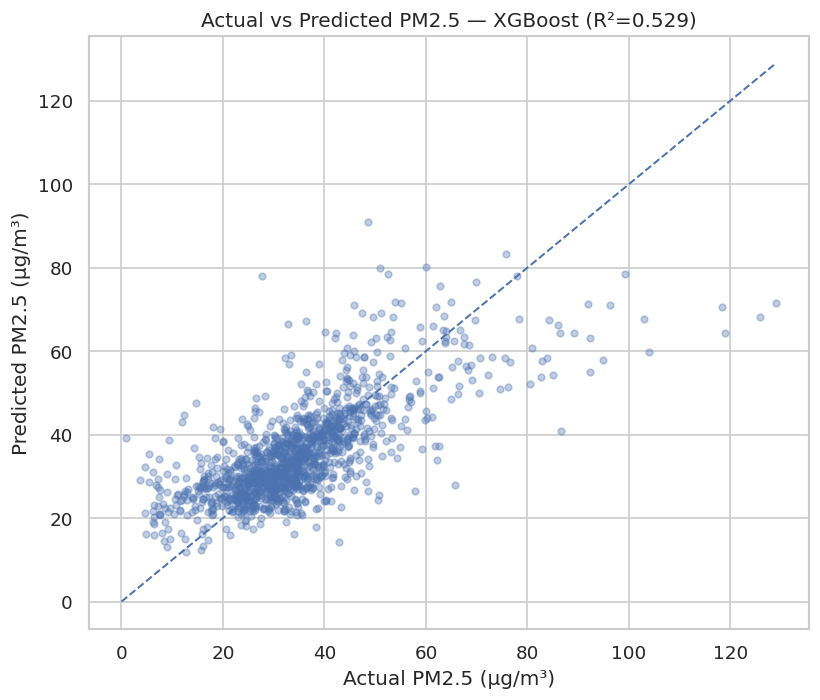

✅ Saved: /kaggle/working/outputs/8_3_actual_vs_predicted.png


In [50]:

# 8.3 Forecast vs actual, feature importance, and actual-vs-predicted
if test_pd is None:
    print(f"⚠️ No fitted forecast model available. Selected result: {best_model_name}")
else:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(test_pd["ts"], test_pd["target"], linewidth=1.2, label="Actual PM2.5")
    ax.plot(test_pd["ts"], test_pd["prediction"], linewidth=1.2, linestyle="--",
            label=f"{best_model_name} prediction")
    ax.axhline(WHO_GUIDELINES["pm25"], linestyle=":", linewidth=1.2,
               label=f"WHO 24-h = {WHO_GUIDELINES['pm25']} µg/m³")
    ax.set_title(f"PM2.5 Forecast vs Actual — {best_model_name}\nRMSE={rmse:.2f} | MAE={mae:.2f} | R²={r2:.3f}")
    ax.set_xlabel("Date"); ax.set_ylabel("PM2.5 (µg/m³)")
    ax.legend()
    save_show(fig, "8_1_forecast_vs_actual.png")

    # Feature importance — Spark MLlib models expose it on the final
    # pipeline stage; LightGBM/XGBoost (sklearn API) expose it directly
    # on the fitted estimator as `.feature_importances_`.
    importances = None
    if best_model_kind == "spark":
        stage = gbt_model.stages[-1]
        if hasattr(stage, "featureImportances"):
            importances = stage.featureImportances.toArray()
    else:
        importances = getattr(gbt_model, "feature_importances_", None)

    if importances is not None:
        feat_imp_df = pd.DataFrame({"feature": available_feats, "importance": importances})
        feat_imp_df = feat_imp_df.sort_values("importance", ascending=True)
        fig, ax = plt.subplots(figsize=(10, max(4, len(feat_imp_df)*0.45)))
        ax.barh(feat_imp_df["feature"], feat_imp_df["importance"])
        ax.set_title(f"Feature Importance — {best_model_name}")
        ax.set_xlabel("Importance")
        save_show(fig, "8_2_feature_importance.png")

    sample = test_pd.sample(min(3000, len(test_pd)), random_state=42)
    max_val = float(max(sample["target"].max(), sample["prediction"].max()))
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(sample["target"], sample["prediction"], alpha=0.35, s=16)
    ax.plot([0, max_val], [0, max_val], linestyle="--", linewidth=1.2)
    ax.set_title(f"Actual vs Predicted PM2.5 — {best_model_name} (R²={r2:.3f})")
    ax.set_xlabel("Actual PM2.5 (µg/m³)")
    ax.set_ylabel("Predicted PM2.5 (µg/m³)")
    save_show(fig, "8_3_actual_vs_predicted.png")


## 9. Final project summary

The notebook is complete when the cells above finish successfully. The `outputs/` directory contains CSV summaries, Parquet data products, and **PNG-only visualizations**.

In [52]:

print("=" * 72)
print(" DHAKA AIR POLLUTION — CLEAN NOTEBOOK COMPLETE ")
print("=" * 72)


output_files = sorted(OUTPUT_DIR.glob("*"))
print(f"\n📁 Output files: {len(output_files)}")
for f in output_files:
    print(f"   {f.name:<55} {os.path.getsize(f)/1024:>9.1f} KB")

if "eda_pd" in globals() and not eda_pd.empty:
    print("\n📊 EDA summary")
    print(f"   Rows       : {len(eda_pd):,}")
    print(f"   Stations   : {eda_pd['name'].nunique() if 'name' in eda_pd.columns else 'N/A'}")
    print(f"   Date range : {eda_pd['date'].min()} → {eda_pd['date'].max()}")
    if "pm25" in eda_pd.columns:
        print(f"   PM2.5 mean : {eda_pd['pm25'].mean():.2f} µg/m³")
        print(f"   PM2.5 max  : {eda_pd['pm25'].max():.2f} µg/m³")

print("\n🔎 Provenance")
print(f"   Weather     : {'SYNTHETIC fallback' if IS_SYNTHETIC_WEATHER else 'Open-Meteo'}")
print(f"   Population  : {'area-lookup fallback' if IS_SYNTHETIC_POPULATION else 'WorldPop raster'}")
print("   Visuals     : PNG only")
print("   HTML output : none")
print("=" * 72)


 DHAKA AIR POLLUTION — CLEAN NOTEBOOK COMPLETE 

📁 Output files: 30
   4_10_population_weighted_exposure.png                       231.8 KB
   4_11_monthly_pollutant_heatmap.png                           66.9 KB
   4_12_weekday_weekend_pm25.png                               116.5 KB
   4_1_pm25_temporal_trend.png                                 317.3 KB
   4_2_diurnal_pm25.png                                         74.2 KB
   4_3_seasonal_pm25_boxplot.png                                65.9 KB
   4_4_correlation_heatmap.png                                 198.3 KB
   4_5_station_pm25_vs_who.png                                 231.0 KB
   4_6_wind_direction_pm25.png                                 208.2 KB
   4_7_who_exceedance_calendar.png                              61.3 KB
   4_8_blh_vs_pm25.png                                         620.8 KB
   5_1_source_signature_heatmap.png                             91.5 KB
   5_2_source_contribution_by_station.png                      253.7

In [64]:
import pandas as pd
import numpy as np
import requests
from datetime import datetime, timedelta

# --- CONFIGURATION ---
# Automatically grab today's date and the current hour
target_date = datetime.now().replace(minute=0, second=0, microsecond=0)
DHAKA_LAT, DHAKA_LON = 23.8103, 90.4125

print(f"--- LIVE PREDICTION DEMONSTRATION FOR {target_date} ---")

# ==========================================
# STEP 0: Interactive Sensor Selection
# ==========================================
print("\n🔍 Checking for active PM2.5 sensors in Dhaka...")
active_sensors_list = []

try:
    for _, row in stations_df.iterrows():
        sid = row.get("location_id") or row.get("Station ID")
        name = row.get("name") or row.get("Station Name", "Unknown Station")
        
        r = requests.get(f"https://api.openaq.org/v3/locations/{sid}/sensors", headers=headers, timeout=10)
        if r.status_code == 200:
            
            # SAFE FALLBACK: If results is null, use empty list
            results = r.json().get("results") or []
            
            for s in results:
                # SAFE FALLBACK: If parameter is null, use empty dictionary
                parameter = s.get("parameter") or {}
                pname = str(parameter.get("name", "")).lower()
                
                if pname in ("pm25", "pm2.5", "pm2_5"):
                    # SAFE FALLBACKS: If coverage or latest are null, use empty dictionary
                    coverage = s.get("coverage") or {}
                    latest = s.get("latest") or {}
                    last = coverage.get("datetimeTo") or latest.get("datetime")
                    
                    # Only add to list if it has a recent timestamp
                    if last is not None and str(target_date.year) in str(last):
                        active_sensors_list.append({"Station Name": name, "Sensor ID": s["id"], "Last Reading": last})
                        break
                        
    if len(active_sensors_list) > 0:
        df_active = pd.DataFrame(active_sensors_list)
        print("\n--- ACTIVE SENSORS AVAILABLE ---")
        print(df_active.to_string(index=False))
        
        # Prompt user for input
        user_input = input("\nEnter the Sensor ID from the list above to use for prediction: ")
        selected_sensor_id = str(user_input).strip()
        print(f"\nUser selected Sensor ID: {selected_sensor_id}")
    else:
        print("⚠️ Could not find any active sensors in stations_df. Defaulting to 14839069.")
        selected_sensor_id = "14839069"
        
except Exception as e:
    print(f"⚠️ Could not build sensor list: {e}. Defaulting to 14839069.")
    selected_sensor_id = "14839069"
# ==========================================
# STEP 1: Process PM2.5 Data for Lags & Rolling
# ==========================================
pm25_lag1, pm25_lag24, pm25_roll24 = np.nan, np.nan, np.nan

print(f"\n📡 Fetching recent PM2.5 data for active Sensor {selected_sensor_id}...")

date_from = (target_date - timedelta(days=3)).strftime("%Y-%m-%dT%H:%M:%SZ")
date_to = target_date.strftime("%Y-%m-%dT%H:%M:%SZ")

all_measurements = []
page = 1

try:
    while True:
        res = requests.get(
            f"https://api.openaq.org/v3/sensors/{selected_sensor_id}/measurements", 
            headers=headers, 
            params={"datetimeFrom": date_from, "datetimeTo": date_to, "limit": 1000, "page": page},
            timeout=30
        )
        
        if res.status_code == 200:
            data = res.json().get("results", [])
            all_measurements.extend(data)
            
            if len(data) < 1000:
                break 
            page += 1
        else:
            print(f"⚠️ API Error: HTTP {res.status_code}")
            break
            
    if len(all_measurements) > 0:
        df_raw = pd.DataFrame(all_measurements)
        
        def extract_time(row):
            if isinstance(row.get('period'), dict):
                return row['period'].get('datetimeTo', {}).get('utc')
            if isinstance(row.get('datetime'), dict):
                return row['datetime'].get('utc')
            return None
            
        df_raw['timestamp'] = pd.to_datetime(df_raw.apply(extract_time, axis=1)).dt.tz_localize(None)
        df_raw['pm25'] = pd.to_numeric(df_raw['value'], errors='coerce')
        
        df_raw = df_raw.dropna(subset=['timestamp']).set_index('timestamp').sort_index()
        df_hourly = df_raw.resample('1h').mean(numeric_only=True)
        
        target_date_naive = target_date.replace(tzinfo=None)
        full_index = pd.date_range(end=target_date_naive - timedelta(hours=1), periods=72, freq='1h')
        
        df_hourly = df_hourly.reindex(df_hourly.index.union(full_index)).ffill().reindex(full_index)
        
        if not df_hourly['pm25'].dropna().empty:
            pm25_lag1 = df_hourly['pm25'].iloc[-1]
            pm25_lag24 = df_hourly['pm25'].iloc[-24] if len(df_hourly) >= 24 else pm25_lag1
            pm25_roll24 = df_hourly['pm25'].rolling(window=24, min_periods=1).mean().iloc[-1]
            print(f"✅ Lags calculated -> Lag1: {pm25_lag1:.1f}, Lag24: {pm25_lag24:.1f}, Roll24: {pm25_roll24:.1f}")
        else:
            print("⚠️ No valid PM2.5 data could be aligned.")
    else:
        print("⚠️ API returned 0 records for this sensor.")
        
except Exception as e:
    print(f"⚠️ PM2.5 processing failed: {e}")

# ==========================================
# STEP 2: Fetch Live Weather (Open-Meteo)
# ==========================================
print("\n⛅ Fetching live weather data from Open-Meteo...")
weather_params = {
    "latitude": DHAKA_LAT,
    "longitude": DHAKA_LON,
    "start_date": target_date.strftime("%Y-%m-%d"),
    "end_date": target_date.strftime("%Y-%m-%d"),
    "hourly": "temperature_2m,relative_humidity_2m,wind_speed_10m,boundary_layer_height",
    "timezone": "UTC"
}

try:
    r_weather = requests.get("https://archive-api.open-meteo.com/v1/archive", params=weather_params, timeout=15)
    r_weather.raise_for_status()
    df_weather = pd.DataFrame(r_weather.json()['hourly'])
    df_weather['time'] = pd.to_datetime(df_weather['time']).dt.tz_localize(None)
    
    target_hour_weather = df_weather[df_weather['time'] == target_date.replace(minute=0, second=0, microsecond=0)].iloc[0]
    print("✅ Live weather data successfully fetched.")
except Exception as e:
    print(f"⚠️ Weather fetch failed: {e}")
    target_hour_weather = pd.Series(dtype=float)

# ==========================================
# STEP 3: Construct the ML Feature Vector
# ==========================================
month = target_date.month
if month in [12, 1, 2]: season_str = "Winter"
elif month in [3, 4, 5]: season_str = "Pre-Monsoon"
elif month in [6, 7, 8, 9]: season_str = "Monsoon"
else: season_str = "Post-Monsoon"

season_encoder_map = {"Winter": 0, "Pre-Monsoon": 1, "Monsoon": 2, "Post-Monsoon": 3}

feature_dict = {
    "pm25_lag1": pm25_lag1,
    "pm25_lag24": pm25_lag24,
    "pm25_roll24": pm25_roll24,
    "hour": target_date.hour,
    "dow": (target_date.isoweekday() % 7) + 1, 
    "month": month,
    "season_enc": season_encoder_map.get(season_str, 0),
    "temp_c": target_hour_weather.get("temperature_2m", np.nan),
    "rh_pct": target_hour_weather.get("relative_humidity_2m", np.nan),
    "wind_speed_kmh": target_hour_weather.get("wind_speed_10m", np.nan),
    "blh_m": target_hour_weather.get("boundary_layer_height", np.nan)
}

df_features = pd.DataFrame([feature_dict])

print("\n--- ML Model Input Vector ---")
print(df_features.T.to_string(header=False))

# ==========================================
# STEP 4: Automatic Model Detection & Prediction
# ==========================================
active_model = None
model_var_name = None

for var_name, obj in list(globals().items()):
    if hasattr(obj, 'predict') and type(obj).__name__ in ['RandomForestRegressor', 'XGBRegressor', 'LGBMRegressor', 'GradientBoostingRegressor']:
        active_model = obj
        model_var_name = var_name
        break

# AQI & Health Burden Calculator (Based on US EPA Breakpoints)
def get_health_burden(pm25_val):
    if pd.isna(pm25_val) or pm25_val < 0:
        return None, "Unknown", "No data available."
        
    # (C_lo, C_hi, AQI_lo, AQI_hi, Category, Health Warning)
    breakpoints = [
        (0.0, 12.0, 0, 50, "Good", "🟢 Minimal health impact. Air quality is considered satisfactory."),
        (12.1, 35.4, 51, 100, "Moderate", "🟡 Acceptable quality. Very sensitive individuals may experience minor respiratory symptoms."),
        (35.5, 55.4, 101, 150, "Unhealthy for Sensitive Groups", "🟠 General public not likely affected; active children/adults and people with respiratory disease should limit outdoor exertion."),
        (55.5, 150.4, 151, 200, "Unhealthy", "🔴 Everyone may begin to experience health effects; sensitive groups may experience more serious effects. Avoid prolonged outdoor exertion."),
        (150.5, 250.4, 201, 300, "Very Unhealthy", "🟣 Health warnings of emergency conditions. The entire population is more likely to be affected. Stay indoors."),
        (250.5, 500.4, 301, 500, "Hazardous", "🟤 Health alert: everyone may experience more serious health effects. Remain indoors and keep activity levels low.")
    ]
    
    if pm25_val > 500.4:
        return 500, "Hazardous", "🟤 Extreme Health Alert: Hazardous toxic conditions. Remain indoors completely."
        
    for c_lo, c_hi, i_lo, i_hi, category, warning in breakpoints:
        if c_lo <= pm25_val <= c_hi:
            # US EPA Linear Interpolation Formula
            aqi = ((i_hi - i_lo) / (c_hi - c_lo)) * (pm25_val - c_lo) + i_lo
            return int(round(aqi)), category, warning
            
    return None, "Unknown", "Unknown"

if active_model is not None:
    print(f"\n✅ Automatically detected trained model: '{model_var_name}' ({type(active_model).__name__})")
    try:
        if hasattr(active_model, 'feature_names_in_'):
            expected_features = active_model.feature_names_in_
            df_features = df_features.reindex(columns=expected_features).fillna(0)
            
        predicted_pm25 = active_model.predict(df_features)[0]
        aqi_score, aqi_cat, health_warning = get_health_burden(predicted_pm25)
        
        print(f"\n==========================================================")
        print(f"🔮 PREDICTED PM2.5 FOR {target_date.strftime('%Y-%m-%d %H:%M')}: {predicted_pm25:.2f} µg/m³")
        print(f"📊 EQUIVALENT AQI: {aqi_score} ({aqi_cat})")
        print(f"⚠️ HEALTH BURDEN: {health_warning}")
        print(f"==========================================================\n")
        
    except Exception as e:
        print(f"\n⚠️ The model was found but prediction failed. Error: {e}")
else:
    print("\n⚠️ Could not automatically find a trained XGBoost, LightGBM, or Scikit-Learn model in memory.")

--- LIVE PREDICTION DEMONSTRATION FOR 2026-09-12 11:00:00 ---

🔍 Checking for active PM2.5 sensors in Dhaka...

--- ACTIVE SENSORS AVAILABLE ---
                                            Station Name  Sensor ID                                                          Last Reading
     RAJUK Uttara Apartment Project, Sector - 18, Uttara   14839069 {'utc': '2026-09-12T11:00:00Z', 'local': '2026-09-12T17:00:00+06:00'}
                                Abdullahbag, North Badda   15296733 {'utc': '2026-01-29T12:00:00Z', 'local': '2026-01-29T18:00:00+06:00'}
Gulshan Society Lake Park | Dhaka | Smart Air Bangladesh   15403598 {'utc': '2026-09-12T11:00:00Z', 'local': '2026-09-12T17:00:00+06:00'}
     Hazaribagh, Jigatola | Dhaka | Smart Air Bangladesh   15420149 {'utc': '2026-09-12T11:00:00Z', 'local': '2026-09-12T17:00:00+06:00'}
    Dhanmondi, Road No. 7 | Dhaka l Smart Air Bangladesh   15445821 {'utc': '2026-08-13T12:00:00Z', 'local': '2026-08-13T18:00:00+06:00'}
        Kalshi, Mirpur-12 |


Enter the Sensor ID from the list above to use for prediction:  15420149



User selected Sensor ID: 15420149

📡 Fetching recent PM2.5 data for active Sensor 15420149...
✅ Lags calculated -> Lag1: 40.7, Lag24: 29.1, Roll24: 31.3

⛅ Fetching live weather data from Open-Meteo...
✅ Live weather data successfully fetched.

--- ML Model Input Vector ---
pm25_lag1        40.7000
pm25_lag24       29.1000
pm25_roll24      31.2625
hour             11.0000
dow               7.0000
month             9.0000
season_enc        2.0000
temp_c           28.5000
rh_pct           83.0000
wind_speed_kmh    9.1000
blh_m           545.0000

✅ Automatically detected trained model: 'obj' (XGBRegressor)

🔮 PREDICTED PM2.5 FOR 2026-09-12 11:00: 40.27 µg/m³
📊 EQUIVALENT AQI: 113 (Unhealthy for Sensitive Groups)
⚠️ HEALTH BURDEN: 🟠 General public not likely affected; active children/adults and people with respiratory disease should limit outdoor exertion.



In [56]:
# Show all Spark DataFrames currently available

from pyspark.sql import DataFrame

print("Available Spark DataFrames:")
print("-" * 50)

for name, obj in list(globals().items()):
    try:
        if isinstance(obj, DataFrame):
            print(name)
            print("Columns:", obj.columns)
            print()
    except:
        pass

Available Spark DataFrames:
--------------------------------------------------
raw_sdf
Columns: ['location_id', 'datetime_utc', 'pollutant', 'value', 'unit', 'lat', 'lon', 'name', 'ts', 'date', 'hour', 'year', 'month', 'day', 'dow', 'season']

station_meta_sdf
Columns: ['location_id', 'name', 'station_lat', 'station_lon']

clean_sdf
Columns: ['location_id', 'pollutant', 'date', 'datetime_utc', 'value', 'unit', 'lat', 'lon', 'name', 'ts', 'hour', 'year', 'month', 'day', 'dow', 'season', 'is_outlier']

pollutant_station_groups
Columns: ['location_id', 'pollutant', 'q1', 'q3', 'iqr', 'lower', 'upper']

outlier_summary
Columns: ['pollutant', 'valid_records', 'outliers_flagged', 'mean', 'std', 'min', 'max']

daily_median
Columns: ['location_id', 'pollutant', 'date', 'daily_median']

long_sdf
Columns: ['location_id', 'name', 'ts', 'date', 'hour', 'year', 'month', 'day', 'dow', 'season', 'lat', 'lon', 'pm25', 'pm10', 'no2', 'o3', 'so2', 'co', 'ts_hour']

weather_sdf
Columns: ['ts_hour', 'temp